# Cross-Asset Correlation, Lead-Lag, Strategy Discovery & Investment Monitor

**Reusable quantitative research, walk-forward backtesting and Yahoo Finance relationship discovery for stocks, commodities, ETFs and other supported tickers**

This notebook begins with a two-asset research problem and then asks whether the detected structure is strong enough to become a trading hypothesis. The default case remains Brent crude (`BZ=F`) versus Shell plc (`SHEL.L`), but every analytical layer is ticker-agnostic.

The project answers nine progressively harder questions:

1. **Contemporaneous dependence:** how strongly do the two assets' daily returns move together?
2. **Regime dependence:** is that correlation stable, or does it change through time?
3. **Lead-lag structure:** is the strongest relationship shifted away from lag zero?
4. **Predictive direction:** do past returns in one asset improve forecasts of the other after controlling for the target asset's own history?
5. **Tradability:** if a leader moves unusually, does a follower response survive a genuinely walk-forward backtest after transaction costs?
6. **Discovery:** can Yahoo Finance build a liquid stock universe and identify correlated pairs with potentially useful lag structure?
7. **Selection risk:** do the results remain credible once multiple testing, rolling instability, transaction costs and current-universe bias are made explicit?
8. **Scanner value:** if the discovery process itself is repeated through time using only trailing information, does selecting the top relationships produce positive out-of-sample performance?
9. **Investment monitoring:** how can the current Discover results be converted into a disciplined opportunity board that combines scanner evidence, current relationship stability and current leader shocks without turning a statistical pattern into an automatic trade instruction?

The central discipline is to separate **statistical detectability**, **forecasting usefulness** and **tradable performance**. A small p-value is not a strategy. A profitable historical backtest is not evidence of causal structure. A current Yahoo Finance screen is not a point-in-time historical universe.

> **Research and decision-support use.** The notebook can support personal investment research, but it is not a recommendation engine and historical relationships may not persist.


## How to use the notebook

The notebook has one shared methodology and five user-facing modes.

**Research Pair** runs the full statistical investigation for two Yahoo Finance tickers: data quality, static and rolling dependence, equal-sample lead-lag analysis, multiple-testing correction, moving-block bootstrap, stationarity, Granger predictive information and rolling lag stability.

**Backtest Pair** converts the relationship into a trading hypothesis. The engine re-estimates the model only from information available before each out-of-sample block, observes the leader's completed daily return, enters the follower at the next available adjusted open, exits at a later adjusted close according to the estimated horizon, and subtracts one-way transaction costs at entry and exit.

**Discover Relationships** asks Yahoo Finance for a current liquid-equity universe, downloads historical prices in batches, uses a cheap correlation funnel to avoid testing every possible pair deeply, evaluates lag structure on the strongest candidates and ranks them with a transparent opportunity score.

**Scanner Backtest** re-runs the discovery process through historical formation windows. Each rebalance uses only information available before its out-of-sample block, selects the top relationships under a pre-specified rule and trades those relationships during the next block.

**Investment Monitor** converts the current Discover results into a decision-support board. Discover supplies the universe, relationship evidence, scores and historical panel. A dedicated market refresh updates the latest observations for the discovered assets, while the original Discover FDR and Opportunity Score remain the evidence snapshot until Discover is run again. The monitor then evaluates current relationship stability, current leader shocks and available scanner-backtest support.

The manual controls below remain the authoritative configuration for **Run All**. The interactive Strategy Lab near the end of the notebook exposes the main controls without requiring code edits.

Yahoo Finance ticker examples include `AAPL`, `MSFT`, `SHEL.L`, `RR.L`, `BZ=F`, `CL=F`, `GC=F`, `^FTSE` and `SPY`. Availability depends on Yahoo Finance.

The `END_DATE` passed to `yfinance` is exclusive, so the final returned observation will normally fall before that date.


## Default case snapshot: Brent crude vs Shell

The supplied research run covers 2015 to August 2026. Its main findings provide a fixed reference case for the reusable notebook:

- full-sample Pearson return correlation: **0.481**;
- latest 120-observation rolling correlation: **0.713**, at the **98.8th historical percentile**;
- strongest equal-sample non-zero lag: **+6 aligned observations** with correlation **-0.099**;
- 95% moving-block bootstrap interval for that selected lag: **[-0.175, -0.017]** using the 20-observation block specification;
- the +6 lag is strongest in only **12.8%** of equal-sample rolling windows;
- the selected lag never exceeds the absolute same-day relationship in the supplied rolling-window run;
- Bonferroni-corrected Granger evidence is much stronger in the **BZ=F → SHEL.L** direction.

The important research conclusion is therefore not "Brent leads Shell by six days." The stronger conclusion is that the pair has a dominant contemporaneous relationship, with statistically detectable but weaker and unstable delayed structure.


## 1. Controls

The controls are intentionally concentrated in one cell so the analytical logic remains unchanged when the research question changes.

For the research engine, the lag convention is:

$$ \rho(k)=\operatorname{Corr}\left(r^{A}_{t},\,r^{B}_{t+k}\right) $$

Therefore:

- $k>0$: Asset A leads Asset B.
- $k<0$: Asset B leads Asset A.
- $k=0$: contemporaneous correlation.

A lag is an **aligned trading observation**, not necessarily one calendar day. This matters when assets trade on different holiday calendars, time zones or market sessions.

The strategy controls are separate from the statistical research controls. The walk-forward backtest has its own formation window, re-estimation frequency, maximum tradable holding horizon, signal threshold and transaction-cost assumption.

The discovery controls define a **current Yahoo Finance equity universe**. The default configuration focuses on liquid US-listed equities because same-session securities reduce one source of false lead-lag structure created purely by different market closing times.


In [1]:
ASSET_A = "BZ=F"
ASSET_B = "SHEL.L"

START_DATE = "2015-01-01"
END_DATE = "2026-08-24"

ROLLING_WINDOWS = [20, 60, 120]
MAX_LAG = 20

BOOTSTRAP_SAMPLES = 1000
BOOTSTRAP_BLOCK_SIZE = 20
BOOTSTRAP_BLOCK_SIZES = [10, 20, 40]
RANDOM_SEED = 42

GRANGER_MAX_LAG = 10

ROLLING_LAG_WINDOW = 252
ROLLING_LAG_STEP = 21

BACKTEST_FORMATION_WINDOW = 504
BACKTEST_REBALANCE_STEP = 21
BACKTEST_MAX_LAG = 10
BACKTEST_MAX_HOLDING_PERIOD = 10
BACKTEST_SIGNAL_Z = 1.0
BACKTEST_MIN_SAME_DAY_CORRELATION = 0.30
BACKTEST_MIN_LAG_CORRELATION = 0.05
BACKTEST_REQUIRE_LAG_SIGNIFICANCE = False
BACKTEST_ALLOW_SHORT = True
BACKTEST_TRANSACTION_COST_BPS = 10.0

DISCOVERY_REGION = "us"
DISCOVERY_EXCHANGES = ["NMS", "NYQ"]
DISCOVERY_MIN_MARKET_CAP = 5_000_000_000
DISCOVERY_MIN_PRICE = 5.0
DISCOVERY_MIN_AVG_VOLUME = 1_000_000
DISCOVERY_UNIVERSE_SIZE = 200
DISCOVERY_START_DATE = "2020-01-01"
DISCOVERY_END_DATE = END_DATE
DISCOVERY_DOWNLOAD_CHUNK_SIZE = 50
DISCOVERY_MIN_COVERAGE = 0.90
DISCOVERY_MIN_CORRELATION = 0.55
DISCOVERY_MAX_CANDIDATES = 80
DISCOVERY_MAX_LAG = 5
DISCOVERY_MIN_LAG_CORRELATION = 0.07
DISCOVERY_DEEP_CANDIDATES = 30
DISCOVERY_ROLLING_WINDOW = 252
DISCOVERY_ROLLING_STEP = 63
DISCOVERY_TOP_RESULTS = 20

DISCOVERY_WEIGHT_CORRELATION = 0.25
DISCOVERY_WEIGHT_LAG = 0.35
DISCOVERY_WEIGHT_SIGN_STABILITY = 0.25
DISCOVERY_WEIGHT_LAG_WIN = 0.15

SCANNER_BACKTEST_FORMATION_WINDOW = 504
SCANNER_BACKTEST_REBALANCE_STEP = 63
SCANNER_BACKTEST_TOP_N = 3
SCANNER_BACKTEST_MAX_CANDIDATES = 50
SCANNER_BACKTEST_DEEP_CANDIDATES = 15
SCANNER_BACKTEST_SELECTION_RULE = "score"
SCANNER_BACKTEST_FDR_GATE = "exploratory"
SCANNER_BACKTEST_SIGNAL_Z = 1.5
SCANNER_BACKTEST_ALLOW_SHORT = True
SCANNER_BACKTEST_TRANSACTION_COST_BPS = 10.0

DISCOVERY_EXCLUDE_SAME_ISSUER = True
BACKTEST_EXECUTION_MODE = "next_open"
SCANNER_BACKTEST_EXECUTION_MODE = "next_open"
INVESTMENT_MONITOR_SIGNAL_Z = 1.5
INVESTMENT_MONITOR_FDR_GATE = "exploratory"
INVESTMENT_MONITOR_FORMATION_WINDOW = 504
INVESTMENT_MONITOR_TOP_N = 15
INVESTMENT_MONITOR_RANK_RULE = "signal"
INVESTMENT_MONITOR_REFRESH_LOOKBACK_DAYS = 10


## 2. Imports and presentation

The numerical stack is deliberately conventional: pandas and NumPy for data structures and vectorised calculations, SciPy for classical tests, statsmodels for time-series diagnostics, Matplotlib for graphics, and yfinance for market data.

The notebook avoids opaque specialist packages for the core calculations so the statistical logic remains auditable.


In [2]:
import contextlib
import io
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import Markdown, display
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

if not hasattr(yf, "screen") or not hasattr(yf, "EquityQuery"):
    raise ImportError("Upgrade yfinance: this notebook requires yf.screen and yf.EquityQuery for relationship discovery.")

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except ImportError:
    widgets = None
    WIDGETS_AVAILABLE = False

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10
})

PRIMARY = "navy"
SECONDARY = "darkorange"
ACCENT = "crimson"
MUTED = "dimgray"

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


## 3. Data design: adjusted prices, calendar alignment and log returns

### Adjusted prices

For equities, splits and cash distributions can create mechanical jumps in the raw close. `auto_adjust=True` asks yfinance to return price series adjusted for those corporate actions. For futures and indices, the economic interpretation is different, but using a consistent adjusted-close field keeps the pipeline reusable.

### Why calendars are intersected rather than forward-filled

Two markets can have different holidays. If one asset is closed while the other trades, forward-filling the closed price would manufacture a zero return. That artificial zero can contaminate both ordinary correlation and lead-lag statistics.

The notebook therefore uses the **intersection of dates on which both assets have observed prices**.

If $P_t$ denotes the adjusted price, the continuously compounded daily return is

$$ r_t=\ln\left(\frac{P_t}{P_{t-1}}\right). $$

Log returns are preferable to raw price levels for this study because price levels are typically non-stationary and can produce high correlations merely because both assets trend over time. Returns measure proportional innovations and are additive across time:

$$ \ln\left(\frac{P_T}{P_0}\right)=\sum_{t=1}^{T}r_t. $$


In [3]:
def download_market_data(asset_a, asset_b, start_date, end_date):
    asset_a = asset_a.strip()
    asset_b = asset_b.strip()

    if not asset_a or not asset_b:
        raise ValueError("Both ticker fields must be populated.")

    if asset_a.upper() == asset_b.upper():
        raise ValueError("Choose two different tickers.")

    if pd.Timestamp(start_date) >= pd.Timestamp(end_date):
        raise ValueError("START_DATE must be earlier than END_DATE.")

    raw = yf.download(
        [asset_a, asset_b],
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )

    if raw.empty:
        raise ValueError("Yahoo Finance returned no observations for the selected controls.")

    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw["Close"].copy()
    else:
        prices = raw[["Close"]].copy()
        prices.columns = [asset_a]

    prices = prices.reindex(columns=[asset_a, asset_b])

    unavailable = [ticker for ticker in [asset_a, asset_b] if prices[ticker].isna().all()]

    if unavailable:
        raise ValueError(f"No usable price history was returned for: {', '.join(unavailable)}")

    availability = pd.DataFrame({
        "Metric": [
            "Union of observed dates",
            f"{asset_a}-only dates",
            f"{asset_b}-only dates",
            "Common aligned dates"
        ],
        "Value": [
            len(prices),
            int((prices[asset_a].notna() & prices[asset_b].isna()).sum()),
            int((prices[asset_b].notna() & prices[asset_a].isna()).sum()),
            int(prices.dropna().shape[0])
        ]
    })

    aligned_prices = prices.dropna().copy()

    if len(aligned_prices) < 100:
        raise ValueError("Fewer than 100 aligned observations remain. Widen the date range or choose more liquid tickers.")

    retention_rate = len(aligned_prices) / len(prices)

    return raw, prices, aligned_prices, availability, retention_rate


def calculate_log_returns(aligned_prices):
    log_returns = np.log(aligned_prices / aligned_prices.shift(1)).dropna()

    if len(log_returns) < 80:
        raise ValueError("Too few return observations remain for the statistical analysis.")

    return log_returns


## 4. Contemporaneous dependence: Pearson, Spearman and simple regression

### Pearson correlation

For paired returns $x_i$ and $y_i$, Pearson's sample correlation is

$$ r= \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})} {\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}. $$

It measures **linear** co-movement and lies between $-1$ and $1$. A value near zero means weak linear association, not necessarily independence.

Under the classical independent-observation approximation, testing $H_0:\rho=0$ can be expressed through

$$ t=r\sqrt{\frac{n-2}{1-r^2}}, $$

with $n-2$ degrees of freedom. Financial returns can exhibit volatility clustering, so the p-value is treated as a benchmark rather than the sole source of inference.

### Spearman rank correlation

Spearman correlation applies Pearson correlation to the ranks of the observations. It asks whether the relationship is **monotonic** rather than strictly linear and is less sensitive to extreme values. Similar Pearson and Spearman estimates therefore increase confidence that a result is not being created solely by a handful of large market moves.

### Regression line

For a two-variable ordinary least-squares regression

$$ r^B_t=\alpha+\beta r^A_t+\varepsilon_t, $$

the fitted line provides a visual summary of the conditional linear relationship. In a simple regression with an intercept, $R^2=r^2$. This is descriptive, not a causal model.


In [4]:
def static_correlation_analysis(log_returns, asset_a, asset_b):
    pearson_corr, pearson_p = stats.pearsonr(log_returns[asset_a], log_returns[asset_b])
    spearman_corr, spearman_p = stats.spearmanr(log_returns[asset_a], log_returns[asset_b])
    slope, intercept, r_value, regression_p, std_err = stats.linregress(
        log_returns[asset_a],
        log_returns[asset_b]
    )

    table = pd.DataFrame({
        "Measure": ["Pearson", "Spearman"],
        "Correlation": [pearson_corr, spearman_corr],
        "P_Value": [pearson_p, spearman_p]
    })

    regression = {
        "Slope": slope,
        "Intercept": intercept,
        "R_Squared": r_value ** 2,
        "P_Value": regression_p,
        "Slope_Std_Error": std_err
    }

    return table, regression


## 5. Rolling correlation and regime dependence

A single full-sample correlation implicitly assumes that the dependence structure is stable. Markets rarely satisfy that assumption.

For a rolling window of length $w$, the notebook calculates

$$ \rho_{t,w} = \operatorname{Corr} \left( r^A_{t-w+1:t}, r^B_{t-w+1:t} \right). $$

Short windows react quickly but are noisy; long windows are smoother but slower to recognise regime change. Using several windows makes the bias-variance trade-off visible rather than hiding it behind a single arbitrary choice.

The current rolling value is also ranked against its own historical distribution. A 98th-percentile reading means the present relationship is stronger than approximately 98% of comparable historical windows; it does not mean the future correlation has a 98% probability of remaining high.


In [5]:
def rolling_correlation_analysis(log_returns, asset_a, asset_b, windows):
    rolling = pd.DataFrame(index=log_returns.index)

    for window in windows:
        rolling[f"{window}D"] = (
            log_returns[asset_a]
            .rolling(window)
            .corr(log_returns[asset_b])
        )

    summary_rows = []

    for column in rolling.columns:
        series = rolling[column].dropna()
        current = series.iloc[-1]
        percentile = series.rank(pct=True).iloc[-1]

        summary_rows.append({
            "Window": column,
            "Current_Correlation": current,
            "Historical_Percentile": percentile,
            "Mean": series.mean(),
            "Std_Dev": series.std(),
            "Minimum": series.min(),
            "Maximum": series.max()
        })

    return rolling, pd.DataFrame(summary_rows)


## 6. Lead-lag cross-correlation with equal sample sizes

The lead-lag statistic is

$$ \rho(k) = \operatorname{Corr} \left( r^A_t, r^B_{t+k} \right). $$

The sign of $k$ describes the temporal ordering; the sign of $\rho(k)$ describes the direction of association. A positive lag with a negative correlation therefore means that higher Asset A returns are associated with lower Asset B returns later.

### Why every lag uses the same observations

A naive shift-and-drop approach gives extreme lags fewer observations than central lags. When the research procedure deliberately selects the largest absolute correlation, estimates based on fewer observations are noisier and can win by chance.

If the maximum searched lag is $M$, the notebook trims $M$ observations from both ends of Asset A and compares every candidate lag against this identical core sample. Each lag therefore uses

$$ n_{\text{common}} = n-2M $$

paired observations.

### Multiple testing

Searching many lags creates a selection problem. With $m$ tests, even if all null hypotheses are true, some small p-values can appear by chance.

The Bonferroni procedure controls the family-wise error rate by comparing each raw p-value with

$$ \alpha_{\text{Bonf}}=\frac{\alpha}{m}, $$

or equivalently multiplying each p-value by $m$, capped at one. It is conservative, which is appropriate here because the notebook explicitly searches for the strongest lag.


In [6]:
def equal_sample_lag_scan(log_returns, asset_a, asset_b, max_lag):
    n = len(log_returns)

    if n <= 2 * max_lag + 10:
        raise ValueError("The sample is too short for the requested maximum lag.")

    core_a = log_returns[asset_a].iloc[max_lag:n - max_lag].to_numpy()
    rows = []

    for lag in range(-max_lag, max_lag + 1):
        shifted_b = (
            log_returns[asset_b]
            .iloc[max_lag + lag:n - max_lag + lag]
            .to_numpy()
        )

        correlation, p_value = stats.pearsonr(core_a, shifted_b)

        rows.append({
            "Lag": lag,
            "Correlation": correlation,
            "P_Value": p_value,
            "Observations": len(core_a)
        })

    lag_table = pd.DataFrame(rows)
    non_zero = lag_table[lag_table["Lag"] != 0].copy()
    non_zero["Absolute_Correlation"] = non_zero["Correlation"].abs()

    reject, adjusted_p, _, _ = multipletests(
        non_zero["P_Value"],
        alpha=0.05,
        method="bonferroni"
    )

    non_zero["P_Value_Adjusted"] = adjusted_p
    non_zero["Significant_After_Correction"] = reject

    best_row = non_zero.loc[non_zero["Absolute_Correlation"].idxmax()].copy()

    return lag_table, non_zero, best_row


def equal_sample_lag_pair(log_returns, asset_a, asset_b, max_lag, selected_lag):
    n = len(log_returns)
    core_a = log_returns[asset_a].iloc[max_lag:n - max_lag].to_numpy()
    shifted_b = (
        log_returns[asset_b]
        .iloc[max_lag + selected_lag:n - max_lag + selected_lag]
        .to_numpy()
    )

    return pd.DataFrame({
        "Asset_A": core_a,
        "Asset_B_Shifted": shifted_b
    })


## 7. Moving-block bootstrap: uncertainty under local time dependence

Classical correlation p-values are derived most cleanly under independent observations. Daily market returns can have weak serial dependence and, more importantly, persistent volatility regimes.

A **moving-block bootstrap** resamples contiguous pieces of the paired lagged-return series rather than individual rows:

1. choose a block length $L$;
2. enumerate every possible contiguous block of length $L$;
3. sample blocks with replacement until at least $n$ observations have been assembled;
4. truncate back to length $n$;
5. recompute the correlation;
6. repeat the procedure many times.

The percentile interval uses the empirical 2.5th and 97.5th percentiles of the bootstrap distribution.

The bootstrap here is **conditional on the selected lag**. It quantifies uncertainty around that lagged correlation after the lag has been chosen; the separate Bonferroni correction addresses the fact that many candidate lags were searched.

Block length is itself a modelling choice. The sensitivity table repeats the procedure with several plausible block sizes. A result that survives reasonable block-length choices is more credible than one that depends on a single arbitrary value.


In [7]:
def moving_block_bootstrap(paired_data, samples, block_size, seed):
    n = len(paired_data)

    if block_size >= n:
        raise ValueError("Bootstrap block size must be smaller than the paired sample.")

    number_of_blocks = int(np.ceil(n / block_size))
    possible_starts = n - block_size + 1
    rng = np.random.default_rng(seed)
    correlations = []

    for _ in range(samples):
        starts = rng.integers(0, possible_starts, size=number_of_blocks)
        blocks = [paired_data.iloc[start:start + block_size] for start in starts]
        sample = pd.concat(blocks, ignore_index=True).iloc[:n]
        correlations.append(sample.corr().iloc[0, 1])

    distribution = pd.Series(correlations, name="Bootstrap_Correlation")
    lower = distribution.quantile(0.025)
    upper = distribution.quantile(0.975)

    return distribution, lower, upper


def bootstrap_sensitivity(paired_data, samples, block_sizes, seed):
    rows = []

    for block_size in block_sizes:
        distribution, lower, upper = moving_block_bootstrap(
            paired_data,
            samples,
            block_size,
            seed
        )

        rows.append({
            "Block_Size": block_size,
            "Bootstrap_Mean": distribution.mean(),
            "Bootstrap_Std": distribution.std(),
            "Lower_95_CI": lower,
            "Upper_95_CI": upper,
            "Contains_Zero": lower <= 0 <= upper
        })

    return pd.DataFrame(rows)


## 8. Stationarity: Augmented Dickey-Fuller test

Granger-style time-series regressions are much easier to interpret when the variables are stationary.

The Augmented Dickey-Fuller regression can be written as

$$ \Delta x_t = \alpha + \gamma x_{t-1} + \sum_{i=1}^{p}\phi_i \Delta x_{t-i} + \varepsilon_t. $$

The null hypothesis is a unit root,

$$ H_0:\gamma=0, $$

which corresponds to non-stationary persistence. A sufficiently small p-value leads to rejection of that null.

Daily returns are usually much closer to stationarity than price levels, but the notebook tests rather than assumes this property.


In [8]:
def stationarity_analysis(log_returns, asset_a, asset_b):
    rows = []

    for asset in [asset_a, asset_b]:
        result = adfuller(log_returns[asset])

        rows.append({
            "Asset": asset,
            "ADF_Statistic": result[0],
            "P_Value": result[1],
            "Used_Lags": result[2],
            "Observations": result[3],
            "Stationary_5pct": result[1] < 0.05
        })

    return pd.DataFrame(rows)


## 9. Granger predictive direction

Cross-correlation compares two shifted series, but it does not ask whether the apparent leader adds information beyond the follower's own history.

For a target return $y_t$ and candidate predictor $x_t$, the restricted autoregression is

$$ y_t = c + \sum_{i=1}^{q}a_i y_{t-i} + \varepsilon_t, $$

while the unrestricted model adds the candidate predictor:

$$ y_t = c + \sum_{i=1}^{q}a_i y_{t-i} + \sum_{i=1}^{q}b_i x_{t-i} + u_t. $$

The Granger null is

$$ H_0:b_1=b_2=\cdots=b_q=0. $$

Rejecting that null means past $x$ values improve prediction of $y$, conditional on the included lags of $y$. It does **not** establish structural or economic causation.

A Granger specification with maximum lag $q=6$ jointly includes lags 1 through 6; it does not isolate lag 6 by itself. The notebook tests both directions and applies a Bonferroni correction across all directional lag specifications.


In [9]:
def granger_direction_test(log_returns, target, predictor, max_lag):
    frame = log_returns[[target, predictor]].dropna()

    if len(frame) < max(80, 8 * max_lag):
        raise ValueError("The sample is too short for the requested Granger lag depth.")

    with contextlib.redirect_stdout(io.StringIO()):
        tests = grangercausalitytests(frame, maxlag=max_lag)

    rows = []

    for lag in range(1, max_lag + 1):
        test = tests[lag][0]["ssr_ftest"]

        rows.append({
            "Lag": lag,
            "F_Statistic": test[0],
            "P_Value": test[1]
        })

    return pd.DataFrame(rows)


def bidirectional_granger(log_returns, asset_a, asset_b, max_lag):
    a_to_b = granger_direction_test(log_returns, asset_b, asset_a, max_lag)
    b_to_a = granger_direction_test(log_returns, asset_a, asset_b, max_lag)

    summary = pd.concat([
        a_to_b.assign(Direction=f"{asset_a} → {asset_b}"),
        b_to_a.assign(Direction=f"{asset_b} → {asset_a}")
    ], ignore_index=True)

    reject, adjusted_p, _, _ = multipletests(
        summary["P_Value"],
        alpha=0.05,
        method="bonferroni"
    )

    summary["P_Value_Adjusted"] = adjusted_p
    summary["Significant_After_Correction"] = reject

    return summary


## 10. Rolling lead-lag stability

A full-sample optimum can hide regime dependence. The notebook therefore repeats the equal-sample lag search inside rolling windows.

Within a rolling window of $W$ observations and maximum lag $M$, every candidate lag uses the same $W-2M$ observations. The notebook records the non-zero lag with the largest absolute correlation in each window.

Two stability questions are then separated:

- **winner stability:** how often does the full-sample best lag remain the strongest lag?
- **sign stability:** when the full-sample lag is tracked through time, how often does its correlation keep the same sign?

A lag can be statistically significant in the full sample yet fail both stability tests. That would support the existence of historical delayed structure while rejecting the stronger claim of a fixed and persistent market lead.


In [10]:
def rolling_lag_stability(log_returns, asset_a, asset_b, max_lag, window, step):
    if window <= 2 * max_lag + 20:
        raise ValueError("Rolling lag window must be substantially larger than twice MAX_LAG.")

    if len(log_returns) < window:
        raise ValueError("The return sample is shorter than ROLLING_LAG_WINDOW.")

    rows = []

    for end_position in range(window, len(log_returns) + 1, step):
        sample = log_returns.iloc[end_position - window:end_position]
        n = len(sample)
        core_a = sample[asset_a].iloc[max_lag:n - max_lag].to_numpy()
        lag_rows = []

        for lag in range(-max_lag, max_lag + 1):
            if lag == 0:
                continue

            shifted_b = (
                sample[asset_b]
                .iloc[max_lag + lag:n - max_lag + lag]
                .to_numpy()
            )

            correlation = np.corrcoef(core_a, shifted_b)[0, 1]

            lag_rows.append({
                "Lag": lag,
                "Correlation": correlation,
                "Absolute_Correlation": abs(correlation)
            })

        lag_frame = pd.DataFrame(lag_rows)
        best = lag_frame.loc[lag_frame["Absolute_Correlation"].idxmax()]

        rows.append({
            "Window_End": sample.index[-1],
            "Best_Lag": int(best["Lag"]),
            "Best_Correlation": best["Correlation"]
        })

    return pd.DataFrame(rows)


def fixed_lag_stability(log_returns, asset_a, asset_b, selected_lag, window, step):
    if len(log_returns) < window:
        raise ValueError("The return sample is shorter than ROLLING_LAG_WINDOW.")

    rows = []

    for end_position in range(window, len(log_returns) + 1, step):
        sample = log_returns.iloc[end_position - window:end_position]
        shifted_b = sample[asset_b].shift(-selected_lag)
        lag_pair = pd.concat([sample[asset_a], shifted_b], axis=1).dropna()

        rows.append({
            "Window_End": sample.index[-1],
            "Selected_Lag_Correlation": lag_pair.corr().iloc[0, 1],
            "Same_Day_Correlation": sample[asset_a].corr(sample[asset_b])
        })

    return pd.DataFrame(rows)


## 11. Research engine

The function below connects the individual methods into one reproducible pipeline. This is what makes the notebook reusable: every output is regenerated from the ticker controls rather than from hard-coded Brent or Shell variables.

The engine returns data, diagnostics and inference objects in a dictionary. Separating calculation from presentation also makes the same research reusable by the interactive panel.


In [11]:
def run_research(
    asset_a,
    asset_b,
    start_date,
    end_date,
    rolling_windows,
    max_lag,
    bootstrap_samples,
    bootstrap_block_size,
    bootstrap_block_sizes,
    random_seed,
    granger_max_lag,
    rolling_lag_window,
    rolling_lag_step
):
    raw, prices, aligned_prices, availability, retention_rate = download_market_data(
        asset_a,
        asset_b,
        start_date,
        end_date
    )

    log_returns = calculate_log_returns(aligned_prices)

    required_observations = max(
        max(rolling_windows) + 5,
        rolling_lag_window,
        2 * max_lag + 20,
        8 * granger_max_lag
    )

    if len(log_returns) < required_observations:
        raise ValueError(
            f"The selected period provides {len(log_returns)} return observations, "
            f"but at least {required_observations} are required by the current controls."
        )

    static_table, regression = static_correlation_analysis(
        log_returns,
        asset_a,
        asset_b
    )

    rolling_corr, rolling_summary = rolling_correlation_analysis(
        log_returns,
        asset_a,
        asset_b,
        rolling_windows
    )

    lag_table, lag_tests, best_lag_row = equal_sample_lag_scan(
        log_returns,
        asset_a,
        asset_b,
        max_lag
    )

    best_lag = int(best_lag_row["Lag"])
    best_corr = float(best_lag_row["Correlation"])

    paired_lag_data = equal_sample_lag_pair(
        log_returns,
        asset_a,
        asset_b,
        max_lag,
        best_lag
    )

    bootstrap_distribution, bootstrap_lower, bootstrap_upper = moving_block_bootstrap(
        paired_lag_data,
        bootstrap_samples,
        bootstrap_block_size,
        random_seed
    )

    bootstrap_table = bootstrap_sensitivity(
        paired_lag_data,
        bootstrap_samples,
        bootstrap_block_sizes,
        random_seed
    )

    stationarity = stationarity_analysis(
        log_returns,
        asset_a,
        asset_b
    )

    granger = bidirectional_granger(
        log_returns,
        asset_a,
        asset_b,
        granger_max_lag
    )

    rolling_lags = rolling_lag_stability(
        log_returns,
        asset_a,
        asset_b,
        max_lag,
        rolling_lag_window,
        rolling_lag_step
    )

    fixed_lag = fixed_lag_stability(
        log_returns,
        asset_a,
        asset_b,
        best_lag,
        rolling_lag_window,
        rolling_lag_step
    )

    pearson_row = static_table.loc[static_table["Measure"] == "Pearson"].iloc[0]
    spearman_row = static_table.loc[static_table["Measure"] == "Spearman"].iloc[0]

    best_lag_win_share = (rolling_lags["Best_Lag"] == best_lag).mean()
    asset_a_leads_share = (rolling_lags["Best_Lag"] > 0).mean()
    asset_b_leads_share = (rolling_lags["Best_Lag"] < 0).mean()

    selected_sign_share = (
        np.sign(fixed_lag["Selected_Lag_Correlation"]) == np.sign(best_corr)
    ).mean()

    lag_beats_same_day_share = (
        fixed_lag["Selected_Lag_Correlation"].abs()
        >
        fixed_lag["Same_Day_Correlation"].abs()
    ).mean()

    latest_long_window = f"{max(rolling_windows)}D"
    latest_long_corr = rolling_corr[latest_long_window].dropna().iloc[-1]
    latest_long_percentile = (
        rolling_corr[latest_long_window]
        .dropna()
        .rank(pct=True)
        .iloc[-1]
    )

    significant_granger = granger[granger["Significant_After_Correction"]].copy()

    headline = pd.DataFrame({
        "Finding": [
            "Aligned price observations",
            "Return observations",
            "Full-sample Pearson correlation",
            f"Latest {latest_long_window} correlation",
            f"Latest {latest_long_window} historical percentile",
            "Strongest non-zero lag",
            "Lagged correlation",
            "95% moving-block bootstrap interval",
            "Selected lag wins rolling windows",
            "Selected lag keeps full-sample sign",
            "Lag magnitude exceeds same-day magnitude",
            "Bonferroni-significant Granger specifications"
        ],
        "Result": [
            f"{len(aligned_prices):,}",
            f"{len(log_returns):,}",
            f"{pearson_row['Correlation']:.3f}",
            f"{latest_long_corr:.3f}",
            f"{latest_long_percentile:.1%}",
            f"{best_lag:+d} aligned observations",
            f"{best_corr:.3f}",
            f"[{bootstrap_lower:.3f}, {bootstrap_upper:.3f}]",
            f"{best_lag_win_share:.1%}",
            f"{selected_sign_share:.1%}",
            f"{lag_beats_same_day_share:.1%}",
            f"{len(significant_granger)} of {len(granger)}"
        ]
    })

    return {
        "asset_a": asset_a,
        "asset_b": asset_b,
        "raw": raw,
        "prices": prices,
        "aligned_prices": aligned_prices,
        "availability": availability,
        "retention_rate": retention_rate,
        "log_returns": log_returns,
        "static_table": static_table,
        "regression": regression,
        "rolling_corr": rolling_corr,
        "rolling_summary": rolling_summary,
        "lag_table": lag_table,
        "lag_tests": lag_tests,
        "best_lag_row": best_lag_row,
        "best_lag": best_lag,
        "best_corr": best_corr,
        "paired_lag_data": paired_lag_data,
        "bootstrap_distribution": bootstrap_distribution,
        "bootstrap_lower": bootstrap_lower,
        "bootstrap_upper": bootstrap_upper,
        "bootstrap_sensitivity": bootstrap_table,
        "stationarity": stationarity,
        "granger": granger,
        "significant_granger": significant_granger,
        "rolling_lags": rolling_lags,
        "fixed_lag": fixed_lag,
        "best_lag_win_share": best_lag_win_share,
        "asset_a_leads_share": asset_a_leads_share,
        "asset_b_leads_share": asset_b_leads_share,
        "selected_sign_share": selected_sign_share,
        "lag_beats_same_day_share": lag_beats_same_day_share,
        "latest_long_window": latest_long_window,
        "latest_long_corr": latest_long_corr,
        "latest_long_percentile": latest_long_percentile,
        "headline": headline,
        "pearson_corr": float(pearson_row["Correlation"]),
        "spearman_corr": float(spearman_row["Correlation"])
    }


## 12. Plotting functions

The plotting layer uses the same results dictionary as the detailed notebook and the interactive panel. Axis labels remain generic so changing tickers never leaves stale Brent/Shell wording behind.


In [12]:
def plot_normalised_prices(results):
    normalised = results["aligned_prices"] / results["aligned_prices"].iloc[0] * 100
    fig, ax = plt.subplots(figsize=(11, 5.5))
    normalised.plot(ax=ax, linewidth=1.8)
    ax.set_title(f"{results['asset_a']} vs {results['asset_b']} - Normalised Price Performance")
    ax.set_ylabel("Index, first common observation = 100")
    ax.set_xlabel("Date")
    ax.legend(title="Ticker")
    fig.tight_layout()
    return fig


def plot_return_scatter(results):
    returns = results["log_returns"]
    asset_a = results["asset_a"]
    asset_b = results["asset_b"]
    regression = results["regression"]
    x = np.linspace(returns[asset_a].min(), returns[asset_a].max(), 100)
    y = regression["Intercept"] + regression["Slope"] * x

    fig, ax = plt.subplots(figsize=(7.5, 6))
    ax.scatter(returns[asset_a], returns[asset_b], alpha=0.28, s=18, color=PRIMARY)
    ax.plot(x, y, linewidth=2, color=ACCENT)
    ax.set_title(
        f"Daily Log Returns: {asset_a} vs {asset_b}\n"
        f"Pearson r = {results['pearson_corr']:.3f} | R² = {regression['R_Squared']:.3f}"
    )
    ax.set_xlabel(f"{asset_a} log return")
    ax.set_ylabel(f"{asset_b} log return")
    fig.tight_layout()
    return fig


def plot_rolling_correlation(results):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    results["rolling_corr"].plot(ax=ax, linewidth=1.5)
    ax.axhline(0, linestyle="--", linewidth=1, color=MUTED)
    ax.set_ylim(-1, 1)
    ax.set_title(f"Rolling Return Correlation: {results['asset_a']} vs {results['asset_b']}")
    ax.set_ylabel("Pearson correlation")
    ax.set_xlabel("Date")
    fig.tight_layout()
    return fig


def plot_lag_scan(results):
    frame = results["lag_table"]
    best_lag = results["best_lag"]
    best_corr = results["best_corr"]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(frame["Lag"], frame["Correlation"], marker="o", linewidth=1.5, color=PRIMARY)
    ax.scatter([best_lag], [best_corr], s=90, color=ACCENT, zorder=5)
    ax.axvline(0, linestyle="--", linewidth=1, color=MUTED)
    ax.axhline(0, linestyle="--", linewidth=1, color=MUTED)
    ax.set_title("Equal-Sample Lead-Lag Correlation Scan")
    ax.set_xlabel(
        f"Lag in aligned observations | negative = {results['asset_b']} leads | "
        f"positive = {results['asset_a']} leads"
    )
    ax.set_ylabel("Pearson correlation")
    fig.tight_layout()
    return fig


def plot_bootstrap(results):
    distribution = results["bootstrap_distribution"]
    lower = results["bootstrap_lower"]
    upper = results["bootstrap_upper"]

    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    ax.hist(distribution, bins=40, alpha=0.75, color=PRIMARY)
    ax.axvline(results["best_corr"], linewidth=2, color=ACCENT, label="Observed lagged correlation")
    ax.axvline(lower, linestyle="--", linewidth=1.5, color=SECONDARY, label="95% percentile interval")
    ax.axvline(upper, linestyle="--", linewidth=1.5, color=SECONDARY)
    ax.axvline(0, linestyle=":", linewidth=1.5, color=MUTED, label="Zero")
    ax.set_title(f"Moving-Block Bootstrap - Selected Lag {results['best_lag']:+d}")
    ax.set_xlabel("Lagged correlation")
    ax.set_ylabel("Bootstrap frequency")
    ax.legend()
    fig.tight_layout()
    return fig


def plot_granger(results):
    granger_plot = results["granger"].pivot(
        index="Lag",
        columns="Direction",
        values="P_Value"
    )

    threshold = 0.05 / len(results["granger"])

    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    granger_plot.plot(ax=ax, marker="o", linewidth=1.7)
    ax.axhline(threshold, linestyle="--", linewidth=1.3, color=ACCENT, label="Bonferroni threshold")
    ax.set_yscale("log")
    ax.set_title("Bidirectional Granger Predictive-Information Tests")
    ax.set_xlabel("Maximum lag included in model")
    ax.set_ylabel("Raw p-value, logarithmic scale")
    ax.legend()
    fig.tight_layout()
    return fig


def plot_rolling_lag_stability(results):
    frame = results["rolling_lags"]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(frame["Window_End"], frame["Best_Lag"], marker="o", linewidth=1.2, color=PRIMARY)
    ax.axhline(0, linestyle="--", linewidth=1, color=MUTED)
    ax.axhline(results["best_lag"], linestyle=":", linewidth=1.5, color=ACCENT)
    ax.set_title("Rolling Strongest Non-Zero Lag - Equal Sample Size")
    ax.set_xlabel("Rolling window end")
    ax.set_ylabel(
        f"Best lag | negative = {results['asset_b']} leads | positive = {results['asset_a']} leads"
    )
    fig.tight_layout()
    return fig


def plot_fixed_lag_vs_same_day(results):
    frame = results["fixed_lag"]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(
        frame["Window_End"],
        frame["Same_Day_Correlation"],
        label="Same-day correlation",
        linewidth=1.7,
        color=PRIMARY
    )
    ax.plot(
        frame["Window_End"],
        frame["Selected_Lag_Correlation"],
        label=f"Selected lag {results['best_lag']:+d}",
        linewidth=1.7,
        color=SECONDARY
    )
    ax.axhline(0, linestyle="--", linewidth=1, color=MUTED)
    ax.set_title("Rolling Same-Day vs Selected-Lag Correlation")
    ax.set_xlabel("Rolling window end")
    ax.set_ylabel("Correlation")
    ax.legend()
    fig.tight_layout()
    return fig


## 13. Interpretation framework

The notebook separates statistical detection from economic interpretation. The aim is not to generate a confident narrative from whichever statistic happens to be smallest or largest. Instead, the evidence is read in a hierarchy.

First, the contemporaneous relationship establishes whether the two return series co-move at the same aligned trading observation. Second, the lead-lag scan asks whether any delayed relationship is stronger than would be expected from chance after searching many candidate lags. Third, the bootstrap tests how much uncertainty remains around the selected lag when short-run time dependence is preserved. Fourth, Granger testing asks whether one asset's history adds predictive information beyond the other asset's own history. Finally, the rolling analysis tests whether the selected lag is stable through time rather than being an artefact of one regime.

The interpretation therefore distinguishes **association from causation**, **statistical significance from effect size**, **full-sample detection from rolling stability**, and **predictive information from structural causality**.

A lag should only be described as economically meaningful when several conditions line up: the lagged correlation is material in magnitude, it survives family-wise multiple-testing correction, its dependence-aware confidence interval is informative, the same lag or direction is reasonably stable across rolling windows, and the result is not dominated by the same-day relationship.


In [13]:
def build_selected_pair_conclusion(results):
    asset_a = results["asset_a"]
    asset_b = results["asset_b"]
    pearson = results["pearson_corr"]
    best_lag = results["best_lag"]
    best_corr = results["best_corr"]
    best_row = results["best_lag_row"]
    bootstrap_lower = results["bootstrap_lower"]
    bootstrap_upper = results["bootstrap_upper"]
    win_share = results["best_lag_win_share"]
    sign_share = results["selected_sign_share"]
    beat_share = results["lag_beats_same_day_share"]
    long_window = results["latest_long_window"]
    long_corr = results["latest_long_corr"]
    long_percentile = results["latest_long_percentile"]

    if best_lag > 0:
        leader = asset_a
        follower = asset_b
    else:
        leader = asset_b
        follower = asset_a

    lag_relation = "same-direction" if best_corr > 0 else "inverse"
    effect_ratio = abs(best_corr) / abs(pearson) if pearson != 0 else float("nan")
    corrected_significant = bool(best_row["Significant_After_Correction"])
    bootstrap_excludes_zero = not (bootstrap_lower <= 0 <= bootstrap_upper)

    significant = results["significant_granger"]
    a_to_b = significant[significant["Direction"] == f"{asset_a} → {asset_b}"]
    b_to_a = significant[significant["Direction"] == f"{asset_b} → {asset_a}"]

    if len(a_to_b) > len(b_to_a):
        granger_sentence = (
            f"After Bonferroni correction, Granger evidence is stronger in the "
            f"**{asset_a} → {asset_b}** direction."
        )
    elif len(b_to_a) > len(a_to_b):
        granger_sentence = (
            f"After Bonferroni correction, Granger evidence is stronger in the "
            f"**{asset_b} → {asset_a}** direction."
        )
    elif len(significant) == 0:
        granger_sentence = (
            "No Granger specification survives the family-wise multiple-testing correction."
        )
    else:
        granger_sentence = (
            "Corrected Granger evidence is broadly balanced across the two directions."
        )

    inference_parts = []

    if corrected_significant:
        inference_parts.append(
            "the selected lag survives the Bonferroni correction"
        )
    else:
        inference_parts.append(
            "the selected lag does not survive the Bonferroni correction"
        )

    if bootstrap_excludes_zero:
        inference_parts.append(
            "its moving-block bootstrap interval excludes zero"
        )
    else:
        inference_parts.append(
            "its moving-block bootstrap interval includes zero"
        )

    inference_sentence = " and ".join(inference_parts)

    return (
        f"### Selected-pair conclusion: {asset_a} vs {asset_b}\n\n"
        f"The full-sample contemporaneous Pearson correlation is **{pearson:.3f}**. "
        f"The latest **{long_window}** rolling correlation is **{long_corr:.3f}**, "
        f"which sits at the **{long_percentile:.1%}** historical percentile of that rolling series.\n\n"
        f"The strongest equal-sample non-zero relationship occurs at **lag {best_lag:+d}**, "
        f"so **{leader} leads {follower}** under the notebook's lag convention. "
        f"The lagged correlation is **{best_corr:.3f}**, implying a **{lag_relation}** relationship. "
        f"Its absolute magnitude is **{effect_ratio:.1%}** of the same-day Pearson correlation.\n\n"
        f"For inference, {inference_sentence}. "
        f"The selected lag is the strongest non-zero lag in **{win_share:.1%}** of rolling windows, "
        f"keeps its full-sample sign in **{sign_share:.1%}**, and exceeds the absolute same-day relationship "
        f"in **{beat_share:.1%}** of rolling windows. These stability statistics determine whether the lag should "
        f"be treated as persistent structure or as a weaker, regime-dependent historical pattern.\n\n"
        f"{granger_sentence} Granger results are interpreted as incremental predictive information within the "
        f"specified autoregressions, not as evidence of structural economic causation.\n\n"
        f"**Overall:** the dominant claim should follow the hierarchy of effect size, corrected significance, "
        f"bootstrap uncertainty and rolling stability. A statistically detectable lag should not be described "
        f"as a fixed market lead unless it is also economically material and stable through time."
    )


def render_compact_dashboard(results):
    display(Markdown(
        f"**{results['asset_a']} vs {results['asset_b']} - Research dashboard**"
    ))
    display(results["headline"].style.hide(axis="index"))
    display(results["availability"].style.hide(axis="index"))
    plot_normalised_prices(results)
    plt.show()
    plot_rolling_correlation(results)
    plt.show()
    plot_lag_scan(results)
    plt.show()
    plot_granger(results)
    plt.show()
    plot_rolling_lag_stability(results)
    plt.show()
    display(Markdown(build_selected_pair_conclusion(results)))


## 14. Default research run

The default controls are executed once below so the notebook remains auditable from top to bottom. The interactive Strategy Lab later reuses the same engines without changing their statistical definitions.


In [14]:
RESULTS = run_research(
    ASSET_A,
    ASSET_B,
    START_DATE,
    END_DATE,
    ROLLING_WINDOWS,
    MAX_LAG,
    BOOTSTRAP_SAMPLES,
    BOOTSTRAP_BLOCK_SIZE,
    BOOTSTRAP_BLOCK_SIZES,
    RANDOM_SEED,
    GRANGER_MAX_LAG,
    ROLLING_LAG_WINDOW,
    ROLLING_LAG_STEP
)

RESULTS["headline"]


,Finding,Result
0,Aligned price observations,"2,875"
1,Return observations,"2,874"
2,Full-sample Pearson correlation,0.481
3,Latest 120D correlation,0.713
4,Latest 120D historical percentile,98.8%
5,Strongest non-zero lag,+6 aligned observations
6,Lagged correlation,-0.099
7,95% moving-block bootstrap interval,"[-0.175, -0.025]"
8,Selected lag wins rolling windows,12.8%
9,Selected lag keeps full-sample sign,64.8%


## 15. Data quality and aligned sample

The data-quality table makes the calendar decision explicit. A high retention rate means the two trading calendars overlap closely; a lower rate warns that the analysis is being performed on a more selective common-date sample.

No missing price is forward-filled.


In [15]:
display(RESULTS["availability"].style.hide(axis="index"))
print(f"Common-date retention rate: {RESULTS['retention_rate']:.2%}")
display(RESULTS["aligned_prices"].head())
display(RESULTS["log_returns"].describe().T)


Metric,Value
Union of observed dates,2993
BZ=F-only dates,52
SHEL.L-only dates,66
Common aligned dates,2875


Common-date retention rate: 96.06%


Ticker,BZ=F,SHEL.L
Date,,
2015-01-02,56.419998,"2,155.065674"
2015-01-05,53.110001,"2,067.590088"
2015-01-06,51.099998,"2,067.092773"
2015-01-07,51.150002,"2,085.483398"
2015-01-08,50.959999,"2,129.716797"


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
BZ=F,"2,874.000000",0.000179,0.026054,-0.279761,-0.011297,0.001224,0.013053,0.190774
SHEL.L,"2,874.000000",0.000160,0.018239,-0.193540,-0.008172,0.000541,0.009119,0.185510


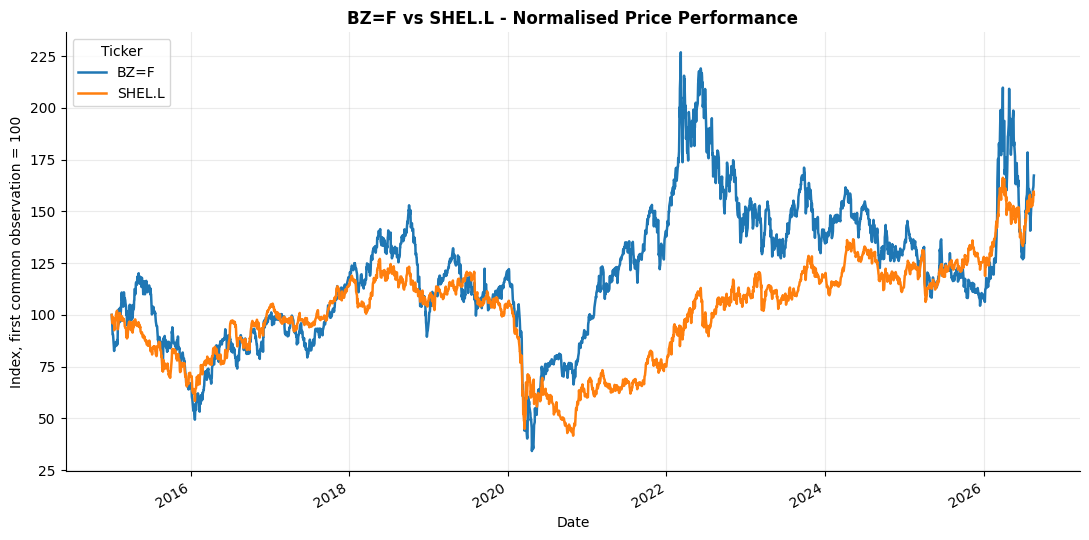

In [16]:
plot_normalised_prices(RESULTS)
plt.show()


## 16. Static dependence

The static correlation table answers the simplest version of the research question: whether the two return series move together on the same aligned observation.

The scatter plot is useful for diagnosing shape. A fitted line can reveal a positive or negative linear tendency, while the cloud of points shows how much variation remains unexplained.


In [17]:
display(RESULTS["static_table"].style.hide(axis="index").format({
    "Correlation": "{:.4f}",
    "P_Value": "{:.3e}"
}))
display(pd.DataFrame([RESULTS["regression"]]).style.hide(axis="index").format("{:.4f}"))


Measure,Correlation,P_Value
Pearson,0.4812,1.800e-166
Spearman,0.4550,7.241e-147


Slope,Intercept,R_Squared,P_Value,Slope_Std_Error
0.3368,0.0001,0.2315,0.0000,0.0115


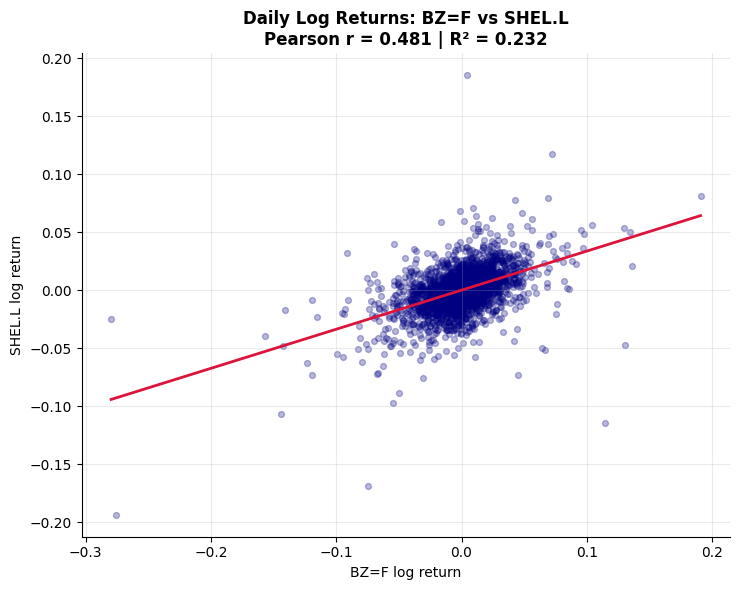

In [18]:
plot_return_scatter(RESULTS)
plt.show()


## 17. Rolling correlation regimes

The rolling table should be read together with the chart. The current correlation tells us the latest state; the historical percentile tells us how unusual that state is relative to prior windows of the same length.

A short-window spike is not equivalent to a durable regime. Agreement across progressively longer windows is more informative than any single short-window observation.


In [19]:
display(RESULTS["rolling_summary"].style.hide(axis="index").format({
    "Current_Correlation": "{:.4f}",
    "Historical_Percentile": "{:.1%}",
    "Mean": "{:.4f}",
    "Std_Dev": "{:.4f}",
    "Minimum": "{:.4f}",
    "Maximum": "{:.4f}"
}))


Window,Current_Correlation,Historical_Percentile,Mean,Std_Dev,Minimum,Maximum
20D,0.5761,67.7%,0.4630,0.2081,-0.3670,0.9543
60D,0.6391,88.9%,0.4688,0.1429,0.0690,0.8921
120D,0.7126,98.8%,0.4761,0.1097,0.1316,0.8253


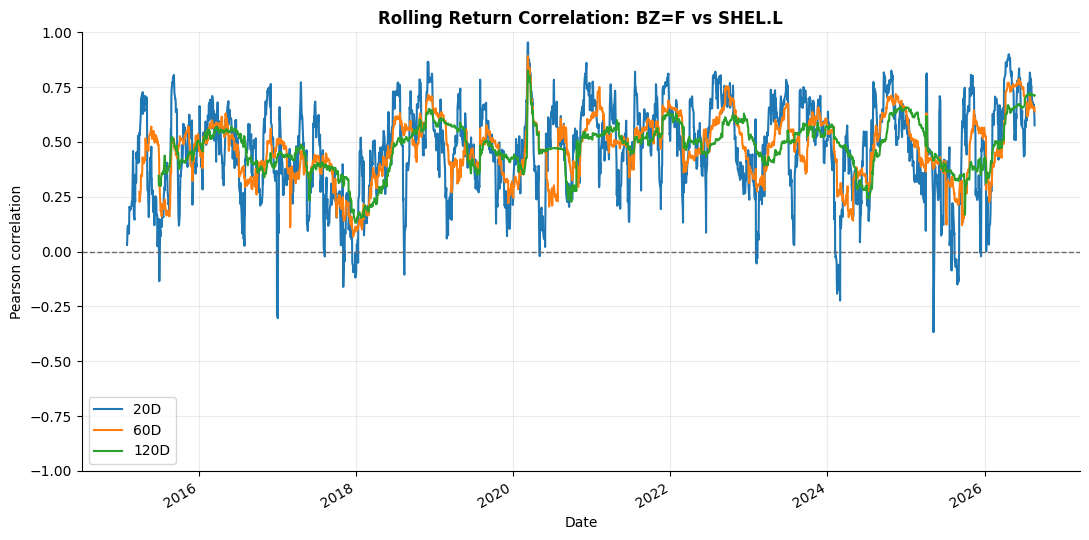

In [20]:
plot_rolling_correlation(RESULTS)
plt.show()


## 18. Equal-sample lead-lag scan and family-wise inference

The zero-lag point is included on the chart as a reference but is excluded from the search for the strongest delayed relationship.

The inference table applies Bonferroni correction to every non-zero candidate lag. A result can therefore be:

- economically small but statistically detectable;
- statistically insignificant despite a visually noticeable sample correlation;
- significant in the full sample but unstable through time.

The selected lag is defined by the largest **absolute** non-zero correlation, so the search is equally willing to find a positive or an inverse delayed relationship.


In [21]:
display(
    RESULTS["lag_tests"]
    .sort_values("Absolute_Correlation", ascending=False)
    .head(10)
    .style
    .hide(axis="index")
    .format({
        "Correlation": "{:.4f}",
        "P_Value": "{:.3e}",
        "Absolute_Correlation": "{:.4f}",
        "P_Value_Adjusted": "{:.3e}"
    })
)


Lag,Correlation,P_Value,Observations,Absolute_Correlation,P_Value_Adjusted,Significant_After_Correction
6,-0.0992,1.205e-07,2834,0.0992,4.819e-06,True
18,-0.0880,2.731e-06,2834,0.0880,1.093e-04,True
-18,-0.0679,2.975e-04,2834,0.0679,1.190e-02,True
-7,0.0645,5.860e-04,2834,0.0645,2.344e-02,True
15,0.0498,7.953e-03,2834,0.0498,3.181e-01,False
-20,0.0488,9.419e-03,2834,0.0488,3.768e-01,False
-17,-0.0447,1.740e-02,2834,0.0447,6.959e-01,False
7,0.0368,5.013e-02,2834,0.0368,1.000e+00,False
-13,-0.0329,8.027e-02,2834,0.0329,1.000e+00,False
-14,-0.0287,1.263e-01,2834,0.0287,1.000e+00,False


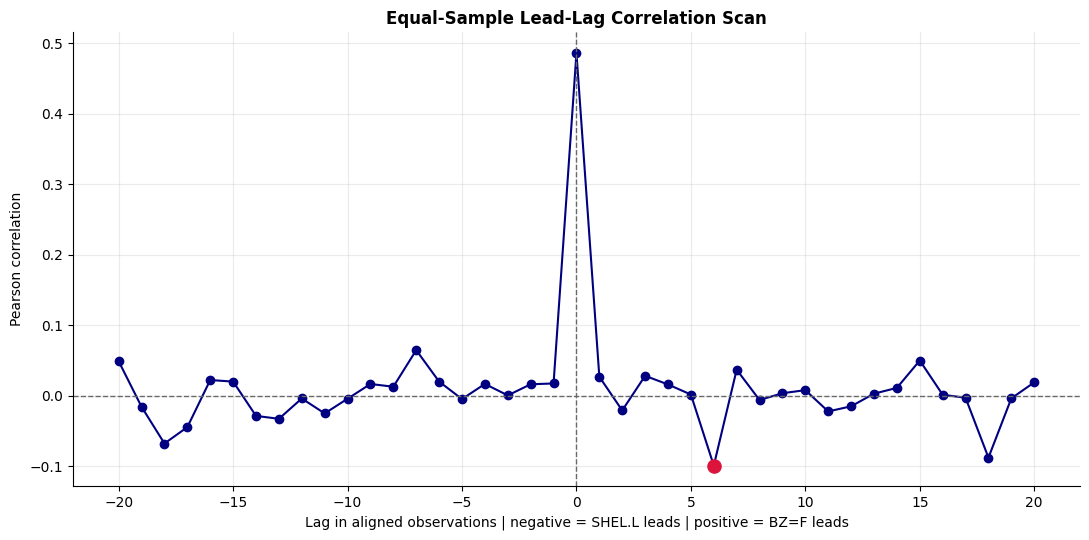

In [22]:
plot_lag_scan(RESULTS)
plt.show()


## 19. Bootstrap uncertainty and block-size sensitivity

The histogram visualises uncertainty around the selected lag conditional on that lag having been chosen. The sensitivity table then changes the block length while keeping the number of bootstrap replications and random seed fixed.

A confidence interval that remains on the same side of zero across several block lengths is stronger evidence than a result that disappears as soon as local dependence is preserved slightly differently.


In [23]:
display(RESULTS["bootstrap_distribution"].describe().to_frame())
print(
    f"Observed selected-lag correlation: {RESULTS['best_corr']:.4f}\n"
    f"95% moving-block bootstrap interval: "
    f"[{RESULTS['bootstrap_lower']:.4f}, {RESULTS['bootstrap_upper']:.4f}]"
)
display(RESULTS["bootstrap_sensitivity"].style.hide(axis="index").format({
    "Bootstrap_Mean": "{:.4f}",
    "Bootstrap_Std": "{:.4f}",
    "Lower_95_CI": "{:.4f}",
    "Upper_95_CI": "{:.4f}"
}))


,Bootstrap_Correlation
count,"1,000.000000"
mean,-0.098766
std,0.040301
min,-0.215875
25%,-0.126911
50%,-0.098798
75%,-0.070785
max,0.039285


Observed selected-lag correlation: -0.0992
95% moving-block bootstrap interval: [-0.1749, -0.0245]


Block_Size,Bootstrap_Mean,Bootstrap_Std,Lower_95_CI,Upper_95_CI,Contains_Zero
10,-0.0992,0.0360,-0.1676,-0.0311,False
20,-0.0988,0.0403,-0.1749,-0.0245,False
40,-0.0964,0.0478,-0.1838,-0.0046,False


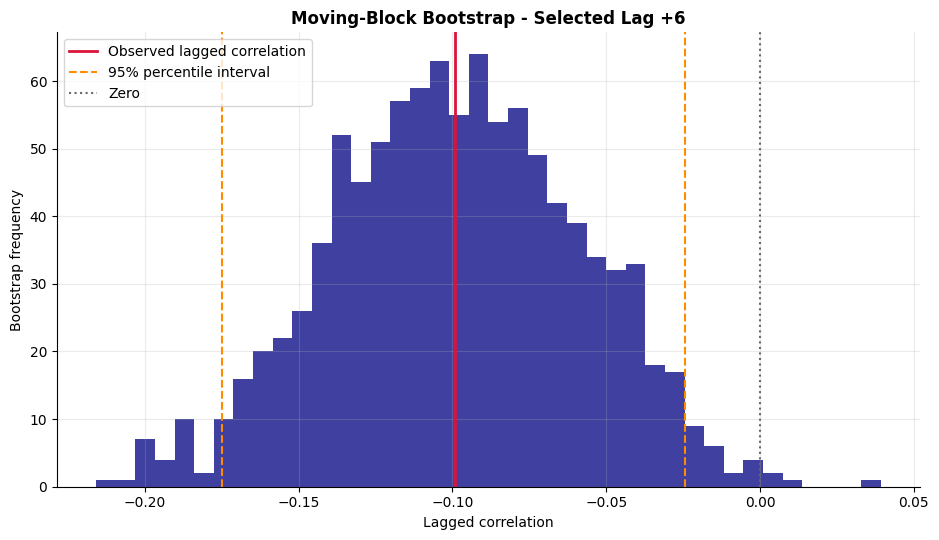

In [24]:
plot_bootstrap(RESULTS)
plt.show()


## 20. Stationarity diagnostic

The ADF test is applied to returns, not prices. Rejecting the unit-root null supports the use of return-based lag models.

The test does not establish that every distributional feature is constant. Financial returns can be stationary in the mean while still exhibiting time-varying volatility.


In [25]:
display(RESULTS["stationarity"].style.hide(axis="index").format({
    "ADF_Statistic": "{:.4f}",
    "P_Value": "{:.3e}"
}))


Asset,ADF_Statistic,P_Value,Used_Lags,Observations,Stationary_5pct
BZ=F,-22.5942,0.000e+00,5,2868,True
SHEL.L,-11.3695,9.055e-21,23,2850,True


## 21. Bidirectional Granger tests

The Granger table is corrected across both directions and all lag depths as one family of tests.

A useful pattern is not merely "some p-value below 0.05". More persuasive evidence would show directional asymmetry, survive correction, and broadly agree with the lead-lag analysis. Even then, the result remains predictive rather than causal.


In [26]:
display(
    RESULTS["granger"]
    .style
    .hide(axis="index")
    .format({
        "F_Statistic": "{:.4f}",
        "P_Value": "{:.3e}",
        "P_Value_Adjusted": "{:.3e}"
    })
)


Lag,F_Statistic,P_Value,Direction,P_Value_Adjusted,Significant_After_Correction
1,0.3516,5.532e-01,BZ=F → SHEL.L,1.000e+00,False
2,0.1787,8.364e-01,BZ=F → SHEL.L,1.000e+00,False
3,1.7305,1.586e-01,BZ=F → SHEL.L,1.000e+00,False
4,1.4197,2.248e-01,BZ=F → SHEL.L,1.000e+00,False
5,1.3811,2.281e-01,BZ=F → SHEL.L,1.000e+00,False
6,6.7042,4.612e-07,BZ=F → SHEL.L,9.225e-06,True
7,6.1738,3.441e-07,BZ=F → SHEL.L,6.881e-06,True
8,5.4007,9.068e-07,BZ=F → SHEL.L,1.814e-05,True
9,4.8381,1.926e-06,BZ=F → SHEL.L,3.852e-05,True
10,4.4490,3.021e-06,BZ=F → SHEL.L,6.042e-05,True


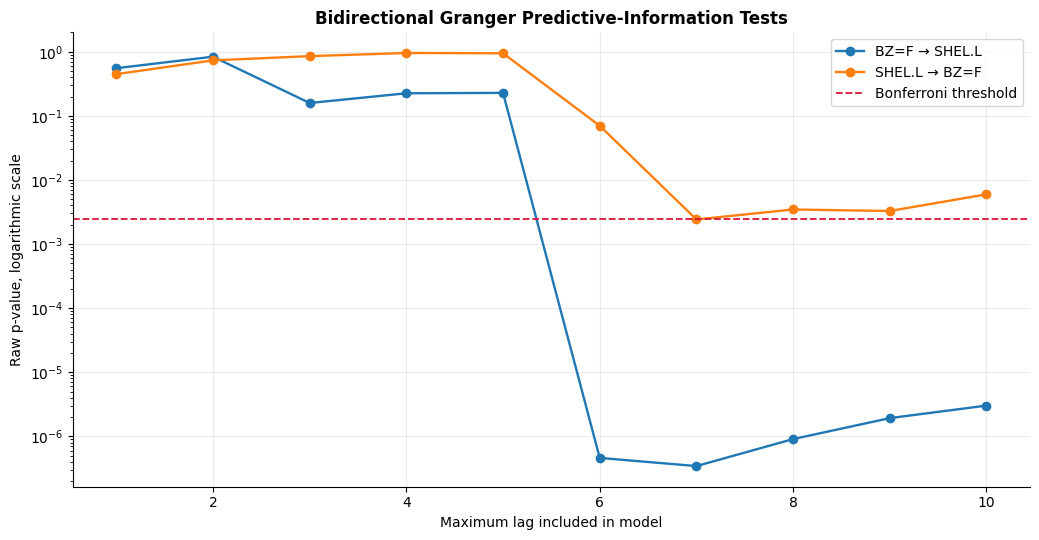

In [27]:
plot_granger(RESULTS)
plt.show()


## 22. Rolling lag stability

This section is the strongest defence against over-interpreting a full-sample optimum.

If the selected lag wins only a small fraction of rolling windows, the full-sample result may be statistically real without representing a fixed market delay. Likewise, if the sign flips frequently, the lag should be described as regime-dependent rather than structural.

The lead-direction shares report how often the strongest rolling lag is positive or negative. They are descriptive frequencies, not probabilities that one asset will lead the other tomorrow.


In [28]:
lag_frequency = (
    RESULTS["rolling_lags"]["Best_Lag"]
    .value_counts()
    .sort_index()
    .rename("Windows")
    .to_frame()
)

display(lag_frequency)
print(f"Selected lag wins: {RESULTS['best_lag_win_share']:.1%}")
print(f"{ASSET_A} leads in strongest-lag windows: {RESULTS['asset_a_leads_share']:.1%}")
print(f"{ASSET_B} leads in strongest-lag windows: {RESULTS['asset_b_leads_share']:.1%}")
print(f"Selected lag keeps its full-sample sign: {RESULTS['selected_sign_share']:.1%}")
print(
    "Selected-lag magnitude exceeds same-day magnitude: "
    f"{RESULTS['lag_beats_same_day_share']:.1%}"
)


,Windows
Best_Lag,
-20,21
-19,1
-18,4
-17,6
-15,2
-14,6
-13,3
-12,1
-11,7


Selected lag wins: 12.8%
BZ=F leads in strongest-lag windows: 42.4%
SHEL.L leads in strongest-lag windows: 57.6%
Selected lag keeps its full-sample sign: 64.8%
Selected-lag magnitude exceeds same-day magnitude: 0.0%


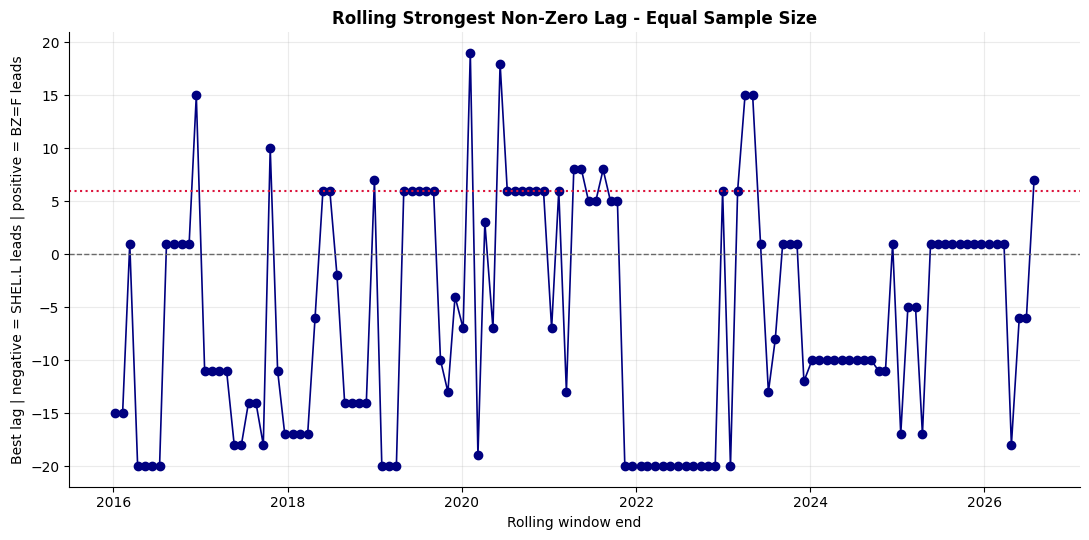

In [29]:
plot_rolling_lag_stability(RESULTS)
plt.show()


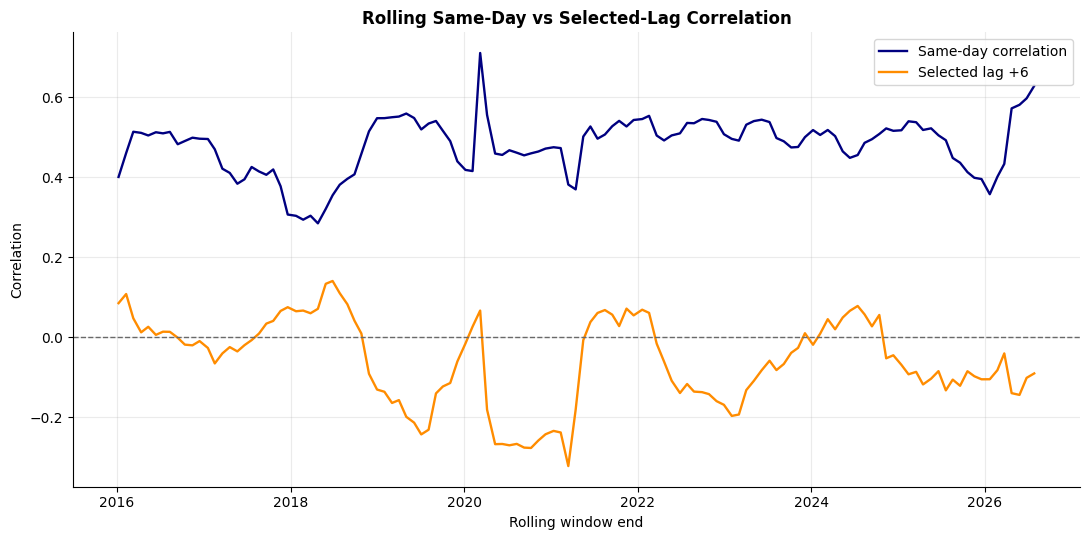

In [30]:
plot_fixed_lag_vs_same_day(RESULTS)
plt.show()


## 23. Headline evidence

The final table compresses the full analysis into the quantities most useful for a reviewer. The detailed sections above remain available for auditability.


In [31]:
display(RESULTS["headline"].style.hide(axis="index"))


Finding,Result
Aligned price observations,"2,875"
Return observations,"2,874"
Full-sample Pearson correlation,0.481
Latest 120D correlation,0.713
Latest 120D historical percentile,98.8%
Strongest non-zero lag,+6 aligned observations
Lagged correlation,-0.099
95% moving-block bootstrap interval,"[-0.175, -0.025]"
Selected lag wins rolling windows,12.8%
Selected lag keeps full-sample sign,64.8%


## 24. Research conclusion

The final conclusion is generated from the selected pair rather than being hard-coded to the default assets.

The interpretation follows an evidence hierarchy. The **same-day correlation** establishes the dominant contemporaneous relationship. The **equal-sample lag scan** identifies the strongest delayed association while holding the observation count constant across candidate lags. The **Bonferroni-adjusted p-value** asks whether that selected lag remains statistically unusual after accounting for the family of searched non-zero lags. The **moving-block bootstrap** estimates uncertainty while preserving local dependence in the selected lagged pair. The **rolling stability diagnostics** then determine whether the lag behaves like persistent structure or a regime-dependent historical pattern.

The sign of the lag and the sign of the correlation answer different questions. Under the notebook convention,

$$ \rho(k)=\operatorname{Corr}\left(r^{A}_{t},\,r^{B}_{t+k}\right) $$

a positive $k$ means Asset A leads Asset B, while a negative $k$ means Asset B leads Asset A. A positive correlation means the paired returns tend to move in the same direction; a negative correlation means they tend to move in opposite directions.

The Granger section is interpreted separately. Rejection of a Granger null means lagged values of one asset add predictive information for the other within the chosen autoregressive specification. It does not identify a structural causal mechanism.

The selected-pair conclusion below is therefore generated directly from the current controls and research outputs. Changing the tickers or date range changes the conclusion automatically.


In [32]:
display(Markdown(build_selected_pair_conclusion(RESULTS)))


### Selected-pair conclusion: BZ=F vs SHEL.L

The full-sample contemporaneous Pearson correlation is **0.481**. The latest **120D** rolling correlation is **0.713**, which sits at the **98.8%** historical percentile of that rolling series.

The strongest equal-sample non-zero relationship occurs at **lag +6**, so **BZ=F leads SHEL.L** under the notebook's lag convention. The lagged correlation is **-0.099**, implying a **inverse** relationship. Its absolute magnitude is **20.6%** of the same-day Pearson correlation.

For inference, the selected lag survives the Bonferroni correction and its moving-block bootstrap interval excludes zero. The selected lag is the strongest non-zero lag in **12.8%** of rolling windows, keeps its full-sample sign in **64.8%**, and exceeds the absolute same-day relationship in **0.0%** of rolling windows. These stability statistics determine whether the lag should be treated as persistent structure or as a weaker, regime-dependent historical pattern.

After Bonferroni correction, Granger evidence is stronger in the **BZ=F → SHEL.L** direction. Granger results are interpreted as incremental predictive information within the specified autoregressions, not as evidence of structural economic causation.

**Overall:** the dominant claim should follow the hierarchy of effect size, corrected significance, bootstrap uncertainty and rolling stability. A statistically detectable lag should not be described as a fixed market lead unless it is also economically material and stable through time.

## 25. From statistical lag to a trading hypothesis

The research engine identifies delayed association. A trading rule needs a different target: **future follower return after the leader signal becomes observable**.

If $L$ denotes the asset identified as the leader in a formation window and $F$ denotes the follower, define the follower's cumulative forward log return over a holding horizon $h$ as:

$$ R^{F,(h)}_{t+1:t+h}=\sum_{j=1}^{h}r^{F}_{t+j} $$

The formation-window response model is:

$$ R^{F,(h)}_{t+1:t+h}=\alpha+\beta r^{L}_{t}+\varepsilon_t $$

The cross-correlation scan determines which asset is treated as leader and sets an economically interpretable candidate horizon:

$$ h=\min\left(|k^{*}|,\,h_{\max}\right) $$

where $k^{*}$ is the strongest non-zero equal-sample lag estimated **inside the formation window** and $h_{\max}$ is the configured maximum holding period.

This distinction is important. The research statistic

$$ \rho(k)=\operatorname{Corr}\left(r^{A}_{t},\,r^{B}_{t+k}\right) $$

compares one return with another return at a specific displacement. The trading regression instead asks whether the leader's observed return contains information about the follower's **cumulative future response** over the next $h$ observations.

The sign of $\beta$ determines the forecast direction. If $\beta>0$, positive leader shocks imply a positive expected follower response. If $\beta<0$, the expected response is inverse.


In [33]:
def download_pair_ohlc(
    asset_a,
    asset_b,
    start_date,
    end_date
):
    raw = yf.download(
        [asset_a, asset_b],
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )

    if raw.empty:
        raise ValueError("Yahoo Finance returned no observations for the selected backtest controls.")

    if isinstance(raw.columns, pd.MultiIndex):
        open_prices = raw["Open"].copy()
        close_prices = raw["Close"].copy()
    else:
        open_prices = raw[["Open"]].copy()
        close_prices = raw[["Close"]].copy()
        open_prices.columns = [asset_a]
        close_prices.columns = [asset_a]

    open_prices = open_prices.reindex(columns=[asset_a, asset_b])
    close_prices = close_prices.reindex(columns=[asset_a, asset_b])

    common = close_prices.dropna().index
    open_prices = open_prices.reindex(common)
    close_prices = close_prices.reindex(common)

    if len(close_prices) < 100:
        raise ValueError("Fewer than 100 aligned observations remain for the pair backtest.")

    return open_prices, close_prices


def forward_response_regression(train_returns, leader, follower, horizon):
    forward = pd.concat(
        [train_returns[follower].shift(-step) for step in range(1, horizon + 1)],
        axis=1
    ).sum(axis=1, min_count=horizon)

    frame = pd.concat(
        [
            train_returns[leader].rename("Leader_Return"),
            forward.rename("Follower_Forward_Log_Return")
        ],
        axis=1
    ).dropna()

    if len(frame) < 60:
        raise ValueError("Too few observations remain for the forward-response regression.")

    regression = stats.linregress(
        frame["Leader_Return"],
        frame["Follower_Forward_Log_Return"]
    )

    return {
        "Intercept": regression.intercept,
        "Beta": regression.slope,
        "R_Squared": regression.rvalue ** 2,
        "P_Value": regression.pvalue,
        "Std_Error": regression.stderr,
        "Observations": len(frame)
    }


def estimate_walk_forward_model(
    train_returns,
    asset_a,
    asset_b,
    max_lag,
    max_holding_period,
    min_same_day_correlation,
    min_lag_correlation,
    require_lag_significance
):
    lag_table, lag_tests, best_row = equal_sample_lag_scan(
        train_returns,
        asset_a,
        asset_b,
        max_lag
    )

    best_lag = int(best_row["Lag"])
    lag_corr = float(best_row["Correlation"])
    same_day_corr = float(train_returns[asset_a].corr(train_returns[asset_b]))

    if best_lag > 0:
        leader = asset_a
        follower = asset_b
    else:
        leader = asset_b
        follower = asset_a

    horizon = int(min(max(abs(best_lag), 1), max_holding_period))

    regression = forward_response_regression(
        train_returns,
        leader,
        follower,
        horizon
    )

    leader_mean = float(train_returns[leader].mean())
    leader_std = float(train_returns[leader].std(ddof=1))

    if leader_std == 0 or np.isnan(leader_std):
        raise ValueError("The leader return series has zero or undefined training volatility.")

    eligible = (
        abs(same_day_corr) >= min_same_day_correlation
        and abs(lag_corr) >= min_lag_correlation
    )

    if require_lag_significance:
        eligible = eligible and bool(best_row["Significant_After_Correction"])

    beta = float(regression["Beta"])
    relation = "Same-direction" if lag_corr > 0 else "Inverse"
    beta_relation = "Same-direction" if beta > 0 else "Inverse"
    signal_alignment = bool(np.sign(beta) == np.sign(lag_corr))

    return {
        "Leader": leader,
        "Follower": follower,
        "Best_Lag": best_lag,
        "Lead_Horizon": horizon,
        "Lag_Correlation": lag_corr,
        "Relation": relation,
        "Lag_P_Value_Adjusted": float(best_row["P_Value_Adjusted"]),
        "Lag_Significant": bool(best_row["Significant_After_Correction"]),
        "Same_Day_Correlation": same_day_corr,
        "Horizon": horizon,
        "Beta": beta,
        "Beta_Relation": beta_relation,
        "Signal_Alignment": signal_alignment,
        "Beta_P_Value": float(regression["P_Value"]),
        "Forward_R_Squared": float(regression["R_Squared"]),
        "Leader_Mean": leader_mean,
        "Leader_Std": leader_std,
        "Eligible": bool(eligible)
    }


def build_walk_forward_positions(
    log_returns,
    asset_a,
    asset_b,
    formation_window,
    rebalance_step,
    max_lag,
    max_holding_period,
    signal_z_threshold,
    min_same_day_correlation,
    min_lag_correlation,
    require_lag_significance,
    allow_short
):
    if formation_window <= 2 * max_lag + 60:
        raise ValueError("BACKTEST_FORMATION_WINDOW must be substantially larger than twice BACKTEST_MAX_LAG.")

    if len(log_returns) <= formation_window + rebalance_step:
        raise ValueError("The sample is too short for the requested walk-forward formation window.")

    positions = pd.DataFrame(
        0.0,
        index=log_returns.index,
        columns=[asset_a, asset_b]
    )

    model_rows = []
    trade_rows = []
    occupied_until = formation_window - 1

    for block_start in range(
        formation_window,
        len(log_returns),
        rebalance_step
    ):
        block_end = min(
            block_start + rebalance_step,
            len(log_returns)
        )

        train = log_returns.iloc[
            block_start - formation_window:block_start
        ]

        model = estimate_walk_forward_model(
            train,
            asset_a,
            asset_b,
            max_lag,
            max_holding_period,
            min_same_day_correlation,
            min_lag_correlation,
            require_lag_significance
        )

        model_rows.append({
            "Rebalance_Date": log_returns.index[block_start],
            **model
        })

        if not model["Eligible"] or model["Beta"] == 0:
            continue

        for signal_position in range(block_start, block_end):
            if signal_position <= occupied_until:
                continue

            entry_position = signal_position + 1

            if entry_position >= len(log_returns):
                break

            leader_return = float(
                log_returns.iloc[signal_position][model["Leader"]]
            )

            z_score = (
                leader_return - model["Leader_Mean"]
            ) / model["Leader_Std"]

            if abs(z_score) < signal_z_threshold:
                continue

            direction = float(
                np.sign(model["Beta"] * z_score)
            )

            if direction < 0 and not allow_short:
                continue

            exit_position = min(
                entry_position + model["Horizon"] - 1,
                len(log_returns) - 1
            )

            follower = model["Follower"]

            positions.loc[
                log_returns.index[entry_position:exit_position + 1],
                follower
            ] = direction

            trade_rows.append({
                "Signal_Date": log_returns.index[signal_position],
                "Entry_Date": log_returns.index[entry_position],
                "Exit_Date": log_returns.index[exit_position],
                "Leader": model["Leader"],
                "Follower": follower,
                "Direction": direction,
                "Leader_Z": z_score,
                "Holding_Observations": exit_position - entry_position + 1,
                "Best_Lag": model["Best_Lag"],
                "Lead_Horizon": model["Lead_Horizon"],
                "Lag_Correlation": model["Lag_Correlation"],
                "Relation": model["Relation"],
                "Lag_P_Value_Adjusted": model["Lag_P_Value_Adjusted"],
                "Same_Day_Correlation": model["Same_Day_Correlation"],
                "Forward_Beta": model["Beta"],
                "Beta_Relation": model["Beta_Relation"],
                "Signal_Alignment": model["Signal_Alignment"],
                "Forward_Beta_P_Value": model["Beta_P_Value"]
            })

            occupied_until = exit_position

    return positions, pd.DataFrame(model_rows), pd.DataFrame(trade_rows)


def calculate_backtest_performance(
    log_returns,
    positions,
    trades,
    transaction_cost_bps,
    evaluation_start,
    open_prices=None,
    close_prices=None
):
    evaluation_index = log_returns.index[evaluation_start:]
    gross_returns = pd.Series(0.0, index=evaluation_index, dtype=float)
    turnover = pd.Series(0.0, index=evaluation_index, dtype=float)
    exposure = pd.Series(0.0, index=evaluation_index, dtype=float)
    cost_rate = transaction_cost_bps / 10_000
    trade_frame = trades.copy()

    if open_prices is None or close_prices is None:
        simple_returns = np.exp(log_returns) - 1
        gross_returns = (
            positions.fillna(0)
            * simple_returns.reindex(positions.index).fillna(0)
        ).sum(axis=1).loc[evaluation_index]
        turnover = positions.diff().abs().sum(axis=1)
        turnover.iloc[0] = positions.iloc[0].abs().sum()
        turnover = turnover.loc[evaluation_index]
        exposure = (
            positions.loc[evaluation_index]
            .abs()
            .sum(axis=1)
        )

        if positions.iloc[-1].abs().sum() > 0:
            turnover.iloc[-1] += positions.iloc[-1].abs().sum()

        if not trade_frame.empty:
            trade_gross = []
            trade_net = []

            for _, row in trade_frame.iterrows():
                follower_returns = simple_returns.loc[
                    row["Entry_Date"]:row["Exit_Date"],
                    row["Follower"]
                ]
                path = 1 + row["Direction"] * follower_returns
                gross = float(path.prod() - 1)
                net = gross - 2 * cost_rate
                trade_gross.append(gross)
                trade_net.append(net)

            trade_frame["Gross_Return"] = trade_gross
            trade_frame["Net_Return"] = trade_net
            trade_frame["Execution"] = "Aligned close-to-close approximation"
    else:
        open_prices = open_prices.reindex(log_returns.index)
        close_prices = close_prices.reindex(log_returns.index)

        trade_gross = []
        trade_net = []

        for _, row in trade_frame.iterrows():
            entry_date = row["Entry_Date"]
            exit_date = row["Exit_Date"]
            follower = row["Follower"]
            direction = row["Direction"]

            path_index = log_returns.loc[
                entry_date:exit_date
            ].index

            if len(path_index) == 0:
                trade_gross.append(np.nan)
                trade_net.append(np.nan)
                continue

            entry_open = open_prices.loc[path_index[0], follower]
            entry_close = close_prices.loc[path_index[0], follower]

            if pd.isna(entry_open) or pd.isna(entry_close) or entry_open <= 0:
                trade_gross.append(np.nan)
                trade_net.append(np.nan)
                continue

            raw_path = pd.Series(0.0, index=path_index, dtype=float)
            raw_path.iloc[0] = float(entry_close / entry_open - 1)
            valid_path = True

            for step in range(1, len(path_index)):
                previous_close = close_prices.loc[path_index[step - 1], follower]
                current_close = close_prices.loc[path_index[step], follower]

                if (
                    pd.isna(previous_close)
                    or pd.isna(current_close)
                    or previous_close <= 0
                ):
                    valid_path = False
                    break

                raw_path.iloc[step] = float(
                    current_close / previous_close - 1
                )

            if not valid_path:
                trade_gross.append(np.nan)
                trade_net.append(np.nan)
                continue

            directional_path = direction * raw_path
            common = gross_returns.index.intersection(path_index)

            gross_returns.loc[common] = (
                gross_returns.loc[common]
                + directional_path.loc[common]
            )

            exposure.loc[common] = 1.0

            if path_index[0] in turnover.index:
                turnover.loc[path_index[0]] += 1.0

            if path_index[-1] in turnover.index:
                turnover.loc[path_index[-1]] += 1.0

            gross = float(
                (1 + directional_path).prod() - 1
            )
            net = gross - 2 * cost_rate
            trade_gross.append(gross)
            trade_net.append(net)

        if not trade_frame.empty:
            trade_frame["Gross_Return"] = trade_gross
            trade_frame["Net_Return"] = trade_net
            trade_frame["Execution"] = "Next adjusted open to adjusted close"

    costs = turnover * cost_rate
    net_returns = gross_returns - costs

    gross_equity = (1 + gross_returns).cumprod()
    net_equity = (1 + net_returns).cumprod()

    running_peak = net_equity.cummax()
    drawdown = net_equity / running_peak - 1

    annualised_volatility = float(net_returns.std(ddof=1) * np.sqrt(252))
    annualised_return = float(net_returns.mean() * 252)
    sharpe = (
        annualised_return / annualised_volatility
        if annualised_volatility > 0
        else np.nan
    )

    years = len(net_returns) / 252
    final_equity = float(net_equity.iloc[-1])
    cagr = (
        final_equity ** (1 / years) - 1
        if years > 0 and final_equity > 0
        else np.nan
    )

    clean_trade_frame = trade_frame.dropna(
        subset=["Net_Return"]
    ).copy() if not trade_frame.empty else trade_frame

    winning_returns = (
        clean_trade_frame.loc[
            clean_trade_frame["Net_Return"] > 0,
            "Net_Return"
        ]
        if not clean_trade_frame.empty
        else pd.Series(dtype=float)
    )

    losing_returns = (
        clean_trade_frame.loc[
            clean_trade_frame["Net_Return"] < 0,
            "Net_Return"
        ]
        if not clean_trade_frame.empty
        else pd.Series(dtype=float)
    )

    profit_factor = (
        winning_returns.sum() / abs(losing_returns.sum())
        if len(losing_returns) > 0 and losing_returns.sum() != 0
        else np.nan
    )

    metrics = pd.DataFrame({
        "Metric": [
            "Net total return",
            "Gross total return",
            "CAGR",
            "Annualised volatility",
            "Sharpe ratio, zero risk-free rate",
            "Maximum drawdown",
            "Number of trades",
            "Win rate",
            "Average net trade return",
            "Profit factor",
            "Average holding observations",
            "Time in market",
            "Total one-way turnover",
            "Transaction cost assumption"
        ],
        "Value": [
            float(net_equity.iloc[-1] - 1),
            float(gross_equity.iloc[-1] - 1),
            cagr,
            annualised_volatility,
            sharpe,
            float(drawdown.min()),
            int(len(clean_trade_frame)),
            float((clean_trade_frame["Net_Return"] > 0).mean()) if not clean_trade_frame.empty else np.nan,
            float(clean_trade_frame["Net_Return"].mean()) if not clean_trade_frame.empty else np.nan,
            float(profit_factor) if not np.isnan(profit_factor) else np.nan,
            float(clean_trade_frame["Holding_Observations"].mean()) if not clean_trade_frame.empty else np.nan,
            float((exposure > 0).mean()),
            float(turnover.sum()),
            float(transaction_cost_bps)
        ]
    })

    evaluated_positions = positions.loc[evaluation_index]

    performance = pd.DataFrame({
        "Gross_Return": gross_returns,
        "Net_Return": net_returns,
        "Gross_Equity": gross_equity,
        "Net_Equity": net_equity,
        "Drawdown": drawdown,
        "Turnover": turnover,
        "Cost": costs,
        "Position_A": evaluated_positions.iloc[:, 0],
        "Position_B": evaluated_positions.iloc[:, 1]
    })

    return performance, clean_trade_frame, metrics



def run_walk_forward_backtest(
    asset_a,
    asset_b,
    start_date,
    end_date,
    formation_window,
    rebalance_step,
    max_lag,
    max_holding_period,
    signal_z_threshold,
    min_same_day_correlation,
    min_lag_correlation,
    require_lag_significance,
    allow_short,
    transaction_cost_bps,
    aligned_prices=None
):
    if formation_window < 100:
        raise ValueError("BACKTEST_FORMATION_WINDOW must be at least 100 observations.")

    if rebalance_step < 1 or max_lag < 1 or max_holding_period < 1:
        raise ValueError("Backtest step, lag and holding controls must be positive integers.")

    if signal_z_threshold <= 0:
        raise ValueError("BACKTEST_SIGNAL_Z must be positive.")

    if transaction_cost_bps < 0:
        raise ValueError("Transaction costs cannot be negative.")

    if aligned_prices is None:
        open_prices, close_prices = download_pair_ohlc(
            asset_a,
            asset_b,
            start_date,
            end_date
        )
        aligned_prices = close_prices.copy()
    else:
        aligned_prices = aligned_prices[[asset_a, asset_b]].dropna().copy()
        open_prices, close_prices = download_pair_ohlc(
            asset_a,
            asset_b,
            start_date,
            end_date
        )
        common = aligned_prices.index.intersection(close_prices.index)
        aligned_prices = aligned_prices.loc[common]
        open_prices = open_prices.reindex(common)
        close_prices = close_prices.reindex(common)

    log_returns = calculate_log_returns(aligned_prices)

    open_prices = open_prices.reindex(log_returns.index)
    close_prices = close_prices.reindex(log_returns.index)

    positions, models, trades = build_walk_forward_positions(
        log_returns,
        asset_a,
        asset_b,
        formation_window,
        rebalance_step,
        max_lag,
        max_holding_period,
        signal_z_threshold,
        min_same_day_correlation,
        min_lag_correlation,
        require_lag_significance,
        allow_short
    )

    performance, trades, metrics = calculate_backtest_performance(
        log_returns,
        positions,
        trades,
        transaction_cost_bps,
        formation_window,
        open_prices,
        close_prices
    )

    return {
        "asset_a": asset_a,
        "asset_b": asset_b,
        "aligned_prices": aligned_prices,
        "open_prices": open_prices,
        "close_prices": close_prices,
        "log_returns": log_returns,
        "positions": positions,
        "models": models,
        "trades": trades,
        "performance": performance,
        "metrics": metrics,
        "transaction_cost_bps": transaction_cost_bps,
        "signal_z_threshold": signal_z_threshold,
        "formation_window": formation_window,
        "rebalance_step": rebalance_step,
        "execution_mode": "next_open"
    }



## 26. Walk-forward design and look-ahead control

A full-sample lag cannot be discovered using future data and then treated as though it were known historically. The strategy therefore uses a rolling formation-and-test design.

At re-estimation date $T_m$, the parameter set is estimated only from the preceding formation window:

$$ \mathcal{F}_m=\{T_m-W,\ldots,T_m-1\} $$

where $W$ is `BACKTEST_FORMATION_WINDOW`.

The resulting model is held fixed through the next test block:

$$ \mathcal{T}_m=\{T_m,\ldots,T_m+H-1\} $$

where $H$ is `BACKTEST_REBALANCE_STEP`.

Inside each formation window the engine:

1. measures same-day correlation;
2. performs the equal-sample lag scan;
3. selects the leader, follower and strongest non-zero lag;
4. estimates the forward-response coefficient $\beta$;
5. records the training mean and volatility of leader returns;
6. decides whether the pair satisfies the configured minimum relationship thresholds.

Nothing from $\mathcal{T}_m$ is used to estimate the model applied to $\mathcal{T}_m$.

This is a **walk-forward backtest**, not a conventional random train/test split. That choice respects the time ordering of market information.


Eligibility requires the configured minimum same-day and lag-correlation magnitudes. `BACKTEST_REQUIRE_LAG_SIGNIFICANCE` can additionally force the selected lag to survive the within-window Bonferroni correction. It is `False` by default so the backtest can test whether effect-size thresholds alone have out-of-sample value rather than silently filtering history with an especially strict significance rule.


## 27. Signal construction, execution and transaction costs

The leader shock is standardised using statistics estimated from the formation window:

$$ z_t=\frac{r^{L}_{t}-\hat{\mu}_{L}}{\hat{\sigma}_{L}} $$

A trade is considered only when the completed leader return is unusually large:

$$ |z_t|\ge z^{*} $$

where $z^{*}$ is `BACKTEST_SIGNAL_Z`.

The directional signal is:

$$ s_t=\operatorname{sign}\left(\hat{\beta}z_t\right) $$

with $s_t=+1$ for long follower exposure and $s_t=-1$ for short follower exposure. If shorting is disabled, negative signals are ignored.

The signal at time $t$ is calculated from a return that has already completed. The strategy therefore begins earning follower returns from the **next aligned return interval**, not from the same interval that generated the signal. This prevents a common close-to-close look-ahead error.

For follower simple return $R^{F}_{t}$ and position $w_t$, gross strategy return is:

$$ R^{\text{gross}}_{t}=w_tR^{F}_{t} $$

Transaction costs are charged whenever exposure changes:

$$ R^{\text{net}}_{t}=R^{\text{gross}}_{t}-\frac{c}{10^{4}}\left|\Delta w_t\right| $$

where $c$ is the configured one-way cost in basis points. Entering from zero to one unit costs one transaction; closing the position costs another. The notebook also charges terminal liquidation if the final observation still carries exposure.

The execution model uses adjusted daily Yahoo Finance data and should therefore be interpreted as a **daily close-to-close research approximation**, not a broker-level fill simulation.


## 28. Backtest evaluation

A strategy is evaluated on both return and risk. The notebook reports gross and net performance so that turnover drag is visible rather than hidden.

The annualised zero-risk-free-rate Sharpe ratio is:

$$ \operatorname{Sharpe}=\frac{252\,\bar{R}}{\sqrt{252}\,s_R} $$

where $\bar{R}$ and $s_R$ are the mean and standard deviation of daily net strategy returns.

For equity curve $V_t$, drawdown is:

$$ D_t=\frac{V_t}{\max_{u\le t}V_u}-1 $$

and maximum drawdown is:

$$ \operatorname{MDD}=\min_t D_t $$

The compound annual growth rate over $Y$ years is:

$$ \operatorname{CAGR}=V_T^{1/Y}-1 $$

The trade table also reports win rate, average net trade return, holding period and profit factor. These metrics should be read together. A high total return with extreme drawdown, very low trade count or excessive transaction-cost sensitivity is not strong evidence of a robust strategy.

The `Lead_Horizon` shown by the discovery scanner is a full-sample research result. The pair backtest does not freeze that value through history. At each rebalance date it re-estimates the leader, follower and lag from the trailing formation window, so the realised `Average holding observations` can differ from the horizon shown by a current discovery scan. This is required to avoid using future full-sample information inside earlier trades.

The model-history diagnostics report the direction, horizon, lag correlation, forward-response beta, regression fit and eligibility decision at every re-estimation. They are part of the audit trail for understanding why the trading rule changes through time.


In [34]:

def backtest_metric(backtest, metric):
    row = backtest["metrics"].loc[
        backtest["metrics"]["Metric"] == metric,
        "Value"
    ]

    if row.empty:
        return np.nan

    return row.iloc[0]


def format_backtest_summary(backtest):
    metrics = backtest["metrics"].copy()

    percent_metrics = {
        "Net total return",
        "Gross total return",
        "CAGR",
        "Annualised volatility",
        "Maximum drawdown",
        "Win rate",
        "Average net trade return",
        "Time in market"
    }

    ratio_metrics = {
        "Sharpe ratio, zero risk-free rate",
        "Profit factor",
        "Average holding observations",
        "Total one-way turnover"
    }

    rows = []

    for _, row in metrics.iterrows():
        metric = row["Metric"]
        value = row["Value"]

        if pd.isna(value):
            formatted = "n/a"
        elif metric in percent_metrics:
            formatted = f"{value:.2%}"
        elif metric == "Number of trades":
            formatted = f"{int(value):,}"
        elif metric == "Transaction cost assumption":
            formatted = f"{value:.1f} bps one way"
        elif metric in ratio_metrics:
            formatted = f"{value:.3f}"
        else:
            formatted = f"{value:.4f}"

        rows.append({
            "Metric": metric,
            "Result": formatted
        })

    return pd.DataFrame(rows)


def backtest_display_label(backtest):
    return backtest.get(
        "display_label",
        f"{backtest['asset_a']} / {backtest['asset_b']}"
    )


def plot_backtest_equity(backtest):
    frame = backtest["performance"]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(
        frame.index,
        frame["Gross_Equity"],
        label="Gross strategy",
        linewidth=1.5,
        color=SECONDARY
    )
    ax.plot(
        frame.index,
        frame["Net_Equity"],
        label="Net strategy",
        linewidth=1.8,
        color=PRIMARY
    )
    ax.axhline(1, linewidth=1, linestyle="--", color=MUTED)
    ax.set_title(
        f"Walk-Forward Lead-Lag Strategy: {backtest_display_label(backtest)}"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Growth of 1 unit of capital")
    ax.legend()
    fig.tight_layout()
    return fig


def plot_backtest_drawdown(backtest):
    frame = backtest["performance"]

    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.fill_between(
        frame.index,
        frame["Drawdown"],
        0,
        alpha=0.35,
        color=ACCENT
    )
    ax.set_title("Net Strategy Drawdown")
    ax.set_xlabel("Date")
    ax.set_ylabel("Drawdown")
    fig.tight_layout()
    return fig


def plot_backtest_model_history(backtest):
    models = backtest["models"].copy()

    fig, ax = plt.subplots(figsize=(11, 5.2))
    ax.plot(
        models["Rebalance_Date"],
        models["Lead_Horizon"],
        marker="o",
        linewidth=1.2,
        color=PRIMARY
    )
    ax.set_title(
        f"Walk-Forward Lead Horizon: {backtest_display_label(backtest)}"
    )
    ax.set_xlabel("Rebalance date")
    ax.set_ylabel("Lead horizon in observations")
    fig.tight_layout()
    return fig


def plot_backtest_beta_history(backtest):
    models = backtest["models"].copy()

    fig, ax = plt.subplots(figsize=(11, 5.2))
    ax.plot(
        models["Rebalance_Date"],
        models["Beta"],
        marker="o",
        linewidth=1.2,
        color=SECONDARY
    )
    ax.axhline(0, linestyle="--", linewidth=1, color=MUTED)
    ax.set_title(
        f"Walk-Forward Forward-Response Beta: {backtest_display_label(backtest)}"
    )
    ax.set_xlabel("Rebalance date")
    ax.set_ylabel("Estimated forward-response beta")
    fig.tight_layout()
    return fig


def format_backtest_model_history(backtest, tail=30):
    models = backtest["models"].copy()

    columns = [
        "Rebalance_Date",
        "Leader",
        "Follower",
        "Lead_Horizon",
        "Same_Day_Correlation",
        "Lag_Correlation",
        "Relation",
        "Beta",
        "Beta_Relation",
        "Forward_R_Squared",
        "Beta_P_Value",
        "Signal_Alignment",
        "Lag_P_Value_Adjusted",
        "Lag_Significant",
        "Eligible"
    ]

    return models[columns].tail(tail).copy()


def build_backtest_conclusion(backtest):
    net_total = backtest_metric(backtest, "Net total return")
    gross_total = backtest_metric(backtest, "Gross total return")
    cagr = backtest_metric(backtest, "CAGR")
    sharpe = backtest_metric(backtest, "Sharpe ratio, zero risk-free rate")
    drawdown = backtest_metric(backtest, "Maximum drawdown")
    trades = backtest_metric(backtest, "Number of trades")
    win_rate = backtest_metric(backtest, "Win rate")
    exposure = backtest_metric(backtest, "Time in market")
    cost_drag = gross_total - net_total
    models = backtest["models"].copy()

    if models.empty:
        diagnostics = "No formation-window models were estimated."
    else:
        eligible_share = float(models["Eligible"].mean())
        alignment_share = float(models["Signal_Alignment"].mean())
        median_horizon = float(models["Lead_Horizon"].median())
        common_direction = (
            models.assign(
                Pair=models["Leader"] + " → " + models["Follower"]
            )["Pair"]
            .value_counts()
            .index[0]
        )
        diagnostics = (
            f"Across formation windows, **{eligible_share:.1%}** of models passed the configured relationship "
            f"filters. The most common estimated direction was **{common_direction}**, the median lead horizon was "
            f"**{median_horizon:.1f} observations**, and the forward-response beta agreed in sign with the selected "
            f"lag correlation in **{alignment_share:.1%}** of re-estimations."
        )

    if trades == 0:
        return (
            f"### Walk-forward backtest conclusion: {backtest_display_label(backtest)}\n\n"
            f"The configured walk-forward rules generated **no executable trades** after the formation period. "
            f"This is a valid research outcome: the pair did not simultaneously satisfy the model, relationship "
            f"and signal requirements often enough to create an entry. {diagnostics}\n\n"
            f"The correct response is to inspect the formation-window diagnostics or revise pre-specified controls "
            f"before a new run, not to weaken thresholds after seeing the desired answer."
        )

    if pd.isna(sharpe):
        quality = "cannot be judged from Sharpe because realised volatility is zero or undefined"
    elif sharpe >= 1:
        quality = "shows strong risk-adjusted performance in this historical walk-forward run"
    elif sharpe > 0:
        quality = "shows positive but limited risk-adjusted performance in this historical walk-forward run"
    else:
        quality = "does not show positive risk-adjusted performance in this historical walk-forward run"

    return (
        f"### Walk-forward backtest conclusion: {backtest_display_label(backtest)}\n\n"
        f"After the formation period, the net strategy return is **{net_total:.2%}** versus "
        f"**{gross_total:.2%}** before transaction costs. The estimated cost drag is therefore "
        f"**{cost_drag:.2%}** of starting capital under the configured turnover assumption.\n\n"
        f"The strategy CAGR is **{cagr:.2%}**, the zero-risk-free-rate Sharpe ratio is "
        f"**{sharpe:.3f}** when defined, and maximum drawdown is **{drawdown:.2%}**. "
        f"The engine generated **{int(trades)} trades**, with a win rate of **{win_rate:.1%}** "
        f"and market exposure of **{exposure:.1%}**.\n\n"
        f"{diagnostics}\n\n"
        f"On these metrics the strategy {quality}. This is an out-of-sample walk-forward test of the "
        f"pair-specific signal construction, but it is not a proof of deployable alpha. The selected pair, "
        f"parameter grid and current Yahoo Finance data source are themselves research choices, and the daily "
        f"next-open execution from daily adjusted OHLC data remains an approximation of real fills, spreads and intraday slippage."
    )


def plot_discovery_opportunities(discovery, top_n=15):
    frame = discovery["opportunities"].head(top_n).copy()
    frame["Pair"] = frame["Leader"] + " → " + frame["Follower"]

    fig, ax = plt.subplots(figsize=(10.5, 6))
    ax.barh(
        frame["Pair"][::-1],
        frame["Opportunity_Score"][::-1],
        color=PRIMARY
    )
    ax.set_title("Top Lead-Lag Discovery Scores")
    ax.set_xlabel("Opportunity score")
    ax.set_ylabel("Leader → follower")
    fig.tight_layout()
    return fig


def discovery_display_table(discovery, top_n=20):
    columns = [
        "Leader",
        "Follower",
        "Lead_Horizon",
        "Same_Day_Correlation",
        "Lag_Correlation",
        "Relation",
        "Trading_Implication",
        "Sign_Stability",
        "Lag_Win_Share",
        "Lag_P_Value_Adjusted",
        "Scanner_FDR_Adjusted",
        "Validation_Status",
        "Statistical_Evidence_Rank",
        "Opportunity_Score",
        "Leader_Listing_Context",
        "Follower_Listing_Context"
    ]

    available = [
        column
        for column in columns
        if column in discovery["opportunities"].columns
    ]

    return discovery["opportunities"][available].head(top_n).copy()



def build_discovery_conclusion(discovery):
    top_score = discovery["opportunities"].iloc[0]
    best_evidence = (
        discovery["opportunities"]
        .sort_values(
            ["Scanner_FDR_Adjusted", "Lag_P_Value_Adjusted"],
            ascending=True
        )
        .iloc[0]
    )

    screened = len(discovery["universe"])
    retained = discovery["returns"].shape[1]
    candidates = len(discovery["initial_candidates"])
    opportunities = len(discovery["opportunities"])

    validated_count = int(
        (discovery["opportunities"]["Scanner_FDR_Adjusted"] <= 0.05).sum()
    )

    exploratory_count = int(
        (
            (discovery["opportunities"]["Scanner_FDR_Adjusted"] > 0.05)
            & (discovery["opportunities"]["Scanner_FDR_Adjusted"] <= 0.10)
        ).sum()
    )

    return (
        f"### Discovery summary\n\n"
        f"Yahoo Finance screening returned **{screened}** equities and **{retained}** retained sufficient "
        f"historical coverage. The cheap contemporaneous-correlation filter produced **{candidates}** candidate "
        f"pairs, of which **{opportunities}** survived the deeper lag-strength stage.\n\n"
        f"The highest **opportunity score** is **{top_score['Leader']} → {top_score['Follower']}** over a "
        f"**{int(top_score['Lead_Horizon'])}-observation** lead horizon, with same-day correlation "
        f"**{top_score['Same_Day_Correlation']:.3f}**, lagged correlation **{top_score['Lag_Correlation']:.3f}**, "
        f"sign stability **{top_score['Sign_Stability']:.1%}**, and score **{top_score['Opportunity_Score']:.1f}**. "
        f"Its trading implication is **{top_score['Trading_Implication']}**.\n\n"
        f"The strongest **scanner-wide statistical evidence** belongs to **{best_evidence['Leader']} → "
        f"{best_evidence['Follower']}**, with scanner FDR-adjusted p-value "
        f"**{best_evidence['Scanner_FDR_Adjusted']:.4f}** and status "
        f"**{best_evidence['Validation_Status']}**. The score winner and the evidence winner are intentionally "
        f"reported separately because economic ranking and statistical validation answer different questions.\n\n"
        f"At the scanner level, **{validated_count}** candidates satisfy FDR ≤ 5%, while **{exploratory_count}** "
        f"additional candidates fall between 5% and 10% FDR and are labelled exploratory. A candidate that is not "
        f"scanner-validated can still be backtested as a research experiment, but it should not be presented as "
        f"validated alpha.\n\n"
        f"Same-issuer and obvious share-class pairs are excluded when that control is enabled, while listing-session context is shown as a current diagnostic rather than historical metadata.\n\n"
        f"This ranking is a discovery device, not a historical point-in-time universe backtest. Yahoo Finance "
        f"screening describes the currently available universe under the configured filters. Selecting today's "
        f"survivors and then looking backward can introduce survivorship and post-selection bias. Candidate pairs "
        f"must therefore be passed into the walk-forward backtest and interpreted as researched opportunities rather "
        f"than evidence that the scanner itself would have earned the same historical returns."
    )


## 29. Default-pair walk-forward backtest

The default pair is backtested with the same ticker and date controls used by the research engine. The pair's adjusted prices are reused from `RESULTS`, so **Run All** does not make a redundant second Yahoo Finance download for the default case.


In [35]:
BACKTEST_RESULTS = run_walk_forward_backtest(
    ASSET_A,
    ASSET_B,
    START_DATE,
    END_DATE,
    BACKTEST_FORMATION_WINDOW,
    BACKTEST_REBALANCE_STEP,
    BACKTEST_MAX_LAG,
    BACKTEST_MAX_HOLDING_PERIOD,
    BACKTEST_SIGNAL_Z,
    BACKTEST_MIN_SAME_DAY_CORRELATION,
    BACKTEST_MIN_LAG_CORRELATION,
    BACKTEST_REQUIRE_LAG_SIGNIFICANCE,
    BACKTEST_ALLOW_SHORT,
    BACKTEST_TRANSACTION_COST_BPS,
    aligned_prices=RESULTS["aligned_prices"]
)

display(
    format_backtest_summary(BACKTEST_RESULTS)
    .style
    .hide(axis="index")
)


Metric,Result
Net total return,126.20%
Gross total return,279.05%
CAGR,9.07%
Annualised volatility,23.21%
"Sharpe ratio, zero risk-free rate",0.489
Maximum drawdown,-42.59%
Number of trades,258
Win rate,48.06%
Average net trade return,0.44%
Profit factor,1.372


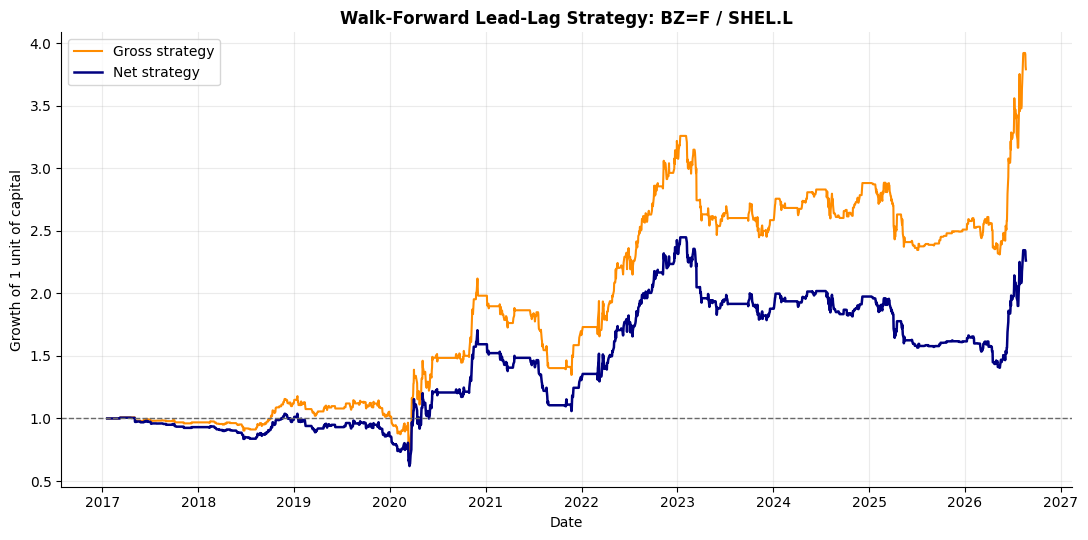

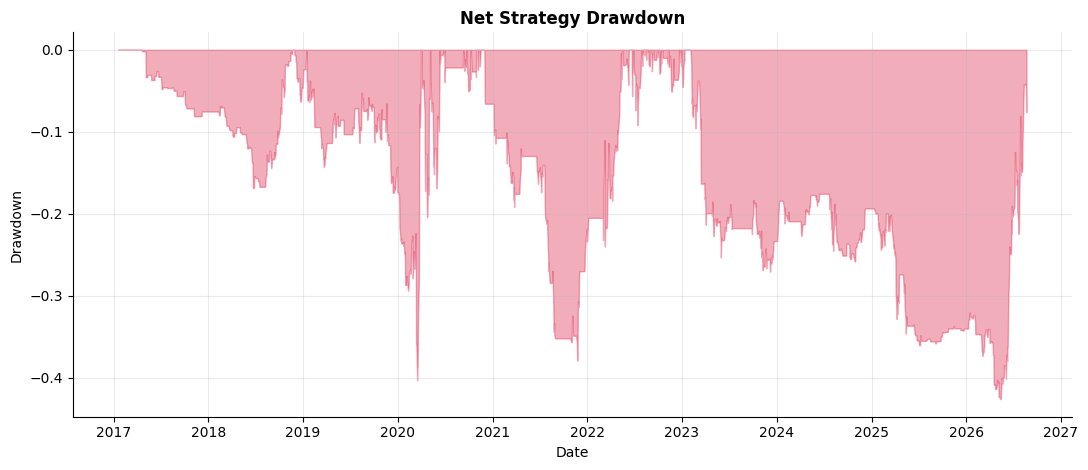

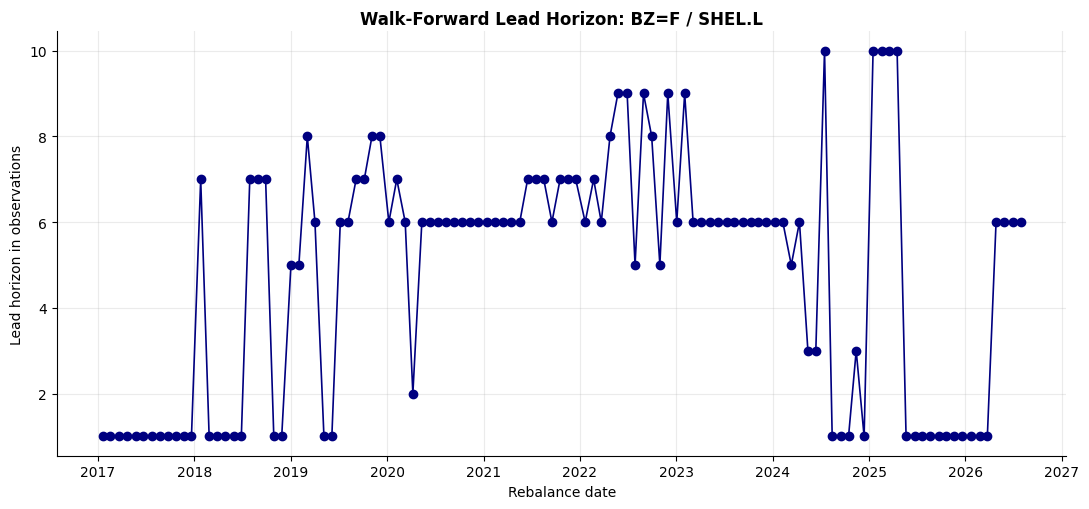

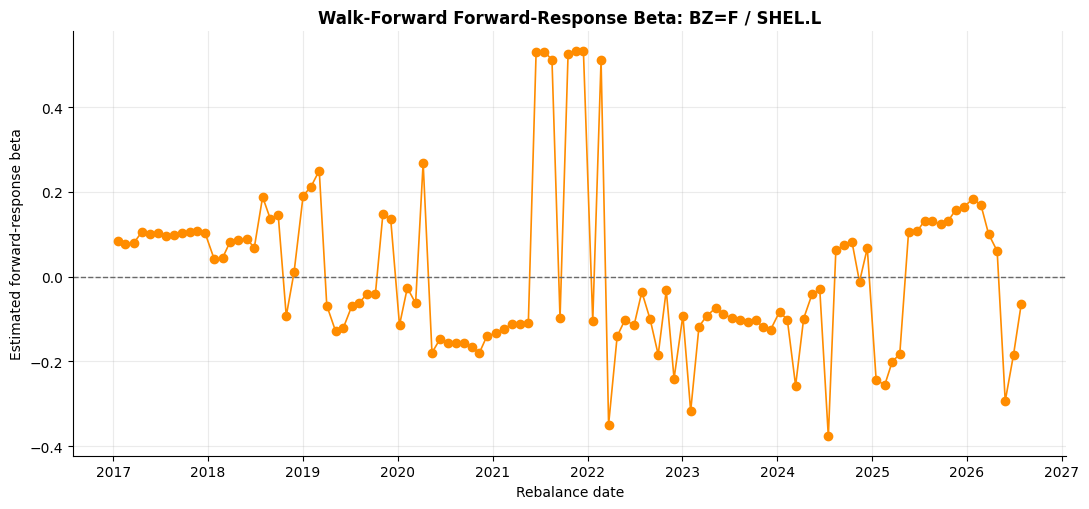

Rebalance_Date,Leader,Follower,Lead_Horizon,Same_Day_Correlation,Lag_Correlation,Relation,Beta,Beta_Relation,Forward_R_Squared,Beta_P_Value,Signal_Alignment,Lag_P_Value_Adjusted,Lag_Significant,Eligible
2024-02-09 00:00:00,BZ=F,SHEL.L,6,0.499,-0.125,Inverse,-0.101,Inverse,0.005,0.1329,True,0.1201,False,True
2024-03-12 00:00:00,SHEL.L,BZ=F,5,0.500,-0.129,Inverse,-0.257,Inverse,0.007,0.0712,True,0.0893,False,True
2024-04-12 00:00:00,BZ=F,SHEL.L,6,0.522,-0.080,Inverse,-0.099,Inverse,0.004,0.1691,True,1.0000,False,True
2024-05-14 00:00:00,BZ=F,SHEL.L,3,0.516,-0.093,Inverse,-0.042,Inverse,0.001,0.4341,True,0.8126,False,True
2024-06-13 00:00:00,BZ=F,SHEL.L,3,0.513,-0.085,Inverse,-0.029,Inverse,0.001,0.5899,True,1.0000,False,True
2024-07-16 00:00:00,SHEL.L,BZ=F,10,0.512,-0.095,Inverse,-0.377,Inverse,0.009,0.0379,True,0.7385,False,True
2024-08-14 00:00:00,BZ=F,SHEL.L,1,0.494,0.095,Same-direction,0.063,Same-direction,0.008,0.0429,True,0.7403,False,True
2024-09-16 00:00:00,BZ=F,SHEL.L,1,0.490,0.103,Same-direction,0.075,Same-direction,0.011,0.0186,True,0.4597,False,True
2024-10-15 00:00:00,BZ=F,SHEL.L,1,0.487,0.125,Same-direction,0.082,Same-direction,0.013,0.0100,True,0.1178,False,True
2024-11-13 00:00:00,BZ=F,SHEL.L,3,0.493,-0.103,Inverse,-0.012,Inverse,0.000,0.8274,True,0.4596,False,True


In [36]:
plot_backtest_equity(BACKTEST_RESULTS)
plt.show()

plot_backtest_drawdown(BACKTEST_RESULTS)
plt.show()

plot_backtest_model_history(BACKTEST_RESULTS)
plt.show()

plot_backtest_beta_history(BACKTEST_RESULTS)
plt.show()

display(
    format_backtest_model_history(BACKTEST_RESULTS)
    .style
    .hide(axis="index")
    .format({
        "Same_Day_Correlation": "{:.3f}",
        "Lag_Correlation": "{:.3f}",
        "Beta": "{:.3f}",
        "Forward_R_Squared": "{:.3f}",
        "Beta_P_Value": "{:.4f}",
        "Lag_P_Value_Adjusted": "{:.4f}"
    })
)


In [37]:
if BACKTEST_RESULTS["trades"].empty:
    display(Markdown("**No trades were generated under the current walk-forward controls.**"))
else:
    display(
        BACKTEST_RESULTS["trades"]
        .tail(20)
        .style
        .format({
            "Leader_Z": "{:.2f}",
            "Lag_Correlation": "{:.3f}",
            "Lag_P_Value_Adjusted": "{:.4f}",
            "Same_Day_Correlation": "{:.3f}",
            "Forward_Beta": "{:.3f}",
            "Forward_Beta_P_Value": "{:.4f}",
            "Gross_Return": "{:.2%}",
            "Net_Return": "{:.2%}"
        })
    )


,Signal_Date,Entry_Date,Exit_Date,Leader,Follower,Direction,Leader_Z,Holding_Observations,Best_Lag,Lead_Horizon,Lag_Correlation,Relation,Lag_P_Value_Adjusted,Same_Day_Correlation,Forward_Beta,Beta_Relation,Signal_Alignment,Forward_Beta_P_Value,Gross_Return,Net_Return,Execution
238,2026-03-24 00:00:00,2026-03-25 00:00:00,2026-03-25 00:00:00,BZ=F,SHEL.L,1.000000,2.53,1,1,1,0.240,Same-direction,0.0000,0.460,0.168,Same-direction,True,0.0000,1.27%,1.07%,Next adjusted open to adjusted close
239,2026-03-26 00:00:00,2026-03-27 00:00:00,2026-03-27 00:00:00,BZ=F,SHEL.L,1.000000,2.61,1,1,1,0.202,Same-direction,0.0002,0.469,0.101,Same-direction,True,0.0002,0.64%,0.44%,Next adjusted open to adjusted close
240,2026-03-31 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,BZ=F,SHEL.L,1.000000,2.28,1,1,1,0.202,Same-direction,0.0002,0.469,0.101,Same-direction,True,0.0002,-2.40%,-2.60%,Next adjusted open to adjusted close
241,2026-04-02 00:00:00,2026-04-07 00:00:00,2026-04-07 00:00:00,BZ=F,SHEL.L,1.000000,3.56,1,1,1,0.202,Same-direction,0.0002,0.469,0.101,Same-direction,True,0.0002,0.58%,0.38%,Next adjusted open to adjusted close
242,2026-04-08 00:00:00,2026-04-09 00:00:00,2026-04-09 00:00:00,BZ=F,SHEL.L,-1.000000,-6.83,1,1,1,0.202,Same-direction,0.0002,0.469,0.101,Same-direction,True,0.0002,-0.12%,-0.32%,Next adjusted open to adjusted close
243,2026-04-13 00:00:00,2026-04-14 00:00:00,2026-04-14 00:00:00,BZ=F,SHEL.L,1.000000,2.02,1,1,1,0.202,Same-direction,0.0002,0.469,0.101,Same-direction,True,0.0002,-2.10%,-2.30%,Next adjusted open to adjusted close
244,2026-04-16 00:00:00,2026-04-17 00:00:00,2026-04-17 00:00:00,BZ=F,SHEL.L,1.000000,2.17,1,1,1,0.202,Same-direction,0.0002,0.469,0.101,Same-direction,True,0.0002,-5.60%,-5.80%,Next adjusted open to adjusted close
245,2026-04-20 00:00:00,2026-04-21 00:00:00,2026-04-21 00:00:00,BZ=F,SHEL.L,1.000000,2.60,1,1,1,0.202,Same-direction,0.0002,0.469,0.101,Same-direction,True,0.0002,0.34%,0.14%,Next adjusted open to adjusted close
246,2026-04-22 00:00:00,2026-04-23 00:00:00,2026-04-23 00:00:00,BZ=F,SHEL.L,1.000000,1.61,1,1,1,0.202,Same-direction,0.0002,0.469,0.101,Same-direction,True,0.0002,-0.83%,-1.03%,Next adjusted open to adjusted close
247,2026-04-27 00:00:00,2026-04-28 00:00:00,2026-05-06 00:00:00,BZ=F,SHEL.L,1.000000,1.10,6,6,6,-0.122,Inverse,0.1481,0.537,0.061,Same-direction,False,0.3601,-1.49%,-1.69%,Next adjusted open to adjusted close


## 30. Backtest conclusion

The conclusion below is generated from the selected pair's walk-forward results. It reports net and gross outcomes separately and does not convert historical performance into a claim of future profitability.


In [38]:
display(
    Markdown(
        build_backtest_conclusion(
            BACKTEST_RESULTS
        )
    )
)


### Walk-forward backtest conclusion: BZ=F / SHEL.L

After the formation period, the net strategy return is **126.20%** versus **279.05%** before transaction costs. The estimated cost drag is therefore **152.85%** of starting capital under the configured turnover assumption.

The strategy CAGR is **9.07%**, the zero-risk-free-rate Sharpe ratio is **0.489** when defined, and maximum drawdown is **-42.59%**. The engine generated **258 trades**, with a win rate of **48.1%** and market exposure of **40.8%**.

Across formation windows, **100.0%** of models passed the configured relationship filters. The most common estimated direction was **BZ=F → SHEL.L**, the median lead horizon was **6.0 observations**, and the forward-response beta agreed in sign with the selected lag correlation in **92.0%** of re-estimations.

On these metrics the strategy shows positive but limited risk-adjusted performance in this historical walk-forward run. This is an out-of-sample walk-forward test of the pair-specific signal construction, but it is not a proof of deployable alpha. The selected pair, parameter grid and current Yahoo Finance data source are themselves research choices, and the daily next-open execution from daily adjusted OHLC data remains an approximation of real fills, spreads and intraday slippage.

## 31. Yahoo Finance universe construction

The discovery engine removes the need to maintain a hard-coded ticker list. It uses Yahoo Finance's equity screener to construct a **current** universe from transparent liquidity and size controls.

The default universe requires:

$$ \text{Market Cap}\ge \$5\text{bn} $$

$$ \text{Price}\ge \$5 $$

$$ \text{Average Daily Volume}_{3m}\ge 1{,}000{,}000 $$

and restricts the search to the configured region and exchanges.

Yahoo Finance limits a custom screener response to 250 rows per request. The implementation therefore supports offset-based pagination and then downloads historical adjusted prices in chunks.

The historical coverage rule keeps ticker $i$ only when:

$$ \frac{\text{available price observations}_i}{\text{union of downloaded dates}}\ge q $$

where $q$ is `DISCOVERY_MIN_COVERAGE`.

### Point-in-time warning

The Yahoo Finance screener describes the **current** market universe. It does not reconstruct which securities would have satisfied the same filters at every historical date. Consequently, the discovery layer is appropriate for finding relationships to research now, but it is not by itself a survivorship-bias-free historical universe simulation.


In [39]:
def normalise_issuer_name(name):
    text = str(name or "").lower()
    text = re.sub(r"\b(class|cl)\s*[a-z]\b", " ", text)
    text = re.sub(r"\b(adr|ads|american depositary shares?|depositary shares?|sponsored|spon)\b", " ", text)
    text = re.sub(r"\b(incorporated|inc|corp|corporation|plc|ltd|limited|company|co|holdings?|group)\b", " ", text)
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return " ".join(text.split())


def symbol_class_root(symbol):
    text = str(symbol or "").upper().strip()
    return re.sub(r"[-.](A|B|C)$", "", text)


def infer_listing_context(name, country, exchange, market):
    text = str(name or "").lower()
    country_text = str(country or "").strip()
    adr_terms = (
        " adr",
        "adr ",
        "american depositary",
        "depositary share",
        "sponsored",
        " spon"
    )
    looks_like_adr = any(term in f" {text} " for term in adr_terms)

    if country_text and country_text.lower() not in {
        "united states",
        "united states of america",
        "usa",
        "us"
    }:
        return "Foreign issuer or domicile - session timing may matter"

    if looks_like_adr:
        return "Potential ADR or depositary listing - session timing may matter"

    if exchange in {"NMS", "NYQ", "NGM", "NCM", "ASE"}:
        return "US listing - issuer domicile should still be verified"

    return "Listing-session context not verified"


def build_issuer_lookup(universe):
    if universe.empty or "Issuer_Key" not in universe:
        return {}
    return (
        universe
        .drop_duplicates("Symbol")
        .set_index("Symbol")["Issuer_Key"]
        .to_dict()
    )


def build_listing_context_lookup(universe):
    if universe.empty or "Listing_Context" not in universe:
        return {}
    return (
        universe
        .drop_duplicates("Symbol")
        .set_index("Symbol")["Listing_Context"]
        .to_dict()
    )


def build_yahoo_equity_query(
    region,
    exchanges,
    min_market_cap,
    min_price,
    min_average_volume
):
    filters = [
        yf.EquityQuery("eq", ["region", region]),
        yf.EquityQuery("gte", ["intradaymarketcap", min_market_cap]),
        yf.EquityQuery("gte", ["intradayprice", min_price]),
        yf.EquityQuery("gte", ["avgdailyvol3m", min_average_volume])
    ]

    cleaned_exchanges = [
        exchange.strip()
        for exchange in exchanges
        if exchange.strip()
    ]

    if cleaned_exchanges:
        filters.append(
            yf.EquityQuery(
                "is-in",
                ["exchange", *cleaned_exchanges]
            )
        )

    return yf.EquityQuery("and", filters)


def screen_yahoo_equity_universe(
    region,
    exchanges,
    min_market_cap,
    min_price,
    min_average_volume,
    universe_size
):
    if not region.strip():
        raise ValueError("Discovery region cannot be blank.")

    if universe_size < 2:
        raise ValueError("DISCOVERY_UNIVERSE_SIZE must be at least 2.")

    query = build_yahoo_equity_query(
        region,
        exchanges,
        min_market_cap,
        min_price,
        min_average_volume
    )

    page_size = min(250, universe_size)
    quotes = []
    offset = 0
    total = None

    while len(quotes) < universe_size:
        response = yf.screen(
            query,
            offset=offset,
            size=page_size,
            sortField="intradaymarketcap",
            sortAsc=False
        )

        page = response.get("quotes", [])

        if not page:
            break

        quotes.extend(page)
        offset += len(page)

        if total is None:
            total = response.get("total")

        if len(page) < page_size:
            break

        if total is not None and offset >= total:
            break

    seen = set()
    rows = []

    for quote in quotes:
        symbol = quote.get("symbol")

        if not symbol or symbol in seen:
            continue

        quote_type = quote.get("quoteType")

        if quote_type not in (None, "EQUITY"):
            continue

        seen.add(symbol)

        name = quote.get("shortName") or quote.get("longName") or symbol
        exchange = quote.get("exchange")
        country = quote.get("country")
        market = quote.get("market")

        rows.append({
            "Symbol": symbol,
            "Name": name,
            "Issuer_Key": normalise_issuer_name(name),
            "Exchange": exchange,
            "Full_Exchange_Name": quote.get("fullExchangeName"),
            "Region": quote.get("region"),
            "Country": country,
            "Market": market,
            "Currency": quote.get("currency"),
            "Listing_Context": infer_listing_context(
                name,
                country,
                exchange,
                market
            ),
            "Market_Cap": quote.get("marketCap") or quote.get("intradaymarketcap"),
            "Price": quote.get("regularMarketPrice") or quote.get("intradayprice"),
            "Average_Volume_3M": quote.get("averageDailyVolume3Month") or quote.get("avgdailyvol3m")
        })

        if len(rows) >= universe_size:
            break

    universe = pd.DataFrame(rows)

    if len(universe) < 2:
        raise ValueError("Yahoo Finance screening returned fewer than two usable equities.")

    return universe



def download_universe_prices(
    symbols,
    start_date,
    end_date,
    chunk_size
):
    _, closes = download_universe_market_data(
        symbols,
        start_date,
        end_date,
        chunk_size
    )
    return closes


def download_universe_market_data(
    symbols,
    start_date,
    end_date,
    chunk_size
):
    symbols = list(dict.fromkeys(symbols))

    if len(symbols) < 2:
        raise ValueError("At least two symbols are required for discovery.")

    open_chunks = []
    close_chunks = []

    for start in range(0, len(symbols), chunk_size):
        batch = symbols[start:start + chunk_size]

        raw = yf.download(
            batch,
            start=start_date,
            end=end_date,
            auto_adjust=True,
            progress=False,
            group_by="column",
            threads=True
        )

        if raw.empty:
            continue

        if isinstance(raw.columns, pd.MultiIndex):
            opens = raw["Open"].copy()
            closes = raw["Close"].copy()
        else:
            opens = raw[["Open"]].copy()
            closes = raw[["Close"]].copy()
            opens.columns = batch[:1]
            closes.columns = batch[:1]

        if isinstance(opens, pd.Series):
            opens = opens.to_frame()

        if isinstance(closes, pd.Series):
            closes = closes.to_frame()

        open_chunks.append(opens)
        close_chunks.append(closes)

    if not close_chunks:
        raise ValueError("Yahoo Finance returned no historical prices for the screened universe.")

    open_prices = pd.concat(open_chunks, axis=1)
    close_prices = pd.concat(close_chunks, axis=1)

    open_prices = open_prices.loc[:, ~open_prices.columns.duplicated()]
    close_prices = close_prices.loc[:, ~close_prices.columns.duplicated()]

    retained = [
        symbol
        for symbol in symbols
        if symbol in close_prices.columns
    ]

    open_prices = open_prices.reindex(columns=retained)
    close_prices = close_prices.reindex(columns=retained)

    return open_prices, close_prices



def prepare_discovery_returns(
    prices,
    min_coverage
):
    coverage = prices.notna().mean()
    eligible = coverage[coverage >= min_coverage].index.tolist()

    if len(eligible) < 2:
        raise ValueError("Fewer than two securities satisfy the historical coverage requirement.")

    filtered_prices = prices[eligible].copy()
    returns = np.log(
        filtered_prices / filtered_prices.shift(1)
    )

    return filtered_prices, returns, coverage.loc[eligible].sort_values(ascending=False)


def screen_correlated_pairs(
    returns,
    minimum_correlation,
    maximum_candidates,
    issuer_lookup=None,
    exclude_same_issuer=False
):
    correlation = returns.corr(min_periods=120)
    symbols = list(correlation.columns)
    rows = []
    issuer_lookup = issuer_lookup or {}

    for i, asset_a in enumerate(symbols):
        for asset_b in symbols[i + 1:]:
            value = correlation.loc[asset_a, asset_b]

            if pd.isna(value):
                continue

            if abs(value) < minimum_correlation:
                continue

            issuer_a = issuer_lookup.get(asset_a, "")
            issuer_b = issuer_lookup.get(asset_b, "")
            same_issuer = bool(
                (
                    issuer_a
                    and issuer_b
                    and issuer_a == issuer_b
                )
                or (
                    symbol_class_root(asset_a) == symbol_class_root(asset_b)
                    and asset_a != asset_b
                )
            )

            if exclude_same_issuer and same_issuer:
                continue

            observations = int(
                returns[[asset_a, asset_b]]
                .dropna()
                .shape[0]
            )

            rows.append({
                "Asset_A": asset_a,
                "Asset_B": asset_b,
                "Same_Day_Correlation": float(value),
                "Observations": observations,
                "Same_Issuer": same_issuer
            })

    candidates = pd.DataFrame(rows)

    if candidates.empty:
        return candidates

    candidates["Absolute_Same_Day_Correlation"] = (
        candidates["Same_Day_Correlation"].abs()
    )

    return (
        candidates
        .sort_values(
            "Absolute_Same_Day_Correlation",
            ascending=False
        )
        .head(maximum_candidates)
        .reset_index(drop=True)
    )



def analyse_discovery_candidate(
    returns,
    asset_a,
    asset_b,
    max_lag,
    rolling_window,
    rolling_step
):
    pair = returns[[asset_a, asset_b]].dropna()

    if len(pair) <= max(2 * max_lag + 60, rolling_window):
        return None

    lag_table, lag_tests, best_row = equal_sample_lag_scan(
        pair,
        asset_a,
        asset_b,
        max_lag
    )

    best_lag = int(best_row["Lag"])
    best_corr = float(best_row["Correlation"])

    if best_lag > 0:
        leader = asset_a
        follower = asset_b
    else:
        leader = asset_b
        follower = asset_a

    rolling_lags = rolling_lag_stability(
        pair,
        asset_a,
        asset_b,
        max_lag,
        rolling_window,
        rolling_step
    )

    fixed_lag = fixed_lag_stability(
        pair,
        asset_a,
        asset_b,
        best_lag,
        rolling_window,
        rolling_step
    )

    sign_stability = (
        np.sign(fixed_lag["Selected_Lag_Correlation"])
        == np.sign(best_corr)
    ).mean()

    lag_win_share = (
        rolling_lags["Best_Lag"] == best_lag
    ).mean()

    relation = "Same-direction" if best_corr > 0 else "Inverse"

    if relation == "Same-direction":
        trading_implication = (
            f"{leader} ↑ → {follower} ↑; "
            f"{leader} ↓ → {follower} ↓"
        )
    else:
        trading_implication = (
            f"{leader} ↑ → {follower} ↓; "
            f"{leader} ↓ → {follower} ↑"
        )

    return {
        "Leader": leader,
        "Follower": follower,
        "Best_Lag": best_lag,
        "Lead_Horizon": abs(best_lag),
        "Lag_Correlation": best_corr,
        "Absolute_Lag_Correlation": abs(best_corr),
        "Lag_P_Value_Adjusted": float(best_row["P_Value_Adjusted"]),
        "Lag_Significant": bool(best_row["Significant_After_Correction"]),
        "Sign_Stability": float(sign_stability),
        "Lag_Win_Share": float(lag_win_share),
        "Relation": relation,
        "Trading_Implication": trading_implication
    }


def calculate_opportunity_score(
    frame,
    weight_correlation,
    weight_lag,
    weight_sign_stability,
    weight_lag_win
):
    weights = np.array([
        weight_correlation,
        weight_lag,
        weight_sign_stability,
        weight_lag_win
    ], dtype=float)

    if np.any(weights < 0):
        raise ValueError("Discovery score weights cannot be negative.")

    if weights.sum() == 0:
        raise ValueError("At least one discovery score weight must be positive.")

    weights = weights / weights.sum()

    score = 100 * (
        weights[0] * frame["Same_Day_Correlation"].abs()
        + weights[1] * frame["Lag_Correlation"].abs()
        + weights[2] * frame["Sign_Stability"]
        + weights[3] * frame["Lag_Win_Share"]
    )

    return score, weights


def run_relationship_discovery(
    region,
    exchanges,
    min_market_cap,
    min_price,
    min_average_volume,
    universe_size,
    history_start,
    history_end,
    chunk_size,
    min_coverage,
    minimum_correlation,
    maximum_candidates,
    max_lag,
    minimum_lag_correlation,
    deep_candidates,
    rolling_window,
    rolling_step,
    weight_correlation,
    weight_lag,
    weight_sign_stability,
    weight_lag_win,
    exclude_same_issuer=DISCOVERY_EXCLUDE_SAME_ISSUER
):
    if pd.Timestamp(history_start) >= pd.Timestamp(history_end):
        raise ValueError("Discovery history start must be earlier than history end.")

    if chunk_size < 1 or maximum_candidates < 1 or deep_candidates < 1:
        raise ValueError("Discovery chunk and candidate controls must be positive integers.")

    if not 0 < min_coverage <= 1:
        raise ValueError("DISCOVERY_MIN_COVERAGE must lie in (0, 1].")

    if not 0 <= minimum_correlation <= 1 or not 0 <= minimum_lag_correlation <= 1:
        raise ValueError("Discovery correlation thresholds must lie between 0 and 1.")

    universe = screen_yahoo_equity_universe(
        region,
        exchanges,
        min_market_cap,
        min_price,
        min_average_volume,
        universe_size
    )

    open_prices, close_prices = download_universe_market_data(
        universe["Symbol"].tolist(),
        history_start,
        history_end,
        chunk_size
    )

    filtered_prices, returns, coverage = prepare_discovery_returns(
        close_prices,
        min_coverage
    )

    retained_symbols = filtered_prices.columns.tolist()
    open_prices = open_prices.reindex(
        index=filtered_prices.index,
        columns=retained_symbols
    )

    issuer_lookup = build_issuer_lookup(universe)
    context_lookup = build_listing_context_lookup(universe)

    initial_candidates = screen_correlated_pairs(
        returns,
        minimum_correlation,
        maximum_candidates,
        issuer_lookup,
        exclude_same_issuer
    )

    if initial_candidates.empty:
        raise ValueError("No pairs satisfy the contemporaneous-correlation threshold.")

    deep_rows = []

    for _, row in initial_candidates.head(deep_candidates).iterrows():
        analysis = analyse_discovery_candidate(
            returns,
            row["Asset_A"],
            row["Asset_B"],
            max_lag,
            rolling_window,
            rolling_step
        )

        if analysis is None:
            continue

        deep_rows.append({
            **row.to_dict(),
            **analysis
        })

    deep_results = pd.DataFrame(deep_rows)

    if deep_results.empty:
        raise ValueError("No candidate pairs have enough history for the deeper lag analysis.")

    reject, fdr_adjusted, _, _ = multipletests(
        deep_results["Lag_P_Value_Adjusted"],
        alpha=0.05,
        method="fdr_bh"
    )

    deep_results["Scanner_FDR_Adjusted"] = fdr_adjusted
    deep_results["Scanner_FDR_Significant"] = reject
    deep_results["Scanner_FDR_Exploratory"] = (
        deep_results["Scanner_FDR_Adjusted"] <= 0.10
    )

    deep_results["Validation_Status"] = np.select(
        [
            deep_results["Scanner_FDR_Adjusted"] <= 0.05,
            deep_results["Scanner_FDR_Adjusted"] <= 0.10
        ],
        [
            "Validated: FDR <= 5%",
            "Exploratory: FDR <= 10%"
        ],
        default="Not scanner-validated"
    )

    opportunities = deep_results[
        deep_results["Absolute_Lag_Correlation"] >= minimum_lag_correlation
    ].copy()

    if opportunities.empty:
        raise ValueError("No candidate pairs satisfy the lag-correlation threshold after deep analysis.")

    score, normalised_weights = calculate_opportunity_score(
        opportunities,
        weight_correlation,
        weight_lag,
        weight_sign_stability,
        weight_lag_win
    )

    opportunities["Opportunity_Score"] = score
    opportunities["Statistical_Evidence_Rank"] = (
        opportunities["Scanner_FDR_Adjusted"]
        .rank(method="min", ascending=True)
        .astype(int)
    )

    opportunities["Leader_Listing_Context"] = (
        opportunities["Leader"].map(context_lookup).fillna("Context unavailable")
    )
    opportunities["Follower_Listing_Context"] = (
        opportunities["Follower"].map(context_lookup).fillna("Context unavailable")
    )

    opportunities = (
        opportunities
        .sort_values(
            ["Opportunity_Score", "Absolute_Lag_Correlation"],
            ascending=False
        )
        .reset_index(drop=True)
    )

    return {
        "universe": universe,
        "prices": filtered_prices,
        "open_prices": open_prices,
        "returns": returns,
        "coverage": coverage,
        "initial_candidates": initial_candidates,
        "deep_results": deep_results,
        "opportunities": opportunities,
        "weights": normalised_weights,
        "history_start": history_start,
        "history_end": history_end,
        "issuer_lookup": issuer_lookup,
        "listing_context_lookup": context_lookup,
        "execution_mode": "next_open",
        "config": {
            "min_coverage": min_coverage,
            "minimum_correlation": minimum_correlation,
            "maximum_candidates": maximum_candidates,
            "max_lag": max_lag,
            "minimum_lag_correlation": minimum_lag_correlation,
            "deep_candidates": deep_candidates,
            "rolling_window": rolling_window,
            "rolling_step": rolling_step,
            "weight_correlation": weight_correlation,
            "weight_lag": weight_lag,
            "weight_sign_stability": weight_sign_stability,
            "weight_lag_win": weight_lag_win,
            "exclude_same_issuer": bool(exclude_same_issuer)
        }
    }



## 32. Correlation funnel, lag direction and scanner validation

A universe of $N$ securities contains:

$$ \frac{N(N-1)}{2} $$

unique unordered pairs.

With 200 securities that is:

$$ \frac{200\times199}{2}=19{,}900 $$

pairs. Running bootstrap, Granger tests and rolling lag analysis on every pair would be computationally expensive and statistically undisciplined, so the discovery engine uses a funnel.

The first stage calculates the pairwise same-day correlation matrix and retains only pairs satisfying:

$$ |\rho_{ij}(0)|\ge \rho_{\min} $$

The strongest retained pairs then receive deeper equal-sample lag analysis. For an internally ordered pair $(A,B)$ the scanner estimates:

$$ k^{*}=\arg\max_{k\ne0}\left|\operatorname{Corr}\left(r^A_t,r^B_{t+k}\right)\right| $$

The sign of $k^{*}$ determines direction:

$$ k^{*}>0 \Rightarrow A\text{ leads }B $$

$$ k^{*}<0 \Rightarrow B\text{ leads }A $$

The interface therefore does **not** present the signed internal lag beside an already-derived leader/follower label. It reports a non-negative `Lead_Horizon`:

$$ h=|k^{*}| $$

together with explicit `Leader` and `Follower` fields. This prevents a row such as `C → BAC` from being misread merely because the internal ordered pair happened to be stored as `(BAC, C)` and produced $k^{*}=-1$.

The sign of the lagged correlation is separate from the direction of the lag. If the selected lagged correlation is positive, the relationship is labelled **same-direction**. If it is negative, it is labelled **inverse**. The scanner also prints a human-readable trading implication such as:

`C ↑ → BAC ↑; C ↓ → BAC ↓`

or

`SMFG ↑ → MFG ↓; SMFG ↓ → MFG ↑`

These statements describe the historical association identified by the scanner. They are not trade recommendations and are not used as evidence of profitability until the walk-forward backtest is run.

The deep stage also measures:

- **sign stability:** the share of rolling windows in which the selected lag keeps its full-sample correlation sign;
- **lag-win share:** the share of rolling windows in which the selected lag is the strongest non-zero lag;
- **within-pair Bonferroni p-value:** correction for searching multiple lags inside that pair;
- **scanner FDR-adjusted p-value:** Benjamini-Hochberg correction across the pairs that reached the deep-analysis stage.

For scanner-level false-discovery-rate control, let the deep-stage pair p-values after within-pair correction be ordered:

$$ p_{(1)}\le p_{(2)}\le\cdots\le p_{(m)} $$

At target FDR level $q$, the Benjamini-Hochberg rule finds the largest index $i$ satisfying:

$$ p_{(i)}\le\frac{i}{m}q $$

The interface classifies candidates as:

- **Validated: FDR ≤ 5%**
- **Exploratory: FDR ≤ 10%**
- **Not scanner-validated**

The 10% category is deliberately labelled exploratory rather than validated. It can be useful for deciding what to investigate next, but it is weaker evidence.

Because the same-day correlation funnel occurs before the deep test, the reported scanner FDR is conditional on the screened candidate set rather than a universal correction over every security available from Yahoo Finance.


## 33. Opportunity score versus statistical evidence

The scanner ranks surviving pairs using a transparent economic/research score rather than a black-box model.

For candidate pair $(i,j)$:

$$ S_{ij}=100\left(w_C C_{ij}+w_L L_{ij}+w_S S^{\text{sign}}_{ij}+w_W S^{\text{win}}_{ij}\right) $$

where:

$$ C_{ij}=|\rho_{ij}(0)| $$

$$ L_{ij}=|\rho_{ij}(k^{*})| $$

$$ S^{\text{sign}}_{ij}\in[0,1] $$

is selected-lag sign stability, and

$$ S^{\text{win}}_{ij}\in[0,1] $$

is the selected-lag rolling win share.

The default weights are:

$$ (w_C,w_L,w_S,w_W)=(0.25,0.35,0.25,0.15) $$

and are normalised to sum to one before use.

The score deliberately gives the greatest weight to lag magnitude, but it is **not a statistical significance measure and not an expected-return forecast**. A candidate can rank highly because it has a strong, stable pattern while still failing scanner-wide FDR control.

The interface therefore reports two separate rankings:

- `Opportunity_Score` ranks the strength and stability of the historical pattern.
- `Statistical_Evidence_Rank` ranks candidates by scanner FDR-adjusted p-value.

The highest-scoring candidate and the statistically strongest candidate are allowed to be different. That disagreement is informative rather than something to be tuned away.

Every discovered relationship remains a candidate until the walk-forward backtest evaluates whether re-estimated signals survive realistic timing, turnover and transaction costs.


## 34. True walk-forward discovery backtest

Backtesting a pair after selecting it from the full historical sample does not completely solve selection bias. The pair-level trading model may be walk-forward while the **choice of pair** still benefited from future information.

The scanner backtest therefore repeats the discovery process itself through time.

At rebalance date $T$, only the preceding formation window is visible:

$$ \mathcal{I}_T=\{r_t:T-W\le t<T\} $$

The scanner constructs a candidate set using only $\mathcal{I}_T$:

$$ \mathcal{C}_T=\operatorname{Scanner}\left(\mathcal{I}_T\right) $$

It then selects the top $N$ relationships according to a pre-specified rule:

$$ \mathcal{S}_T=\operatorname{TopN}\left(\mathcal{C}_T\right) $$

and trades only during the next out-of-sample block. At the following rebalance date the entire screen is repeated from newly available trailing data.

This removes the major post-selection problem created by discovering a pair with 2020-2026 data and then evaluating that same pair over an overlapping historical period. The current Yahoo Finance universe is still today's survivor set, so the test remains subject to current-universe survivorship bias. What becomes genuinely walk-forward is the **relationship selection, direction, horizon and trading model** inside that fixed current universe.

The scanner portfolio treats each selected relationship as an equal-weight research sleeve. A sleeve trades only its estimated follower. Signals use the leader's completed return and enter the follower at the next available adjusted open. The position then exits at an adjusted close after the estimated horizon. Sleeves are allowed to overlap across different relationships, while overlapping trades inside the same selected pair are prevented.

The default scanner-backtest selection rule uses `Opportunity_Score`. An alternative evidence rule can rank by scanner FDR-adjusted p-value. These are deliberately separate hypotheses rather than weights tuned after seeing performance.

Same-issuer and obvious share-class pairs can be excluded before ranking. This prevents near-duplicate economic exposures such as two share classes of the same company from being treated as ordinary cross-asset discoveries.


In [40]:
def analyse_discovery_training_window(
    returns,
    minimum_correlation,
    maximum_candidates,
    max_lag,
    minimum_lag_correlation,
    deep_candidates,
    rolling_window,
    rolling_step,
    weight_correlation,
    weight_lag,
    weight_sign_stability,
    weight_lag_win,
    issuer_lookup=None,
    exclude_same_issuer=False
):
    initial_candidates = screen_correlated_pairs(
        returns,
        minimum_correlation,
        maximum_candidates,
        issuer_lookup,
        exclude_same_issuer
    )

    if initial_candidates.empty:
        return {
            "initial_candidates": initial_candidates,
            "deep_results": pd.DataFrame(),
            "opportunities": pd.DataFrame()
        }

    deep_rows = []

    for _, row in initial_candidates.head(deep_candidates).iterrows():
        pair = returns[[row["Asset_A"], row["Asset_B"]]].dropna()

        effective_rolling_window = min(
            rolling_window,
            len(pair) - 1
        )

        if effective_rolling_window <= 2 * max_lag + 20:
            continue

        analysis = analyse_discovery_candidate(
            returns,
            row["Asset_A"],
            row["Asset_B"],
            max_lag,
            effective_rolling_window,
            rolling_step
        )

        if analysis is None:
            continue

        deep_rows.append({
            **row.to_dict(),
            **analysis
        })

    deep_results = pd.DataFrame(deep_rows)

    if deep_results.empty:
        return {
            "initial_candidates": initial_candidates,
            "deep_results": deep_results,
            "opportunities": pd.DataFrame()
        }

    reject, fdr_adjusted, _, _ = multipletests(
        deep_results["Lag_P_Value_Adjusted"],
        alpha=0.05,
        method="fdr_bh"
    )

    deep_results["Scanner_FDR_Adjusted"] = fdr_adjusted
    deep_results["Scanner_FDR_Significant"] = reject
    deep_results["Validation_Status"] = np.select(
        [
            deep_results["Scanner_FDR_Adjusted"] <= 0.05,
            deep_results["Scanner_FDR_Adjusted"] <= 0.10
        ],
        [
            "Validated: FDR <= 5%",
            "Exploratory: FDR <= 10%"
        ],
        default="Not scanner-validated"
    )

    opportunities = deep_results[
        deep_results["Absolute_Lag_Correlation"] >= minimum_lag_correlation
    ].copy()

    if opportunities.empty:
        return {
            "initial_candidates": initial_candidates,
            "deep_results": deep_results,
            "opportunities": opportunities
        }

    score, _ = calculate_opportunity_score(
        opportunities,
        weight_correlation,
        weight_lag,
        weight_sign_stability,
        weight_lag_win
    )

    opportunities["Opportunity_Score"] = score
    opportunities["Statistical_Evidence_Rank"] = (
        opportunities["Scanner_FDR_Adjusted"]
        .rank(method="min", ascending=True)
        .astype(int)
    )

    opportunities = (
        opportunities
        .sort_values(
            ["Opportunity_Score", "Absolute_Lag_Correlation"],
            ascending=False
        )
        .reset_index(drop=True)
    )

    return {
        "initial_candidates": initial_candidates,
        "deep_results": deep_results,
        "opportunities": opportunities
    }



def select_walk_forward_candidates(
    opportunities,
    top_n,
    selection_rule,
    fdr_gate
):
    if opportunities.empty:
        return opportunities.copy()

    if selection_rule not in {"score", "evidence"}:
        raise ValueError("Scanner-backtest selection rule must be 'score' or 'evidence'.")

    if fdr_gate not in {"all", "exploratory", "validated"}:
        raise ValueError("Scanner-backtest FDR gate must be 'all', 'exploratory' or 'validated'.")

    frame = opportunities.copy()

    if fdr_gate == "exploratory":
        frame = frame[
            frame["Scanner_FDR_Adjusted"] <= 0.10
        ]
    elif fdr_gate == "validated":
        frame = frame[
            frame["Scanner_FDR_Adjusted"] <= 0.05
        ]

    if frame.empty:
        return frame

    if selection_rule == "score":
        frame = frame.sort_values(
            ["Opportunity_Score", "Scanner_FDR_Adjusted"],
            ascending=[False, True]
        )
    else:
        frame = frame.sort_values(
            ["Scanner_FDR_Adjusted", "Opportunity_Score"],
            ascending=[True, False]
        )

    frame = frame.head(top_n).copy()
    frame["Selection_Rank"] = np.arange(1, len(frame) + 1)

    return frame


def simulate_selected_pair_block(
    full_returns,
    open_prices,
    close_prices,
    model,
    selected_row,
    test_start,
    test_end,
    signal_z_threshold,
    allow_short,
    transaction_cost_bps,
    allocation,
    selection_date
):
    leader = model["Leader"]
    follower = model["Follower"]

    pair = full_returns[[leader, follower]].dropna()

    if test_end is None:
        block = pair.loc[pair.index >= test_start].copy()
    else:
        block = pair.loc[
            (pair.index >= test_start)
            & (pair.index < test_end)
        ].copy()

    if len(block) <= model["Horizon"]:
        return {
            "gross": pd.Series(dtype=float),
            "net": pd.Series(dtype=float),
            "turnover": pd.Series(dtype=float),
            "exposure": pd.Series(dtype=float),
            "trades": pd.DataFrame()
        }

    gross = pd.Series(0.0, index=block.index, dtype=float)
    turnover = pd.Series(0.0, index=block.index, dtype=float)
    exposure = pd.Series(0.0, index=block.index, dtype=float)
    trades = []
    occupied_until = -1
    cost_rate = transaction_cost_bps / 10_000

    follower_open = open_prices[follower].reindex(block.index)
    follower_close = close_prices[follower].reindex(block.index)

    for signal_position in range(len(block) - 1):
        if signal_position <= occupied_until:
            continue

        entry_position = signal_position + 1
        exit_position = entry_position + model["Horizon"] - 1

        if exit_position >= len(block):
            continue

        leader_return = float(
            block.iloc[signal_position][leader]
        )

        z_score = (
            leader_return - model["Leader_Mean"]
        ) / model["Leader_Std"]

        if abs(z_score) < signal_z_threshold:
            continue

        direction = float(
            np.sign(model["Beta"] * z_score)
        )

        if direction == 0:
            continue

        if direction < 0 and not allow_short:
            continue

        path_index = block.index[
            entry_position:exit_position + 1
        ]

        entry_open = follower_open.loc[path_index[0]]
        entry_close = follower_close.loc[path_index[0]]

        if pd.isna(entry_open) or pd.isna(entry_close) or entry_open <= 0:
            continue

        raw_path = pd.Series(
            0.0,
            index=path_index,
            dtype=float
        )

        raw_path.iloc[0] = float(
            entry_close / entry_open - 1
        )

        valid_path = True

        for step in range(1, len(path_index)):
            previous_close = follower_close.loc[path_index[step - 1]]
            current_close = follower_close.loc[path_index[step]]

            if (
                pd.isna(previous_close)
                or pd.isna(current_close)
                or previous_close <= 0
            ):
                valid_path = False
                break

            raw_path.iloc[step] = float(
                current_close / previous_close - 1
            )

        if not valid_path:
            continue

        directional_path = direction * raw_path
        weighted_path = allocation * directional_path

        gross.loc[path_index] = (
            gross.loc[path_index]
            + weighted_path
        )

        exposure.loc[path_index] = (
            exposure.loc[path_index]
            + allocation
        )

        turnover.loc[path_index[0]] += allocation
        turnover.loc[path_index[-1]] += allocation

        gross_trade = float(
            (1 + directional_path).prod() - 1
        )
        net_trade = gross_trade - 2 * cost_rate

        trades.append({
            "Selection_Date": selection_date,
            "Signal_Date": block.index[signal_position],
            "Entry_Date": path_index[0],
            "Exit_Date": path_index[-1],
            "Execution": "Next adjusted open to adjusted close",
            "Leader": leader,
            "Follower": follower,
            "Direction": direction,
            "Leader_Z": z_score,
            "Holding_Observations": model["Horizon"],
            "Lead_Horizon": model["Lead_Horizon"],
            "Lag_Correlation": model["Lag_Correlation"],
            "Relation": model["Relation"],
            "Forward_Beta": model["Beta"],
            "Beta_Relation": model["Beta_Relation"],
            "Signal_Alignment": model["Signal_Alignment"],
            "Portfolio_Weight": allocation,
            "Opportunity_Score": float(selected_row["Opportunity_Score"]),
            "Scanner_FDR_Adjusted": float(selected_row["Scanner_FDR_Adjusted"]),
            "Validation_Status": selected_row["Validation_Status"],
            "Gross_Return": gross_trade,
            "Net_Return": net_trade,
            "Weighted_Gross_Return": allocation * gross_trade,
            "Weighted_Net_Return": allocation * net_trade
        })

        occupied_until = exit_position

    costs = turnover * cost_rate
    net = gross - costs

    return {
        "gross": gross,
        "net": net,
        "turnover": turnover,
        "exposure": exposure,
        "trades": pd.DataFrame(trades)
    }



def calculate_scanner_backtest_performance(
    gross_returns,
    net_returns,
    turnover,
    exposure,
    trades,
    selection_history,
    block_history,
    transaction_cost_bps
):
    gross_equity = (1 + gross_returns).cumprod()
    net_equity = (1 + net_returns).cumprod()
    running_peak = net_equity.cummax()
    drawdown = net_equity / running_peak - 1

    annualised_volatility = float(
        net_returns.std(ddof=1) * np.sqrt(252)
    )
    annualised_return = float(
        net_returns.mean() * 252
    )
    sharpe = (
        annualised_return / annualised_volatility
        if annualised_volatility > 0
        else np.nan
    )

    years = len(net_returns) / 252
    final_equity = float(net_equity.iloc[-1])
    cagr = (
        final_equity ** (1 / years) - 1
        if years > 0 and final_equity > 0
        else np.nan
    )

    trade_frame = trades.copy()

    winners = (
        trade_frame.loc[
            trade_frame["Weighted_Net_Return"] > 0,
            "Weighted_Net_Return"
        ]
        if not trade_frame.empty
        else pd.Series(dtype=float)
    )

    losers = (
        trade_frame.loc[
            trade_frame["Weighted_Net_Return"] < 0,
            "Weighted_Net_Return"
        ]
        if not trade_frame.empty
        else pd.Series(dtype=float)
    )

    profit_factor = (
        winners.sum() / abs(losers.sum())
        if len(losers) > 0 and losers.sum() != 0
        else np.nan
    )

    block_frame = block_history.copy()
    selected_frame = selection_history.copy()

    metrics = pd.DataFrame({
        "Metric": [
            "Net total return",
            "Gross total return",
            "CAGR",
            "Annualised volatility",
            "Sharpe ratio, zero risk-free rate",
            "Maximum drawdown",
            "Number of trades",
            "Win rate",
            "Average net trade contribution",
            "Profit factor",
            "Average holding observations",
            "Time in market",
            "Average gross exposure",
            "Total one-way turnover",
            "Transaction cost assumption",
            "Rebalance periods",
            "Periods with selected relationships",
            "Average selected relationships",
            "Unique selected relationships"
        ],
        "Value": [
            float(net_equity.iloc[-1] - 1),
            float(gross_equity.iloc[-1] - 1),
            cagr,
            annualised_volatility,
            sharpe,
            float(drawdown.min()),
            int(len(trade_frame)),
            float(
                (trade_frame["Weighted_Net_Return"] > 0).mean()
            ) if not trade_frame.empty else np.nan,
            float(
                trade_frame["Weighted_Net_Return"].mean()
            ) if not trade_frame.empty else np.nan,
            float(profit_factor) if not np.isnan(profit_factor) else np.nan,
            float(
                trade_frame["Holding_Observations"].mean()
            ) if not trade_frame.empty else np.nan,
            float((exposure > 0).mean()),
            float(exposure.mean()),
            float(turnover.sum()),
            float(transaction_cost_bps),
            int(len(block_frame)),
            int(
                (block_frame["Selected_Count"] > 0).sum()
            ) if not block_frame.empty else 0,
            float(
                block_frame["Selected_Count"].mean()
            ) if not block_frame.empty else 0,
            int(
                selected_frame["Pair"].nunique()
            ) if not selected_frame.empty else 0
        ]
    })

    performance = pd.DataFrame({
        "Gross_Return": gross_returns,
        "Net_Return": net_returns,
        "Gross_Equity": gross_equity,
        "Net_Equity": net_equity,
        "Drawdown": drawdown,
        "Turnover": turnover,
        "Gross_Exposure": exposure
    })

    return performance, metrics


def run_walk_forward_discovery_backtest(
    discovery,
    formation_window,
    rebalance_step,
    top_n,
    maximum_candidates,
    deep_candidates,
    selection_rule,
    fdr_gate,
    signal_z_threshold,
    allow_short,
    transaction_cost_bps
):
    returns = discovery["returns"].copy()
    open_prices = discovery["open_prices"].copy()
    close_prices = discovery["prices"].copy()
    config = discovery["config"].copy()
    issuer_lookup = discovery.get("issuer_lookup", {})
    context_lookup = discovery.get("listing_context_lookup", {})

    if formation_window < 252:
        raise ValueError("Scanner-backtest formation window must be at least 252 observations.")

    if len(returns) <= formation_window + rebalance_step:
        raise ValueError("Discovery history is too short for the requested scanner backtest.")

    if rebalance_step < 1 or top_n < 1:
        raise ValueError("Scanner-backtest rebalance step and top N must be positive.")

    if signal_z_threshold <= 0 or transaction_cost_bps < 0:
        raise ValueError("Scanner-backtest signal threshold must be positive and costs cannot be negative.")

    evaluation_index = returns.index[formation_window:]

    gross_returns = pd.Series(0.0, index=evaluation_index, dtype=float)
    net_returns = pd.Series(0.0, index=evaluation_index, dtype=float)
    turnover = pd.Series(0.0, index=evaluation_index, dtype=float)
    exposure = pd.Series(0.0, index=evaluation_index, dtype=float)

    selection_rows = []
    block_rows = []
    trade_frames = []

    for block_start in range(
        formation_window,
        len(returns),
        rebalance_step
    ):
        block_end = min(
            block_start + rebalance_step,
            len(returns)
        )

        train_raw = returns.iloc[
            block_start - formation_window:block_start
        ].copy()

        coverage = train_raw.notna().mean()
        eligible_symbols = coverage[
            coverage >= config["min_coverage"]
        ].index.tolist()

        selection_date = returns.index[block_start]
        test_end = (
            returns.index[block_end]
            if block_end < len(returns)
            else None
        )

        if len(eligible_symbols) < 2:
            block_rows.append({
                "Selection_Date": selection_date,
                "Eligible_Securities": len(eligible_symbols),
                "Candidate_Pairs": 0,
                "Deep_Pairs": 0,
                "Opportunity_Pairs": 0,
                "Selected_Count": 0
            })
            continue

        train = train_raw[eligible_symbols].copy()

        analysis = analyse_discovery_training_window(
            train,
            config["minimum_correlation"],
            maximum_candidates,
            config["max_lag"],
            config["minimum_lag_correlation"],
            deep_candidates,
            config["rolling_window"],
            config["rolling_step"],
            config["weight_correlation"],
            config["weight_lag"],
            config["weight_sign_stability"],
            config["weight_lag_win"],
            issuer_lookup,
            config.get("exclude_same_issuer", False)
        )

        selected = select_walk_forward_candidates(
            analysis["opportunities"],
            top_n,
            selection_rule,
            fdr_gate
        )

        block_rows.append({
            "Selection_Date": selection_date,
            "Eligible_Securities": len(eligible_symbols),
            "Candidate_Pairs": len(analysis["initial_candidates"]),
            "Deep_Pairs": len(analysis["deep_results"]),
            "Opportunity_Pairs": len(analysis["opportunities"]),
            "Selected_Count": len(selected)
        })

        if selected.empty:
            continue

        allocation = 1 / len(selected)

        for _, row in selected.iterrows():
            asset_a = row["Asset_A"]
            asset_b = row["Asset_B"]

            pair_train = train[
                [asset_a, asset_b]
            ].dropna()

            model = estimate_walk_forward_model(
                pair_train,
                asset_a,
                asset_b,
                config["max_lag"],
                config["max_lag"],
                config["minimum_correlation"],
                config["minimum_lag_correlation"],
                False
            )

            selection_rows.append({
                "Selection_Date": selection_date,
                "Test_End": (
                    test_end
                    if test_end is not None
                    else returns.index[-1]
                ),
                "Selection_Rank": int(row["Selection_Rank"]),
                "Asset_A": asset_a,
                "Asset_B": asset_b,
                "Leader": model["Leader"],
                "Follower": model["Follower"],
                "Pair": f"{model['Leader']} -> {model['Follower']}",
                "Lead_Horizon": model["Lead_Horizon"],
                "Same_Day_Correlation": model["Same_Day_Correlation"],
                "Lag_Correlation": model["Lag_Correlation"],
                "Relation": model["Relation"],
                "Forward_Beta": model["Beta"],
                "Beta_Relation": model["Beta_Relation"],
                "Signal_Alignment": model["Signal_Alignment"],
                "Opportunity_Score": float(row["Opportunity_Score"]),
                "Scanner_FDR_Adjusted": float(row["Scanner_FDR_Adjusted"]),
                "Validation_Status": row["Validation_Status"],
                "Leader_Listing_Context": context_lookup.get(model["Leader"], "Context unavailable"),
                "Follower_Listing_Context": context_lookup.get(model["Follower"], "Context unavailable"),
                "Eligible": model["Eligible"]
            })

            if not model["Eligible"] or model["Beta"] == 0:
                continue

            simulation = simulate_selected_pair_block(
                returns,
                open_prices,
                close_prices,
                model,
                row,
                selection_date,
                test_end,
                signal_z_threshold,
                allow_short,
                transaction_cost_bps,
                allocation,
                selection_date
            )

            for key, target in [
                ("gross", gross_returns),
                ("net", net_returns),
                ("turnover", turnover),
                ("exposure", exposure)
            ]:
                series = simulation[key]

                if series.empty:
                    continue

                common = target.index.intersection(series.index)
                target.loc[common] = (
                    target.loc[common]
                    + series.loc[common]
                )

            if not simulation["trades"].empty:
                trade_frames.append(
                    simulation["trades"]
                )

    selection_history = pd.DataFrame(selection_rows)
    block_history = pd.DataFrame(block_rows)
    trades = (
        pd.concat(trade_frames, ignore_index=True)
        if trade_frames
        else pd.DataFrame()
    )

    performance, metrics = calculate_scanner_backtest_performance(
        gross_returns,
        net_returns,
        turnover,
        exposure,
        trades,
        selection_history,
        block_history,
        transaction_cost_bps
    )

    total_turnover = float(turnover.sum())
    gross_total = float(
        performance["Gross_Equity"].iloc[-1] - 1
    )

    gross_per_turnover = (
        gross_total / total_turnover
        if total_turnover > 0
        else np.nan
    )

    break_even_bps = (
        gross_per_turnover * 10_000
        if not pd.isna(gross_per_turnover)
        else np.nan
    )

    metrics = pd.concat([
        metrics,
        pd.DataFrame({
            "Metric": [
                "Gross return per one-way turnover",
                "Approx. break-even one-way cost"
            ],
            "Value": [
                gross_per_turnover,
                break_even_bps
            ]
        })
    ], ignore_index=True)

    return {
        "performance": performance,
        "metrics": metrics,
        "trades": trades,
        "selection_history": selection_history,
        "block_history": block_history,
        "formation_window": formation_window,
        "rebalance_step": rebalance_step,
        "top_n": top_n,
        "selection_rule": selection_rule,
        "fdr_gate": fdr_gate,
        "signal_z_threshold": signal_z_threshold,
        "transaction_cost_bps": transaction_cost_bps,
        "execution_mode": "next_open",
        "current_universe_size": len(discovery["universe"]),
        "retained_history_size": discovery["returns"].shape[1]
    }



def format_scanner_backtest_summary(scanner_backtest):
    metrics = scanner_backtest["metrics"].copy()

    percent_metrics = {
        "Net total return",
        "Gross total return",
        "CAGR",
        "Annualised volatility",
        "Maximum drawdown",
        "Win rate",
        "Average net trade contribution",
        "Time in market",
        "Average gross exposure",
        "Gross return per one-way turnover"
    }

    integer_metrics = {
        "Number of trades",
        "Rebalance periods",
        "Periods with selected relationships",
        "Unique selected relationships"
    }

    three_decimal_metrics = {
        "Sharpe ratio, zero risk-free rate",
        "Profit factor",
        "Average holding observations",
        "Total one-way turnover",
        "Average selected relationships"
    }

    rows = []

    for _, row in metrics.iterrows():
        metric = row["Metric"]
        value = row["Value"]

        if pd.isna(value):
            formatted = "n/a"
        elif metric in percent_metrics:
            formatted = f"{value:.3%}"
        elif metric in integer_metrics:
            formatted = f"{int(value):,}"
        elif metric == "Transaction cost assumption":
            formatted = f"{value:.1f} bps one way"
        elif metric == "Approx. break-even one-way cost":
            formatted = f"{value:.1f} bps"
        elif metric in three_decimal_metrics:
            formatted = f"{value:.3f}"
        else:
            formatted = f"{value:.4f}"

        rows.append({
            "Metric": metric,
            "Result": formatted
        })

    return pd.DataFrame(rows)



def plot_scanner_backtest_equity(scanner_backtest):
    frame = scanner_backtest["performance"]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(
        frame.index,
        frame["Gross_Equity"],
        label="Gross scanner strategy",
        linewidth=1.5,
        color=SECONDARY
    )
    ax.plot(
        frame.index,
        frame["Net_Equity"],
        label="Net scanner strategy",
        linewidth=1.8,
        color=PRIMARY
    )
    ax.axhline(1, linewidth=1, linestyle="--", color=MUTED)
    ax.set_title("Walk-Forward Discovery Strategy")
    ax.set_xlabel("Date")
    ax.set_ylabel("Growth of 1 unit of capital")
    ax.legend()
    fig.tight_layout()
    return fig


def plot_scanner_backtest_drawdown(scanner_backtest):
    frame = scanner_backtest["performance"]

    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.fill_between(
        frame.index,
        frame["Drawdown"],
        0,
        alpha=0.35,
        color=ACCENT
    )
    ax.set_title("Walk-Forward Discovery Net Drawdown")
    ax.set_xlabel("Date")
    ax.set_ylabel("Drawdown")
    fig.tight_layout()
    return fig


def scanner_selection_frequency(scanner_backtest, top_n=15):
    history = scanner_backtest["selection_history"]

    if history.empty:
        return pd.DataFrame(
            columns=["Pair", "Selections"]
        )

    return (
        history["Pair"]
        .value_counts()
        .rename_axis("Pair")
        .reset_index(name="Selections")
        .head(top_n)
    )


def plot_scanner_selection_frequency(scanner_backtest, top_n=15):
    frequency = scanner_selection_frequency(
        scanner_backtest,
        top_n
    )

    fig, ax = plt.subplots(figsize=(10.5, 5.8))

    if frequency.empty:
        ax.text(
            0.5,
            0.5,
            "No relationships were selected",
            ha="center",
            va="center"
        )
        ax.set_axis_off()
        return fig

    ax.barh(
        frequency["Pair"][::-1],
        frequency["Selections"][::-1],
        color=PRIMARY
    )
    ax.set_title("Most Frequently Selected Walk-Forward Relationships")
    ax.set_xlabel("Rebalance selections")
    ax.set_ylabel("Leader → follower")
    fig.tight_layout()
    return fig


def scanner_relationship_attribution(scanner_backtest):
    trades = scanner_backtest["trades"].copy()

    columns = [
        "Pair",
        "Trades",
        "Gross_Contribution",
        "Net_Contribution",
        "Cost_Drag",
        "Win_Rate",
        "One_Way_Turnover",
        "Gross_Return_Per_Turnover",
        "Approx_Break_Even_Bps"
    ]

    if trades.empty:
        return pd.DataFrame(columns=columns)

    trades["Pair"] = (
        trades["Leader"].astype(str)
        + " -> "
        + trades["Follower"].astype(str)
    )
    trades["Estimated_Turnover"] = 2 * trades["Portfolio_Weight"]

    rows = []

    for pair, group in trades.groupby("Pair"):
        gross = float(group["Weighted_Gross_Return"].sum())
        net = float(group["Weighted_Net_Return"].sum())
        turnover = float(group["Estimated_Turnover"].sum())
        efficiency = gross / turnover if turnover > 0 else np.nan

        rows.append({
            "Pair": pair,
            "Trades": int(len(group)),
            "Gross_Contribution": gross,
            "Net_Contribution": net,
            "Cost_Drag": gross - net,
            "Win_Rate": float((group["Weighted_Net_Return"] > 0).mean()),
            "One_Way_Turnover": turnover,
            "Gross_Return_Per_Turnover": efficiency,
            "Approx_Break_Even_Bps": efficiency * 10_000 if not pd.isna(efficiency) else np.nan
        })

    return (
        pd.DataFrame(rows)
        .sort_values("Net_Contribution", ascending=False)
        .reset_index(drop=True)
    )


def scanner_fdr_attribution(scanner_backtest):
    trades = scanner_backtest["trades"].copy()

    if trades.empty:
        return pd.DataFrame(
            columns=[
                "FDR_Tier",
                "Trades",
                "Gross_Contribution",
                "Net_Contribution",
                "Win_Rate"
            ]
        )

    trades["FDR_Tier"] = np.select(
        [
            trades["Scanner_FDR_Adjusted"] <= 0.05,
            trades["Scanner_FDR_Adjusted"] <= 0.10
        ],
        [
            "Validated: FDR <= 5%",
            "Exploratory: 5% < FDR <= 10%"
        ],
        default="Not scanner-validated"
    )

    return (
        trades
        .groupby("FDR_Tier", as_index=False)
        .agg(
            Trades=("Weighted_Net_Return", "size"),
            Gross_Contribution=("Weighted_Gross_Return", "sum"),
            Net_Contribution=("Weighted_Net_Return", "sum"),
            Win_Rate=("Weighted_Net_Return", lambda x: float((x > 0).mean()))
        )
        .sort_values("Net_Contribution", ascending=False)
        .reset_index(drop=True)
    )


def scanner_shock_attribution(scanner_backtest):
    trades = scanner_backtest["trades"].copy()

    if trades.empty:
        return pd.DataFrame(
            columns=[
                "Shock_Bucket",
                "Trades",
                "Gross_Contribution",
                "Net_Contribution",
                "Win_Rate"
            ]
        )

    absolute_z = trades["Leader_Z"].abs()

    trades["Shock_Bucket"] = pd.cut(
        absolute_z,
        bins=[0, 1.5, 2.0, 2.5, np.inf],
        labels=[
            "|z| < 1.5",
            "1.5 <= |z| < 2.0",
            "2.0 <= |z| < 2.5",
            "|z| >= 2.5"
        ],
        right=False
    )

    return (
        trades
        .groupby("Shock_Bucket", observed=False, as_index=False)
        .agg(
            Trades=("Weighted_Net_Return", "size"),
            Gross_Contribution=("Weighted_Gross_Return", "sum"),
            Net_Contribution=("Weighted_Net_Return", "sum"),
            Win_Rate=("Weighted_Net_Return", lambda x: float((x > 0).mean()) if len(x) else np.nan)
        )
    )


def scanner_period_attribution(scanner_backtest):
    trades = scanner_backtest["trades"].copy()

    if trades.empty:
        return pd.DataFrame(
            columns=[
                "Selection_Date",
                "Trades",
                "Gross_Contribution",
                "Net_Contribution",
                "Win_Rate"
            ]
        )

    return (
        trades
        .groupby("Selection_Date", as_index=False)
        .agg(
            Trades=("Weighted_Net_Return", "size"),
            Gross_Contribution=("Weighted_Gross_Return", "sum"),
            Net_Contribution=("Weighted_Net_Return", "sum"),
            Win_Rate=("Weighted_Net_Return", lambda x: float((x > 0).mean()))
        )
        .sort_values("Selection_Date")
        .reset_index(drop=True)
    )

def build_scanner_backtest_conclusion(scanner_backtest):
    metrics = scanner_backtest["metrics"]

    def metric(name):
        row = metrics.loc[
            metrics["Metric"] == name,
            "Value"
        ]
        return row.iloc[0] if not row.empty else np.nan

    net_total = metric("Net total return")
    gross_total = metric("Gross total return")
    cagr = metric("CAGR")
    sharpe = metric("Sharpe ratio, zero risk-free rate")
    drawdown = metric("Maximum drawdown")
    trades = metric("Number of trades")
    periods = metric("Rebalance periods")
    active_periods = metric("Periods with selected relationships")
    unique_pairs = metric("Unique selected relationships")
    break_even_bps = metric("Approx. break-even one-way cost")
    cost_drag = gross_total - net_total

    if pd.isna(sharpe):
        quality = "cannot be judged from Sharpe because realised volatility is zero or undefined"
    elif sharpe > 0:
        quality = "shows positive historical risk-adjusted performance under this scanner specification"
    else:
        quality = "does not show positive historical risk-adjusted performance under this scanner specification"

    return (
        f"### Walk-forward discovery conclusion\n\n"
        f"The scanner was re-run using only trailing data at each rebalance. Across **{int(periods)}** "
        f"out-of-sample blocks, relationships were selected in **{int(active_periods)}** blocks and "
        f"**{int(unique_pairs)}** unique leader-follower relationships entered the selected set.\n\n"
        f"Execution uses the follower's next available adjusted open after the leader signal and exits at an adjusted close "
        f"after the estimated holding horizon. The gross strategy return is **{gross_total:.2%}** and the net strategy return is "
        f"**{net_total:.2%}**, implying an estimated cost drag of **{cost_drag:.2%}** of starting capital. "
        f"CAGR is **{cagr:.2%}**, Sharpe is **{sharpe:.3f}** when defined, maximum drawdown is "
        f"**{drawdown:.2%}**, and the engine generated **{int(trades)}** trades. "
        f"The approximate break-even one-way transaction cost is **{break_even_bps:.1f} bps** when defined.\n\n"
        f"On these metrics the scanner {quality}. The relationship attribution tables should be checked before interpreting "
        f"an aggregate result because a small number of pairs can dominate performance.\n\n"
        f"The universe is still the current Yahoo Finance survivor set. Current issuer and listing-context metadata are used "
        f"for diagnostics and same-issuer filtering, not as historical point-in-time metadata. The test therefore reduces "
        f"post-selection bias in relationship ranking but does not become a fully point-in-time institutional universe backtest."
    )



## 35. Execution realism, attribution and investment monitoring

The strategy engine separates relationship discovery from execution. A leader shock is observed from a completed daily close. A tradable follower position begins at the next available adjusted open and exits at an adjusted close after the estimated lead horizon.

For a one-observation holding period, the follower return is

$$
R^{F}_{t+1}=\frac{P^{F,\mathrm{close}}_{t+1}}{P^{F,\mathrm{open}}_{t+1}}-1.
$$

For a longer horizon $h$, the position begins at the next open and remains exposed through the close at $t+h$.

The scanner reports attribution by relationship, FDR tier, leader-shock bucket and selection period. This makes concentration in a small number of pairs or regimes visible.

The **Investment Monitor** combines the current Discover evidence with the latest available market observations. Discover supplies the screened universe, historical panel, opportunity table, Opportunity Score, scanner-wide FDR evidence, issuer filtering and listing-context diagnostics.

The market refresh updates recent adjusted prices for the assets represented in the Discover opportunity set. The Discover ranking and FDR values remain fixed until the next Discover scan, while current correlation, lag direction, forward beta and leader z-score are recalculated from the refreshed history.

For every monitored relationship, the current model is estimated from trailing observations ending immediately before the latest return. The latest completed leader return is standardised:

$$
z_t=\frac{r^L_t-\mu_L}{\sigma_L}.
$$

The monitor also reports the shock-linked regression response component:

$$
\widehat{R}^{F,\mathrm{shock}}_{t,t+h}=\hat{\beta}r^L_t.
$$

This quantity translates the latest leader move into the portion of the follower's forward log-return model associated with that move. It is an economic-magnitude diagnostic rather than a guaranteed return forecast. The regression intercept, residual variation, new information and market execution can all make the realised follower return differ substantially.

A current research signal requires the relationship to retain its Discover direction and relation sign, the current model to satisfy the configured effect-size rules, the forward-response beta to agree with the lag sign, the selected FDR gate to pass and the latest leader shock to exceed the chosen absolute z-score threshold.

The opportunity board uses four research tiers:

- **Tier A - Active + historically supported:** the current signal passes and the same relationship has positive scanner-backtest support with a reasonable historical sample.
- **Tier B - Active, limited historical support:** the current signal passes, but historical scanner support is absent, negative or too small.
- **Tier C - Watch:** the current relationship remains valid but the leader shock is below the selected threshold. Historically supported Tier C relationships receive priority within the watch list.
- **Tier D - Changed / invalidated:** the current direction or relation changed, the model became too weak, or lag and forward beta no longer agree.

`Research now` identifies a relationship for further investment research. Fundamental drivers, valuation, portfolio exposure and risk remain separate parts of the investment decision.


In [41]:
def investment_monitor_gate_limit(gate):
    if gate == "validated":
        return 0.05
    if gate == "exploratory":
        return 0.10
    return 1.0


def investment_monitor_gate_label(gate):
    if gate == "validated":
        return "FDR <= 5%"
    if gate == "exploratory":
        return "FDR <= 10%"
    return "No FDR gate"


def build_discovery_investment_monitor(
    discovery,
    fdr_gate,
    signal_z_threshold,
    formation_window,
    rank_rule,
    top_n
):
    if discovery is None:
        raise ValueError("Run Discover first.")

    opportunities = discovery["opportunities"].copy()

    if opportunities.empty:
        raise ValueError("The current Discover result contains no opportunity rows.")

    fdr_limit = investment_monitor_gate_limit(fdr_gate)

    if fdr_gate != "all":
        monitored = opportunities[
            opportunities["Scanner_FDR_Adjusted"] <= fdr_limit
        ].copy()
    else:
        monitored = opportunities.copy()

    if monitored.empty:
        return {
            "board": pd.DataFrame(),
            "active_signals": pd.DataFrame(),
            "correlation_context": pd.DataFrame(),
            "gate": fdr_gate,
            "gate_label": investment_monitor_gate_label(fdr_gate),
            "signal_z_threshold": signal_z_threshold,
            "formation_window": formation_window,
            "rank_rule": rank_rule,
            "top_n": top_n,
            "latest_observation": discovery["returns"].dropna(how="all").index[-1],
            "universe_size": len(discovery["universe"]),
            "retained_symbols": discovery["returns"].shape[1],
            "discovery_opportunities": len(opportunities),
            "monitored_candidates": 0
        }

    config = discovery["config"]
    returns = discovery["returns"]
    context_lookup = discovery.get("listing_context_lookup", {})
    rows = []

    for _, row in monitored.iterrows():
        asset_a = row["Asset_A"]
        asset_b = row["Asset_B"]

        pair_all = returns[
            [asset_a, asset_b]
        ].dropna()

        if len(pair_all) < 253:
            continue

        if len(pair_all) > formation_window + 1:
            train = pair_all.iloc[
                -(formation_window + 1):-1
            ].copy()
        else:
            train = pair_all.iloc[:-1].copy()

        if len(train) < 252:
            continue

        try:
            model = estimate_walk_forward_model(
                train,
                asset_a,
                asset_b,
                config["max_lag"],
                config["max_lag"],
                config["minimum_correlation"],
                config["minimum_lag_correlation"],
                False
            )
        except Exception:
            continue

        latest_row = pair_all.iloc[-1]
        latest_date = pair_all.index[-1]
        leader_return = float(
            latest_row[model["Leader"]]
        )

        leader_z = (
            leader_return - model["Leader_Mean"]
        ) / model["Leader_Std"]

        projected_sign = float(
            np.sign(model["Beta"] * leader_z)
        )

        model_response_component = float(
            model["Beta"] * leader_return
        )

        evidence_ok = bool(
            row["Scanner_FDR_Adjusted"] <= fdr_limit
        )

        shock_ok = bool(
            abs(leader_z) >= signal_z_threshold
        )

        direction_stable = bool(
            model["Leader"] == row["Leader"]
            and model["Follower"] == row["Follower"]
        )

        relation_stable = bool(
            model["Relation"] == row["Relation"]
        )

        active = bool(
            evidence_ok
            and shock_ok
            and direction_stable
            and relation_stable
            and model["Eligible"]
            and model["Signal_Alignment"]
            and projected_sign != 0
        )

        if projected_sign > 0:
            expected_bias = "Follower upside bias"
        elif projected_sign < 0:
            expected_bias = "Follower downside bias"
        else:
            expected_bias = "No directional bias"

        if active:
            monitor_status = f"ACTIVE - {expected_bias}"
        elif not evidence_ok:
            monitor_status = "Watch - evidence gate not met"
        elif not direction_stable or not relation_stable:
            monitor_status = "Watch - current relationship changed"
        elif not model["Eligible"]:
            monitor_status = "Watch - current relationship too weak"
        elif not model["Signal_Alignment"]:
            monitor_status = "Watch - lag and forward beta disagree"
        elif not shock_ok:
            monitor_status = "Watch - leader shock below threshold"
        else:
            monitor_status = "Watch - no active directional signal"

        discovery_pair = (
            f"{row['Leader']} -> {row['Follower']}"
        )

        current_pair = (
            f"{model['Leader']} -> {model['Follower']}"
        )

        rows.append({
            "Latest_Observation": latest_date,
            "Discovery_Pair": discovery_pair,
            "Current_Pair": current_pair,
            "Discovery_Horizon": int(row["Lead_Horizon"]),
            "Current_Horizon": int(model["Lead_Horizon"]),
            "Discovery_Relation": row["Relation"],
            "Current_Relation": model["Relation"],
            "Direction_Stable": direction_stable,
            "Relation_Stable": relation_stable,
            "Opportunity_Score": float(row["Opportunity_Score"]),
            "Scanner_FDR_Adjusted": float(row["Scanner_FDR_Adjusted"]),
            "Validation_Status": row["Validation_Status"],
            "Same_Day_Correlation": float(model["Same_Day_Correlation"]),
            "Lag_Correlation": float(model["Lag_Correlation"]),
            "Forward_Beta": float(model["Beta"]),
            "Forward_R_Squared": float(model["Forward_R_Squared"]),
            "Model_Response_Component": model_response_component,
            "Signal_Alignment": bool(model["Signal_Alignment"]),
            "Current_Model_Eligible": bool(model["Eligible"]),
            "Leader_Latest_Return": leader_return,
            "Leader_Z": float(leader_z),
            "Abs_Leader_Z": float(abs(leader_z)),
            "Evidence_Passes": evidence_ok,
            "Shock_Passes": shock_ok,
            "Active_Signal": active,
            "Expected_Follower_Bias": expected_bias,
            "Monitor_Status": monitor_status,
            "Leader_Listing_Context": context_lookup.get(
                model["Leader"],
                "Context unavailable"
            ),
            "Follower_Listing_Context": context_lookup.get(
                model["Follower"],
                "Context unavailable"
            )
        })

    board = pd.DataFrame(rows)

    if not board.empty:
        if rank_rule == "score":
            board = board.sort_values(
                [
                    "Active_Signal",
                    "Opportunity_Score",
                    "Abs_Leader_Z"
                ],
                ascending=[False, False, False]
            )
        elif rank_rule == "evidence":
            board = board.sort_values(
                [
                    "Active_Signal",
                    "Scanner_FDR_Adjusted",
                    "Abs_Leader_Z"
                ],
                ascending=[False, True, False]
            )
        else:
            board = board.sort_values(
                [
                    "Active_Signal",
                    "Abs_Leader_Z",
                    "Opportunity_Score"
                ],
                ascending=[False, False, False]
            )

        board = board.reset_index(drop=True)

    active_signals = (
        board[
            board["Active_Signal"]
        ].copy()
        if not board.empty
        else pd.DataFrame()
    )

    monitor_assets = set()

    if not board.empty:
        for pair in board["Discovery_Pair"]:
            leader, follower = pair.split(" -> ")
            monitor_assets.add(leader)
            monitor_assets.add(follower)

    correlation_context = discovery["initial_candidates"].copy()

    if monitor_assets and not correlation_context.empty:
        correlation_context = correlation_context[
            correlation_context["Asset_A"].isin(monitor_assets)
            & correlation_context["Asset_B"].isin(monitor_assets)
        ].copy()

    if not correlation_context.empty:
        correlation_context = (
            correlation_context
            .sort_values(
                "Absolute_Same_Day_Correlation",
                ascending=False
            )
            .head(top_n)
            .reset_index(drop=True)
        )

    latest_observation = (
        returns
        .dropna(how="all")
        .index[-1]
    )

    return {
        "board": board,
        "active_signals": active_signals,
        "correlation_context": correlation_context,
        "gate": fdr_gate,
        "gate_label": investment_monitor_gate_label(fdr_gate),
        "signal_z_threshold": signal_z_threshold,
        "formation_window": formation_window,
        "rank_rule": rank_rule,
        "top_n": top_n,
        "latest_observation": latest_observation,
        "universe_size": len(discovery["universe"]),
        "retained_symbols": discovery["returns"].shape[1],
        "discovery_opportunities": len(opportunities),
        "monitored_candidates": len(board)
    }


def build_discovery_investment_monitor_conclusion(result):
    board = result["board"]
    active = result["active_signals"]

    if board.empty:
        return (
            "### Investment-monitor interpretation\n\n"
            "No Discover relationships survive the selected evidence scope. "
            "The correct monitor state is therefore to show no current opportunity rather than force a signal."
        )

    stable_count = int(
        (
            board["Direction_Stable"]
            & board["Relation_Stable"]
        ).sum()
    )

    return (
        f"### Investment-monitor interpretation\n\n"
        f"The monitor is using the existing Discover result rather than building a separate watchlist. "
        f"It evaluates **{len(board)}** discovery candidates under the selected scope and finds "
        f"**{len(active)}** active current research signals. "
        f"**{stable_count}** monitored relationships retain both the Discover leader-follower direction and relation sign "
        f"inside the current trailing model.\n\n"
        f"An active signal requires the Discover evidence gate, current model eligibility, direction and relation stability, "
        f"lag-to-beta alignment and a latest leader shock of at least **|z| = {result['signal_z_threshold']:.2f}**. "
        f"If the current relationship changes direction, the monitor suppresses the signal because the Discover FDR evidence "
        f"belongs to the originally discovered relationship.\n\n"
        f"This layer is intended to answer which Discover relationships deserve attention now. "
        f"It does not convert correlation or lag into an automatic investment decision."
    )




def normalise_daily_market_index(frame):
    output = frame.copy()
    index = pd.to_datetime(output.index)

    if getattr(index, "tz", None) is not None:
        index = index.tz_convert(None)

    output.index = index.normalize()

    return (
        output
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="last")]
    )


def latest_completed_us_session_date():
    now_new_york = pd.Timestamp.now(
        tz="America/New_York"
    )

    if (
        now_new_york.weekday() < 5
        and now_new_york.hour >= 17
    ):
        return now_new_york.normalize().tz_localize(None)

    return (
        now_new_york.normalize()
        - pd.Timedelta(days=1)
    ).tz_localize(None)


def refresh_investment_monitor_market_data(
    discovery,
    lookback_days=INVESTMENT_MONITOR_REFRESH_LOOKBACK_DAYS
):
    if discovery is None:
        raise ValueError("Run Discover before refreshing market data.")

    opportunities = discovery["opportunities"]

    if opportunities.empty:
        raise ValueError("The current Discover result contains no opportunity rows.")

    symbols = sorted(
        set(opportunities["Asset_A"])
        | set(opportunities["Asset_B"])
    )

    if len(symbols) < 2:
        raise ValueError("At least two discovered assets are required for a market refresh.")

    existing_close = normalise_daily_market_index(
        discovery["prices"]
    )

    existing_open = normalise_daily_market_index(
        discovery["open_prices"]
    )

    discover_data_through = (
        existing_close
        .dropna(how="all")
        .index
        .max()
    )

    refresh_start = (
        discover_data_through
        - pd.Timedelta(days=lookback_days)
    ).date().isoformat()

    refresh_end = (
        pd.Timestamp.now()
        .normalize()
        + pd.Timedelta(days=1)
    ).date().isoformat()

    fresh_open, fresh_close = download_universe_market_data(
        symbols,
        refresh_start,
        refresh_end,
        DISCOVERY_DOWNLOAD_CHUNK_SIZE
    )

    fresh_open = normalise_daily_market_index(
        fresh_open
    )

    fresh_close = normalise_daily_market_index(
        fresh_close
    )

    completed_cutoff = latest_completed_us_session_date()

    fresh_open = fresh_open.loc[
        fresh_open.index <= completed_cutoff
    ]

    fresh_close = fresh_close.loc[
        fresh_close.index <= completed_cutoff
    ]

    if fresh_close.empty:
        raise ValueError("Yahoo Finance returned no completed daily observations for the discovered assets.")

    close_index = existing_close.index.union(
        fresh_close.index
    )

    open_index = existing_open.index.union(
        fresh_open.index
    )

    merged_close = existing_close.reindex(
        close_index
    )

    merged_open = existing_open.reindex(
        open_index
    )

    for symbol in fresh_close.columns:
        if symbol in merged_close.columns:
            merged_close.loc[
                fresh_close.index,
                symbol
            ] = fresh_close[symbol]

    for symbol in fresh_open.columns:
        if symbol in merged_open.columns:
            merged_open.loc[
                fresh_open.index,
                symbol
            ] = fresh_open[symbol]

    merged_returns = np.log(
        merged_close / merged_close.shift(1)
    )

    refreshed = dict(discovery)
    refreshed["prices"] = merged_close
    refreshed["open_prices"] = merged_open
    refreshed["returns"] = merged_returns
    refreshed["monitor_refresh_info"] = {
        "refreshed_at_utc": pd.Timestamp.now(tz="UTC"),
        "discover_data_through": discover_data_through,
        "signal_data_through": (
            merged_close
            .loc[:, symbols]
            .dropna(how="all")
            .index
            .max()
        ),
        "symbols_requested": len(symbols),
        "symbols_updated": len(
            [
                symbol
                for symbol in symbols
                if symbol in fresh_close.columns
            ]
        )
    }

    return refreshed

def classify_investment_monitor_historical_support(row, transaction_cost_bps):
    if pd.isna(row.get("Historical_Trades", np.nan)):
        return "Not established"

    trades = int(row["Historical_Trades"])
    net = float(row["Historical_Net_Contribution"])
    break_even = float(row["Historical_Break_Even_Bps"])

    if (
        trades >= 5
        and net > 0
        and np.isfinite(break_even)
        and break_even > transaction_cost_bps
    ):
        return "Strong positive"

    if net > 0:
        return "Positive, limited sample"

    return "Negative historical support"


def enrich_investment_monitor_with_scanner_support(
    result,
    scanner_backtest
):
    enriched = dict(result)
    board = result["board"].copy()

    historical_columns = [
        "Historical_Trades",
        "Historical_Gross_Contribution",
        "Historical_Net_Contribution",
        "Historical_Win_Rate",
        "Historical_One_Way_Turnover",
        "Historical_Break_Even_Bps"
    ]

    for column in historical_columns:
        board[column] = np.nan

    transaction_cost_bps = np.nan

    if scanner_backtest is not None:
        transaction_cost_bps = float(
            scanner_backtest["transaction_cost_bps"]
        )

        attribution = scanner_relationship_attribution(
            scanner_backtest
        )

        if not attribution.empty:
            support = attribution.rename(columns={
                "Pair": "Discovery_Pair",
                "Trades": "Historical_Trades",
                "Gross_Contribution": "Historical_Gross_Contribution",
                "Net_Contribution": "Historical_Net_Contribution",
                "Win_Rate": "Historical_Win_Rate",
                "One_Way_Turnover": "Historical_One_Way_Turnover",
                "Approx_Break_Even_Bps": "Historical_Break_Even_Bps"
            })

            support = support[[
                "Discovery_Pair",
                "Historical_Trades",
                "Historical_Gross_Contribution",
                "Historical_Net_Contribution",
                "Historical_Win_Rate",
                "Historical_One_Way_Turnover",
                "Historical_Break_Even_Bps"
            ]]

            board = (
                board
                .drop(columns=historical_columns)
                .merge(
                    support,
                    on="Discovery_Pair",
                    how="left"
                )
            )

    if np.isnan(transaction_cost_bps):
        board["Historical_Support"] = "Scanner backtest not loaded"
    else:
        board["Historical_Support"] = board.apply(
            lambda row: classify_investment_monitor_historical_support(
                row,
                transaction_cost_bps
            ),
            axis=1
        )

    invalidated = (
        (~board["Direction_Stable"])
        | (~board["Relation_Stable"])
        | (~board["Current_Model_Eligible"])
        | (~board["Signal_Alignment"])
    )

    strong_historical = (
        board["Historical_Support"] == "Strong positive"
    )

    board["Monitor_Tier"] = np.select(
        [
            board["Active_Signal"] & strong_historical,
            board["Active_Signal"] & (~strong_historical),
            (~board["Active_Signal"]) & (~invalidated),
            invalidated
        ],
        [
            "Tier A",
            "Tier B",
            "Tier C",
            "Tier D"
        ],
        default="Tier D"
    )

    board["Tier_Description"] = np.select(
        [
            board["Monitor_Tier"] == "Tier A",
            board["Monitor_Tier"] == "Tier B",
            board["Monitor_Tier"] == "Tier C",
            board["Monitor_Tier"] == "Tier D"
        ],
        [
            "Active + historically supported",
            "Active, limited historical support",
            "Watch",
            "Changed / invalidated"
        ],
        default="Changed / invalidated"
    )

    board["Research_Action"] = np.select(
        [
            board["Monitor_Tier"] == "Tier A",
            board["Monitor_Tier"] == "Tier B",
            board["Monitor_Tier"] == "Tier C",
            board["Monitor_Tier"] == "Tier D"
        ],
        [
            "Research now",
            "Research now - limited history",
            "Wait",
            "Ignore until relationship stabilises"
        ],
        default="Ignore until relationship stabilises"
    )

    follower = board["Current_Pair"].str.split(
        " -> "
    ).str[-1]

    board["Current_Signal"] = np.where(
        board["Active_Signal"],
        np.where(
            board["Expected_Follower_Bias"].str.contains(
                "upside",
                case=False,
                na=False
            ),
            follower + " upside bias",
            follower + " downside bias"
        ),
        np.where(
            invalidated,
            "Relationship changed / invalid",
            "No active signal"
        )
    )

    tier_order = {
        "Tier A": 1,
        "Tier B": 2,
        "Tier C": 3,
        "Tier D": 4
    }

    support_order = {
        "Strong positive": 1,
        "Positive, limited sample": 2,
        "Not established": 3,
        "Scanner backtest not loaded": 3,
        "Negative historical support": 4
    }

    board["Tier_Order"] = board["Monitor_Tier"].map(
        tier_order
    )

    board["Historical_Support_Order"] = (
        board["Historical_Support"]
        .map(support_order)
        .fillna(5)
    )

    board = board.sort_values(
        [
            "Tier_Order",
            "Historical_Support_Order",
            "Abs_Leader_Z",
            "Opportunity_Score"
        ],
        ascending=[True, True, False, False]
    ).reset_index(drop=True)

    active = board[
        board["Monitor_Tier"].isin(
            ["Tier A", "Tier B"]
        )
    ].copy()

    enriched["board"] = board
    enriched["active_signals"] = active
    enriched["transaction_cost_bps"] = transaction_cost_bps

    return enriched


def build_investment_opportunity_board(result, top_n):
    board = result["board"].copy()

    if board.empty:
        return board

    concise = board.head(top_n).copy()

    concise["Relationship"] = concise["Discovery_Pair"]
    concise["Horizon"] = concise["Current_Horizon"]
    concise["FDR"] = concise["Scanner_FDR_Adjusted"]
    concise["Current_z"] = concise["Leader_Z"]
    concise["Model_Response"] = concise["Model_Response_Component"]

    return concise[[
        "Monitor_Tier",
        "Tier_Description",
        "Relationship",
        "Current_Signal",
        "Model_Response",
        "Horizon",
        "FDR",
        "Historical_Support",
        "Current_z",
        "Research_Action"
    ]]


def build_discovery_investment_monitor_conclusion(result):
    board = result["board"]

    if board.empty:
        return (
            "### Investment-monitor interpretation\n\n"
            "No Discover relationships satisfy the selected evidence scope, so the current opportunity board is empty."
        )

    counts = (
        board["Monitor_Tier"]
        .value_counts()
        .to_dict()
    )

    tier_a = int(counts.get("Tier A", 0))
    tier_b = int(counts.get("Tier B", 0))
    tier_c = int(counts.get("Tier C", 0))
    tier_d = int(counts.get("Tier D", 0))

    research_now = board[
        board["Monitor_Tier"].isin(
            ["Tier A", "Tier B"]
        )
    ]

    if research_now.empty:
        priority_text = (
            "No relationship currently meets the `Research now` criteria."
        )
    else:
        top = research_now.iloc[0]
        priority_text = (
            f"The highest-priority current research relationship is **{top['Discovery_Pair']}**, "
            f"classified as **{top['Monitor_Tier']} - {top['Tier_Description']}** with "
            f"leader z-score **{top['Leader_Z']:.2f}**."
        )

    return (
        f"### Investment-monitor interpretation\n\n"
        f"The current board contains **{tier_a}** Tier A relationships, **{tier_b}** Tier B relationships, "
        f"**{tier_c}** Tier C relationships and **{tier_d}** Tier D relationships.\n\n"
        f"{priority_text}\n\n"
        f"Tier A combines a live signal with strong positive scanner-backtest support. "
        f"Tier B identifies a live signal with limited historical support. "
        f"Tier C contains stable relationships waiting for a qualifying leader shock, with historically supported relationships ranked first. "
        f"Tier D contains relationships that failed a current stability or model check.\n\n"
        f"`Research now` is a research-priority label. Fundamental drivers, valuation, portfolio exposure and risk should be assessed before an investment decision."
    )



## 36. Reading the scanner backtest

The scanner backtest answers a different question from the single-pair backtest.

The single-pair engine asks whether one already-selected relationship can be traded when its parameters are re-estimated through time.

The scanner engine asks whether the **selection process itself** had out-of-sample value. A relationship is allowed to enter the portfolio only if it ranked highly using information available before that test block.

The portfolio return at time $t$ is the sum of the active equal-weight relationship sleeves:

$$ R^{P}_{t}=\sum_{j=1}^{N_T}w_{j,T}R_{j,t} $$

with:

$$ w_{j,T}=\frac{1}{N_T} $$

for the relationships selected at rebalance date $T$. If fewer than the requested top $N$ relationships survive the configured gate, the available candidates share the portfolio equally.

Transaction costs are charged from sleeve-level one-way turnover:

$$ R^{P,\text{net}}_t=R^{P,\text{gross}}_t-c\sum_j|\Delta w_{j,t}| $$

where $c$ is the configured one-way cost rate.

Sleeves are kept separate even if two selected relationships trade the same follower. This is conservative for turnover because offsetting sleeves are not netted before costs.

The selection history is part of the result. It records which leader-follower relationships were chosen, their horizon, score, FDR status, forward-response beta and eligibility at each rebalance. A strategy that works only because one pair dominates the entire sample should look very different from a scanner that repeatedly finds useful new relationships.

Execution begins at the follower's next available adjusted open after the leader signal. Attribution tables separate performance by relationship, FDR tier, shock bucket and rebalance period so concentration is visible.


## 37. Interactive Strategy Lab

The final interface combines the project into five tabs.

**Research Pair** runs the full statistical investigation for two selected Yahoo Finance tickers.

**Backtest Pair** runs the pair-level walk-forward trading test. The model re-estimates leader, follower, horizon and forward-response beta at each formation-window rebalance.

**Discover** screens Yahoo Finance for a current liquid-equity universe, validates lag structure and ranks candidate lead-lag relationships.

**Scanner Backtest** re-runs the discovery process through historical formation windows. Historical candidate sets are rebuilt from trailing information at each rebalance.

**Investment Monitor** combines the latest Discover evidence with current market observations for the discovered assets. A market refresh updates recent prices used for relationship stability and leader-shock calculations. Opportunity Score and scanner FDR remain tied to the current Discover scan until discovery is run again. Scanner-backtest attribution is incorporated when available.

The Investment Opportunity Board classifies each relationship into Tier A, B, C or D and assigns a plain-language research action:

- **Tier A:** current signal plus strong positive historical scanner support - `Research now`.
- **Tier B:** current signal with limited historical support - `Research now - limited history`.
- **Tier C:** stable relationship without a qualifying current leader shock - `Wait`.
- **Tier D:** changed direction, changed relation, weak current model or beta-lag disagreement - `Ignore until relationship stabilises`.

Within Tier C, historically supported relationships are ranked ahead of relationships without established scanner support. Detailed statistical diagnostics remain available beneath the opportunity board.

The discovery scan and scanner backtest are button-driven because both can involve large network requests or repeated historical analysis.


In [42]:

def build_strategy_lab():
    if not WIDGETS_AVAILABLE:
        display(Markdown(
            "**Interactive Strategy Lab unavailable:** install `ipywidgets` from `requirements.txt`, restart the kernel, and rerun the notebook."
        ))
        return

    research_output = widgets.Output()
    backtest_output = widgets.Output()
    discovery_output = widgets.Output()
    scanner_backtest_output = widgets.Output()
    investment_output = widgets.Output()

    research_asset_a = widgets.Text(
        value=ASSET_A,
        description="Asset A"
    )

    research_asset_b = widgets.Text(
        value=ASSET_B,
        description="Asset B"
    )

    research_start = widgets.DatePicker(
        value=pd.Timestamp(START_DATE).date(),
        description="Start"
    )

    research_end = widgets.DatePicker(
        value=pd.Timestamp(END_DATE).date(),
        description="End"
    )

    research_button = widgets.Button(
        description="Run research",
        button_style="primary",
        icon="search"
    )

    def execute_research(_):
        with research_output:
            research_output.clear_output(wait=True)

            try:
                if research_start.value is None or research_end.value is None:
                    raise ValueError("Choose both a research start date and end date.")

                result = run_research(
                    research_asset_a.value,
                    research_asset_b.value,
                    str(research_start.value),
                    str(research_end.value),
                    ROLLING_WINDOWS,
                    MAX_LAG,
                    BOOTSTRAP_SAMPLES,
                    BOOTSTRAP_BLOCK_SIZE,
                    BOOTSTRAP_BLOCK_SIZES,
                    RANDOM_SEED,
                    GRANGER_MAX_LAG,
                    ROLLING_LAG_WINDOW,
                    ROLLING_LAG_STEP
                )
                render_compact_dashboard(result)
            except Exception as exc:
                display(Markdown(
                    f"**Research run failed:** `{type(exc).__name__}: {exc}`"
                ))

    research_button.on_click(execute_research)

    research_page = widgets.VBox([
        widgets.HTML("<h3>Research a Pair</h3>"),
        widgets.HTML("Run the complete statistical investigation for two Yahoo Finance tickers."),
        widgets.HBox([research_asset_a, research_asset_b]),
        widgets.HBox([research_start, research_end]),
        research_button,
        research_output
    ])

    backtest_asset_a = widgets.Text(
        value=ASSET_A,
        description="Asset A"
    )

    backtest_asset_b = widgets.Text(
        value=ASSET_B,
        description="Asset B"
    )

    backtest_start = widgets.DatePicker(
        value=pd.Timestamp(START_DATE).date(),
        description="Start"
    )

    backtest_end = widgets.DatePicker(
        value=pd.Timestamp(END_DATE).date(),
        description="End"
    )

    backtest_z = widgets.FloatSlider(
        value=BACKTEST_SIGNAL_Z,
        min=0.5,
        max=3.0,
        step=0.25,
        description="Signal |z|"
    )

    backtest_cost = widgets.FloatText(
        value=BACKTEST_TRANSACTION_COST_BPS,
        description="Cost bps"
    )

    backtest_button = widgets.Button(
        description="Run backtest",
        button_style="warning",
        icon="line-chart"
    )

    def execute_backtest(_):
        with backtest_output:
            backtest_output.clear_output(wait=True)

            try:
                if backtest_start.value is None or backtest_end.value is None:
                    raise ValueError("Choose both a backtest start date and end date.")

                result = run_walk_forward_backtest(
                    backtest_asset_a.value,
                    backtest_asset_b.value,
                    str(backtest_start.value),
                    str(backtest_end.value),
                    BACKTEST_FORMATION_WINDOW,
                    BACKTEST_REBALANCE_STEP,
                    BACKTEST_MAX_LAG,
                    BACKTEST_MAX_HOLDING_PERIOD,
                    backtest_z.value,
                    BACKTEST_MIN_SAME_DAY_CORRELATION,
                    BACKTEST_MIN_LAG_CORRELATION,
                    BACKTEST_REQUIRE_LAG_SIGNIFICANCE,
                    BACKTEST_ALLOW_SHORT,
                    backtest_cost.value
                )
                display(format_backtest_summary(result).style.hide(axis="index"))
                plot_backtest_equity(result)
                plt.show()
                plot_backtest_drawdown(result)
                plt.show()
                plot_backtest_model_history(result)
                plt.show()
                plot_backtest_beta_history(result)
                plt.show()

                display(
                    format_backtest_model_history(result)
                    .style
                    .hide(axis="index")
                    .format({
                        "Same_Day_Correlation": "{:.3f}",
                        "Lag_Correlation": "{:.3f}",
                        "Beta": "{:.3f}",
                        "Forward_R_Squared": "{:.3f}",
                        "Beta_P_Value": "{:.4f}",
                        "Lag_P_Value_Adjusted": "{:.4f}"
                    })
                )

                if not result["trades"].empty:
                    display(
                        result["trades"]
                        .tail(20)
                        .style
                        .format({
                            "Leader_Z": "{:.2f}",
                            "Lag_Correlation": "{:.3f}",
                            "Lag_P_Value_Adjusted": "{:.4f}",
                            "Same_Day_Correlation": "{:.3f}",
                            "Forward_Beta": "{:.3f}",
                            "Forward_Beta_P_Value": "{:.4f}",
                            "Gross_Return": "{:.2%}",
                            "Net_Return": "{:.2%}"
                        })
                    )

                display(Markdown(build_backtest_conclusion(result)))
            except Exception as exc:
                display(Markdown(
                    f"**Backtest failed:** `{type(exc).__name__}: {exc}`"
                ))

    backtest_button.on_click(execute_backtest)

    backtest_page = widgets.VBox([
        widgets.HTML("<h3>Backtest a Pair</h3>"),
        widgets.HTML("Walk forward through history, re-estimate the relationship, and trade only after the signal exists."),
        widgets.HBox([backtest_asset_a, backtest_asset_b]),
        widgets.HBox([backtest_start, backtest_end]),
        widgets.HBox([backtest_z, backtest_cost]),
        backtest_button,
        backtest_output
    ])

    discovery_region = widgets.Text(
        value=DISCOVERY_REGION,
        description="Region"
    )

    discovery_exchanges = widgets.Text(
        value=",".join(DISCOVERY_EXCHANGES),
        description="Exchanges"
    )

    discovery_market_cap = widgets.FloatText(
        value=DISCOVERY_MIN_MARKET_CAP / 1_000_000_000,
        description="Min cap $bn"
    )

    discovery_price = widgets.FloatText(
        value=DISCOVERY_MIN_PRICE,
        description="Min price"
    )

    discovery_volume = widgets.IntText(
        value=DISCOVERY_MIN_AVG_VOLUME,
        description="Min avg vol"
    )

    discovery_size = widgets.IntSlider(
        value=DISCOVERY_UNIVERSE_SIZE,
        min=20,
        max=250,
        step=10,
        description="Universe"
    )

    discovery_start = widgets.DatePicker(
        value=pd.Timestamp(DISCOVERY_START_DATE).date(),
        description="History start"
    )

    discovery_end = widgets.DatePicker(
        value=pd.Timestamp(DISCOVERY_END_DATE).date(),
        description="History end"
    )

    discovery_corr = widgets.FloatSlider(
        value=DISCOVERY_MIN_CORRELATION,
        min=0.1,
        max=0.95,
        step=0.05,
        description="Min |corr|"
    )

    discovery_lag_corr = widgets.FloatSlider(
        value=DISCOVERY_MIN_LAG_CORRELATION,
        min=0.02,
        max=0.40,
        step=0.01,
        description="Min |lag|"
    )

    discovery_exclude_same_issuer = widgets.Checkbox(
        value=DISCOVERY_EXCLUDE_SAME_ISSUER,
        description="Exclude same issuer / share classes"
    )

    discovery_button = widgets.Button(
        description="Scan Yahoo Finance",
        button_style="success",
        icon="filter"
    )

    scanner_formation = widgets.IntSlider(
        value=SCANNER_BACKTEST_FORMATION_WINDOW,
        min=252,
        max=756,
        step=63,
        description="Formation"
    )

    scanner_rebalance = widgets.IntSlider(
        value=SCANNER_BACKTEST_REBALANCE_STEP,
        min=21,
        max=126,
        step=21,
        description="Rebalance"
    )

    scanner_top_n = widgets.IntSlider(
        value=SCANNER_BACKTEST_TOP_N,
        min=1,
        max=10,
        step=1,
        description="Top N"
    )

    scanner_selection_rule = widgets.Dropdown(
        options=[
            ("Opportunity score", "score"),
            ("Statistical evidence", "evidence")
        ],
        value=SCANNER_BACKTEST_SELECTION_RULE,
        description="Selection"
    )

    scanner_fdr_gate = widgets.Dropdown(
        options=[
            ("No FDR gate", "all"),
            ("FDR ≤ 10%", "exploratory"),
            ("FDR ≤ 5%", "validated")
        ],
        value=SCANNER_BACKTEST_FDR_GATE,
        description="FDR gate"
    )

    scanner_z = widgets.FloatSlider(
        value=SCANNER_BACKTEST_SIGNAL_Z,
        min=0.5,
        max=3.0,
        step=0.25,
        description="Signal |z|"
    )

    scanner_cost = widgets.FloatText(
        value=SCANNER_BACKTEST_TRANSACTION_COST_BPS,
        description="Cost bps"
    )

    scanner_backtest_button = widgets.Button(
        description="Run scanner backtest",
        button_style="info",
        icon="history",
        disabled=True
    )

    state = {
        "discovery": None,
        "scanner_backtest": None,
        "monitor_discovery": None,
        "monitor_refreshed_at": None
    }

    def execute_discovery(_):
        with discovery_output:
            discovery_output.clear_output(wait=True)

            try:
                if discovery_start.value is None or discovery_end.value is None:
                    raise ValueError("Choose both a discovery history start date and end date.")

                result = run_relationship_discovery(
                    discovery_region.value.strip().lower(),
                    [
                        value.strip()
                        for value in discovery_exchanges.value.split(",")
                        if value.strip()
                    ],
                    discovery_market_cap.value * 1_000_000_000,
                    discovery_price.value,
                    discovery_volume.value,
                    discovery_size.value,
                    str(discovery_start.value),
                    str(discovery_end.value),
                    DISCOVERY_DOWNLOAD_CHUNK_SIZE,
                    DISCOVERY_MIN_COVERAGE,
                    discovery_corr.value,
                    DISCOVERY_MAX_CANDIDATES,
                    DISCOVERY_MAX_LAG,
                    discovery_lag_corr.value,
                    DISCOVERY_DEEP_CANDIDATES,
                    DISCOVERY_ROLLING_WINDOW,
                    DISCOVERY_ROLLING_STEP,
                    DISCOVERY_WEIGHT_CORRELATION,
                    DISCOVERY_WEIGHT_LAG,
                    DISCOVERY_WEIGHT_SIGN_STABILITY,
                    DISCOVERY_WEIGHT_LAG_WIN,
                    discovery_exclude_same_issuer.value
                )

                state["discovery"] = result
                state["scanner_backtest"] = None
                state["monitor_discovery"] = result
                state["monitor_refreshed_at"] = None
                scanner_backtest_button.disabled = False
                investment_button.disabled = False
                investment_refresh_button.disabled = False
                investment_output.clear_output(wait=True)


                display(
                    discovery_display_table(
                        result,
                        DISCOVERY_TOP_RESULTS
                    ).style.format({
                        "Same_Day_Correlation": "{:.3f}",
                        "Lag_Correlation": "{:.3f}",
                        "Sign_Stability": "{:.1%}",
                        "Lag_Win_Share": "{:.1%}",
                        "Lag_P_Value_Adjusted": "{:.4f}",
                        "Scanner_FDR_Adjusted": "{:.4f}",
                        "Opportunity_Score": "{:.1f}"
                    })
                )

                plot_discovery_opportunities(
                    result,
                    min(DISCOVERY_TOP_RESULTS, 15)
                )
                plt.show()

                display(Markdown(build_discovery_conclusion(result)))
            except Exception as exc:
                state["discovery"] = None
                state["scanner_backtest"] = None
                state["monitor_discovery"] = None
                state["monitor_refreshed_at"] = None
                scanner_backtest_button.disabled = True
                investment_button.disabled = True
                investment_refresh_button.disabled = True
                investment_output.clear_output(wait=True)
                display(Markdown(
                    f"**Discovery scan failed:** `{type(exc).__name__}: {exc}`"
                ))

    def execute_scanner_backtest(_):
        with scanner_backtest_output:
            scanner_backtest_output.clear_output(wait=True)

            try:
                if state["discovery"] is None:
                    raise ValueError("Run the Yahoo Finance discovery scan first so the scanner backtest can reuse its universe and historical panel.")

                result = run_walk_forward_discovery_backtest(
                    state["discovery"],
                    scanner_formation.value,
                    scanner_rebalance.value,
                    scanner_top_n.value,
                    SCANNER_BACKTEST_MAX_CANDIDATES,
                    SCANNER_BACKTEST_DEEP_CANDIDATES,
                    scanner_selection_rule.value,
                    scanner_fdr_gate.value,
                    scanner_z.value,
                    SCANNER_BACKTEST_ALLOW_SHORT,
                    scanner_cost.value
                )

                display(
                    format_scanner_backtest_summary(result)
                    .style
                    .hide(axis="index")
                )

                plot_scanner_backtest_equity(result)
                plt.show()
                plot_scanner_backtest_drawdown(result)
                plt.show()
                plot_scanner_selection_frequency(result)
                plt.show()

                if not result["block_history"].empty:
                    display(Markdown("### Rebalance diagnostics"))
                    display(
                        result["block_history"]
                        .tail(20)
                        .style
                        .hide(axis="index")
                    )

                if not result["selection_history"].empty:
                    display(Markdown("### Selected relationship history"))
                    display(
                        result["selection_history"]
                        .tail(30)
                        .style
                        .hide(axis="index")
                        .format({
                            "Same_Day_Correlation": "{:.3f}",
                            "Lag_Correlation": "{:.3f}",
                            "Forward_Beta": "{:.3f}",
                            "Opportunity_Score": "{:.1f}",
                            "Scanner_FDR_Adjusted": "{:.4f}"
                        })
                    )

                display(Markdown(
                    "### Execution and attribution\n\n"
                    "Signals are observed from completed leader returns. Follower execution starts at the next available adjusted open. "
                    "Attribution is shown before the conclusion so concentration in a small number of relationships remains visible."
                ))

                relationship_attribution = scanner_relationship_attribution(result)
                if not relationship_attribution.empty:
                    display(Markdown("#### Relationship attribution"))
                    display(
                        relationship_attribution
                        .style
                        .hide(axis="index")
                        .format({
                            "Gross_Contribution": "{:.2%}",
                            "Net_Contribution": "{:.2%}",
                            "Cost_Drag": "{:.2%}",
                            "Win_Rate": "{:.1%}",
                            "One_Way_Turnover": "{:.3f}",
                            "Gross_Return_Per_Turnover": "{:.3%}",
                            "Approx_Break_Even_Bps": "{:.1f}"
                        })
                    )

                fdr_attribution = scanner_fdr_attribution(result)
                if not fdr_attribution.empty:
                    display(Markdown("#### FDR-tier attribution"))
                    display(
                        fdr_attribution
                        .style
                        .hide(axis="index")
                        .format({
                            "Gross_Contribution": "{:.2%}",
                            "Net_Contribution": "{:.2%}",
                            "Win_Rate": "{:.1%}"
                        })
                    )

                shock_attribution = scanner_shock_attribution(result)
                if not shock_attribution.empty:
                    display(Markdown("#### Leader-shock attribution"))
                    display(
                        shock_attribution
                        .style
                        .hide(axis="index")
                        .format({
                            "Gross_Contribution": "{:.2%}",
                            "Net_Contribution": "{:.2%}",
                            "Win_Rate": "{:.1%}"
                        })
                    )

                period_attribution = scanner_period_attribution(result)
                if not period_attribution.empty:
                    display(Markdown("#### Rebalance-period attribution"))
                    display(
                        period_attribution
                        .style
                        .hide(axis="index")
                        .format({
                            "Gross_Contribution": "{:.2%}",
                            "Net_Contribution": "{:.2%}",
                            "Win_Rate": "{:.1%}"
                        })
                    )

                state["scanner_backtest"] = result
                display(Markdown(build_scanner_backtest_conclusion(result)))
            except Exception as exc:
                display(Markdown(
                    f"**Scanner backtest failed:** `{type(exc).__name__}: {exc}`"
                ))

    discovery_button.on_click(execute_discovery)
    scanner_backtest_button.on_click(execute_scanner_backtest)

    discovery_page = widgets.VBox([
        widgets.HTML("<h3>Discover Relationships</h3>"),
        widgets.HTML("Build a current liquid-equity universe from Yahoo Finance, screen correlated pairs, test lag structure, and rank candidates."),
        widgets.HBox([discovery_region, discovery_exchanges]),
        widgets.HBox([discovery_market_cap, discovery_price, discovery_volume]),
        widgets.HBox([discovery_size, discovery_corr, discovery_lag_corr]),
        widgets.HBox([discovery_start, discovery_end]),
        discovery_exclude_same_issuer,
        discovery_button,
        discovery_output,

    ])

    scanner_backtest_page = widgets.VBox([
        widgets.HTML("<h3>Walk-Forward Scanner Backtest</h3>"),
        widgets.HTML("Re-run relationship discovery through historical formation windows using only information available before each out-of-sample block. Run the Discover tab first to provide the current Yahoo Finance universe and historical panel."),
        widgets.HBox([scanner_formation, scanner_rebalance, scanner_top_n]),
        widgets.HBox([scanner_selection_rule, scanner_fdr_gate]),
        widgets.HBox([scanner_z, scanner_cost]),
        scanner_backtest_button,
        scanner_backtest_output
    ])


    investment_scope = widgets.Dropdown(
        options=[
            ("FDR <= 10%", "exploratory"),
            ("FDR <= 5%", "validated"),
            ("No FDR gate", "all")
        ],
        value=INVESTMENT_MONITOR_FDR_GATE,
        description="Evidence"
    )

    investment_rank = widgets.Dropdown(
        options=[
            ("Current signal priority", "signal"),
            ("Opportunity score", "score"),
            ("Statistical evidence", "evidence")
        ],
        value=INVESTMENT_MONITOR_RANK_RULE,
        description="Rank by"
    )

    investment_z = widgets.FloatSlider(
        value=INVESTMENT_MONITOR_SIGNAL_Z,
        min=0.5,
        max=3.0,
        step=0.25,
        description="Signal |z|"
    )

    investment_top_n = widgets.IntSlider(
        value=INVESTMENT_MONITOR_TOP_N,
        min=5,
        max=30,
        step=5,
        description="Display top"
    )

    investment_refresh_button = widgets.Button(
        description="Refresh latest market data",
        button_style="success",
        icon="refresh",
        disabled=True
    )

    investment_button = widgets.Button(
        description="Update opportunity board",
        button_style="primary",
        icon="eye",
        disabled=True
    )

    def execute_investment_monitor(_):
        with investment_output:
            investment_output.clear_output(wait=True)

            try:
                if state["discovery"] is None:
                    raise ValueError("Run Discover before opening the Investment Monitor.")

                monitor_source = (
                    state["monitor_discovery"]
                    if state["monitor_discovery"] is not None
                    else state["discovery"]
                )

                result = build_discovery_investment_monitor(
                    monitor_source,
                    investment_scope.value,
                    investment_z.value,
                    INVESTMENT_MONITOR_FORMATION_WINDOW,
                    investment_rank.value,
                    investment_top_n.value
                )

                result = enrich_investment_monitor_with_scanner_support(
                    result,
                    state["scanner_backtest"]
                )

                discover_data_through = (
                    state["discovery"]["returns"]
                    .dropna(how="all")
                    .index[-1]
                )

                signal_data_through = pd.Timestamp(
                    result["latest_observation"]
                )

                if state["monitor_refreshed_at"] is None:
                    market_status = "Discover market snapshot"
                else:
                    market_status = (
                        "Latest-market refresh at "
                        f"{state['monitor_refreshed_at'].strftime('%Y-%m-%d %H:%M UTC')}"
                    )

                display(Markdown(
                    f"### Investment snapshot\n\n"
                    f"Discover evidence through: **{pd.Timestamp(discover_data_through).date()}**  \n"
                    f"Current signal data through: **{signal_data_through.date()}**  \n"
                    f"Market data status: **{market_status}**  \n"
                    f"Current Yahoo screen: **{result['universe_size']} securities**  \n"
                    f"Retained historical panel: **{result['retained_symbols']} securities**  \n"
                    f"Discover opportunities: **{result['discovery_opportunities']}**  \n"
                    f"Monitored after evidence scope: **{result['monitored_candidates']}**  \n"
                    f"Evidence scope: **{result['gate_label']}**  \n"
                    f"Current shock threshold: **|z| >= {result['signal_z_threshold']:.2f}**"
                ))

                if not result["board"].empty:
                    display(Markdown("### Investment Opportunity Board"))

                    opportunity_board = build_investment_opportunity_board(
                        result,
                        investment_top_n.value
                    )

                    display(
                        opportunity_board
                        .style
                        .hide(axis="index")
                        .format(
                            {
                                "Model_Response": "{:+.2%}",
                                "FDR": "{:.4f}",
                                "Current_z": "{:.2f}"
                            },
                            na_rep="-"
                        )
                    )

                    display(Markdown(
                        "**Tier guide:** Tier A = active + historically supported. "
                        "Tier B = active with limited historical support. "
                        "Tier C = stable relationship, wait for a qualifying shock. "
                        "Tier D = relationship changed or failed a current model check."
                    ))

                    display(Markdown("### Detailed statistical diagnostics"))

                    board_columns = [
                        "Latest_Observation",
                        "Discovery_Pair",
                        "Current_Pair",
                        "Discovery_Horizon",
                        "Current_Horizon",
                        "Opportunity_Score",
                        "Scanner_FDR_Adjusted",
                        "Validation_Status",
                        "Same_Day_Correlation",
                        "Lag_Correlation",
                        "Forward_Beta",
                        "Forward_R_Squared",
                        "Model_Response_Component",
                        "Leader_Latest_Return",
                        "Leader_Z",
                        "Direction_Stable",
                        "Relation_Stable",
                        "Signal_Alignment",
                        "Current_Model_Eligible",
                        "Historical_Support",
                        "Historical_Trades",
                        "Historical_Net_Contribution",
                        "Historical_Break_Even_Bps",
                        "Monitor_Tier",
                        "Research_Action"
                    ]

                    display(
                        result["board"]
                        .head(investment_top_n.value)[board_columns]
                        .style
                        .hide(axis="index")
                        .format(
                            {
                                "Opportunity_Score": "{:.1f}",
                                "Scanner_FDR_Adjusted": "{:.4f}",
                                "Same_Day_Correlation": "{:.3f}",
                                "Lag_Correlation": "{:.3f}",
                                "Forward_Beta": "{:.3f}",
                                "Forward_R_Squared": "{:.3f}",
                                "Model_Response_Component": "{:+.2%}",
                                "Leader_Latest_Return": "{:.2%}",
                                "Leader_Z": "{:.2f}",
                                "Model_Response_Component": "{:+.2%}",
                                "Historical_Trades": "{:.0f}",
                                "Historical_Net_Contribution": "{:.2%}",
                                "Historical_Break_Even_Bps": "{:.1f}"
                            },
                            na_rep="-"
                        )
                    )

                if not result["active_signals"].empty:
                    display(Markdown("### Research now"))

                    active_columns = [
                        "Monitor_Tier",
                        "Discovery_Pair",
                        "Current_Signal",
                        "Current_Horizon",
                        "Opportunity_Score",
                        "Scanner_FDR_Adjusted",
                        "Validation_Status",
                        "Leader_Latest_Return",
                        "Leader_Z",
                        "Model_Response_Component",
                        "Historical_Support",
                        "Historical_Trades",
                        "Historical_Net_Contribution",
                        "Historical_Break_Even_Bps",
                        "Leader_Listing_Context",
                        "Follower_Listing_Context",
                        "Research_Action"
                    ]

                    display(
                        result["active_signals"][active_columns]
                        .style
                        .hide(axis="index")
                        .format(
                            {
                                "Opportunity_Score": "{:.1f}",
                                "Scanner_FDR_Adjusted": "{:.4f}",
                                "Leader_Latest_Return": "{:.2%}",
                                "Leader_Z": "{:.2f}",
                                "Model_Response_Component": "{:+.2%}",
                                "Historical_Trades": "{:.0f}",
                                "Historical_Net_Contribution": "{:.2%}",
                                "Historical_Break_Even_Bps": "{:.1f}"
                            },
                            na_rep="-"
                        )
                    )
                else:
                    display(Markdown(
                        "### Research now\n\n"
                        "No relationship currently qualifies for Tier A or Tier B."
                    ))

                if not result["correlation_context"].empty:
                    display(Markdown("### Discovery correlation context"))
                    display(
                        result["correlation_context"]
                        .style
                        .hide(axis="index")
                        .format(
                            {
                                "Same_Day_Correlation": "{:.3f}",
                                "Absolute_Same_Day_Correlation": "{:.3f}"
                            },
                            na_rep="-"
                        )
                    )

                if state["scanner_backtest"] is not None:
                    attribution = scanner_relationship_attribution(
                        state["scanner_backtest"]
                    )

                    if not attribution.empty and not result["board"].empty:
                        current_pairs = set(
                            result["board"]["Discovery_Pair"]
                        )

                        support = attribution[
                            attribution["Pair"].isin(current_pairs)
                        ].copy()

                        if not support.empty:
                            display(Markdown("### Historical scanner support for monitored relationships"))
                            display(
                                support
                                .style
                                .hide(axis="index")
                                .format(
                                    {
                                        "Gross_Contribution": "{:.2%}",
                                        "Net_Contribution": "{:.2%}",
                                        "Cost_Drag": "{:.2%}",
                                        "Win_Rate": "{:.1%}",
                                        "One_Way_Turnover": "{:.3f}",
                                        "Gross_Return_Per_Turnover": "{:.3%}",
                                        "Approx_Break_Even_Bps": "{:.1f}"
                                    },
                                    na_rep="-"
                                )
                            )

                display(Markdown(
                    build_discovery_investment_monitor_conclusion(result)
                ))
            except Exception as exc:
                display(Markdown(
                    f"**Investment Monitor failed:** `{type(exc).__name__}: {exc}`"
                ))

    def execute_investment_market_refresh(_):
        if state["discovery"] is None:
            with investment_output:
                investment_output.clear_output(wait=True)
                display(Markdown(
                    "**Market refresh unavailable:** run Discover first."
                ))
            return

        investment_refresh_button.disabled = True

        try:
            refreshed = refresh_investment_monitor_market_data(
                state["discovery"],
                INVESTMENT_MONITOR_REFRESH_LOOKBACK_DAYS
            )

            state["monitor_discovery"] = refreshed
            state["monitor_refreshed_at"] = (
                refreshed["monitor_refresh_info"][
                    "refreshed_at_utc"
                ]
            )

            execute_investment_monitor(None)
        except Exception as exc:
            with investment_output:
                investment_output.clear_output(wait=True)
                display(Markdown(
                    f"**Market refresh failed:** `{type(exc).__name__}: {exc}`"
                ))
        finally:
            investment_refresh_button.disabled = False

    investment_button.on_click(
        execute_investment_monitor
    )

    investment_refresh_button.on_click(
        execute_investment_market_refresh
    )

    investment_page = widgets.VBox([
        widgets.HTML("<h3>Investment Monitor</h3>"),
        widgets.HTML(
            "Current opportunity board based on Discover evidence, current relationship stability and the latest completed market observations."
        ),
        widgets.HBox([investment_scope, investment_rank]),
        widgets.HBox([investment_z, investment_top_n]),
        widgets.HBox([
            investment_refresh_button,
            investment_button
        ]),
        investment_output
    ])

    lab = widgets.Tab(
        children=[
            research_page,
            backtest_page,
            discovery_page,
            scanner_backtest_page,
            investment_page
        ]
    )

    lab.set_title(0, "Research Pair")
    lab.set_title(1, "Backtest Pair")
    lab.set_title(2, "Discover")
    lab.set_title(3, "Scanner Backtest")
    lab.set_title(4, "Investment Monitor")

    display(lab)


build_strategy_lab()


## 38. Limitations and interpretation boundaries

This project deliberately separates a good research workflow from claims that the data cannot support.

1. **Daily timing is coarse.** Different exchanges close at different times. A one-observation lag can reflect market-session timing rather than exploitable information delay. The discovery defaults therefore favour same-region, same-session equities, but even that does not remove microstructure effects.
2. **Yahoo Finance is research data, not institutional execution data.** Adjustments, revisions, futures construction and timestamp conventions may differ from professional feeds.
3. **The discovery universe is current, not point-in-time.** Screening today's Yahoo Finance universe and looking backward introduces survivorship and post-selection bias. The scanner is a current research-discovery tool, not a historically unbiased universe simulator.
4. **Futures require special care.** Continuous futures tickers can embed roll mechanics and are not identical to spot exposures.
5. **Correlation is not causation.** Common macro factors, exchange rates, rates, sector shocks and company news can drive both assets.
6. **Granger causality is predictive language.** It asks whether lagged values add forecasting information inside a specified autoregression; it does not identify a structural causal channel.
7. **Multiple testing exists at two levels.** Bonferroni correction addresses the lag search within one pair. The discovery scanner additionally applies Benjamini-Hochberg FDR correction across the pairs that reach the deep-analysis stage. Neither correction removes all model-selection risk.
8. **The moving-block bootstrap is conditional on the selected lag.** It measures uncertainty around that lagged relationship while preserving local dependence; it does not recreate the entire lag-selection process.
9. **Rolling windows and thresholds are research choices.** Formation length, re-estimation frequency, signal threshold, lag range, holding cap and discovery filters can materially change results.
10. **The pair backtest is walk-forward but still conditional on the selected pair and configured rules.** If a pair was chosen because its historical chart looked attractive, the final backtest can still inherit researcher-selection bias.
11. **Daily execution is approximate.** The strategy observes the leader after a completed daily close, enters the follower at the next available adjusted open, and exits at an adjusted close. It still does not model bid-ask spread variation, partial fills, market impact, taxes, borrow fees, locate constraints, futures margin or intraday path dependence.
12. **Shorting is simplified.** A negative signal is represented as unit short exposure when shorting is enabled. Real short positions can incur borrow costs and availability constraints.
13. **Transaction costs are stylised.** A fixed one-way basis-point cost is transparent and useful for sensitivity analysis but cannot reproduce security-specific spreads and slippage.
14. **Statistical significance can coexist with tiny effect size.** Large samples can make weak relationships look statistically decisive while offering little economic value.
15. **A profitable backtest is not proof of persistent alpha.** Relationships can decay after publication, crowding, structural change or simple sampling variation.
16. **The scanner backtest fixes pair-selection timing but not universe survivorship.** Historical relationship selection uses only trailing returns, but the eligible securities still come from the current Yahoo Finance screen. A fully point-in-time universe would require historical constituent and delisting data that Yahoo's current screener does not provide.
17. **Sleeve-level turnover is conservative.** Scanner-backtest relationship sleeves are charged costs independently even when two sleeves trade the same follower in offsetting directions. This avoids hiding turnover through accidental netting but can overstate implementation costs relative to an execution engine that nets orders first.

These limitations are part of the research result rather than disclaimers added after the fact.

18. **Issuer and session diagnostics are current metadata.** Same-issuer filtering improves discovery quality, but Yahoo Finance issuer and listing context is not a point-in-time historical security master. ADR and foreign-session effects still require judgment.

19. **Personal investment use requires a wider decision process.** Correlation can reveal diversification concentration and lag can provide timing evidence, but neither replaces valuation, fundamentals, liquidity, position sizing, tax considerations or a personal risk budget.


## 39. Reproducibility checklist

A clean portfolio run should satisfy all of the following:

- the notebook executes from top to bottom after editing only the controls;
- both research tickers return valid Yahoo Finance data;
- no forward-filling is used during pair calendar alignment;
- every candidate lag uses the same observation count;
- non-zero lag p-values are corrected for multiple testing;
- bootstrap sensitivity is shown for more than one block length;
- stationarity is checked before interpreting Granger results;
- Granger is tested in both directions;
- rolling lag stability is reported before a fixed lead is claimed;
- the walk-forward backtest estimates every model from observations strictly preceding its test block;
- a completed leader return cannot earn the follower return from the same interval;
- transaction costs are charged whenever exposure changes;
- the formation period is excluded from reported strategy performance;
- discovery uses Yahoo Finance screening controls rather than an undocumented ticker list;
- historical coverage is checked before a security enters the correlation matrix;
- the scanner uses a cheap pair filter before deeper lag analysis;
- pair-level lag inference and scanner-level multiple testing are reported separately;
- discovered relationships are backtested rather than treated as profitable merely because they rank highly;
- the scanner backtest rebuilds the candidate set from trailing data at every historical rebalance;
- scanner selections never use returns from the block they are about to trade;
- the current-universe survivorship limitation remains explicit even when scanner selection is walk-forward;
- model-history diagnostics show how leader, follower, horizon and forward-response beta change through time;
- conclusions use associative, predictive and backtest language rather than causal certainty;
- same-issuer and obvious share-class pairs are excluded when that discovery control is enabled;
- follower execution in the strategy tests starts at the next available adjusted open after the leader signal;
- scanner attribution is reviewed by relationship, FDR tier, leader-shock bucket and rebalance period;
- Investment Monitor relationship evidence and universe membership come from the current Discover scan;
- Investment Monitor market refreshes update the latest completed observations used for current relationship and z-score calculations;
- Discover FDR and Opportunity Score remain tied to the evidence snapshot until Discover is run again;
- current monitor signals are suppressed when direction, relation, effect-size or beta-lag checks fail;
- the Investment Opportunity Board reports the shock-linked model response component so statistical evidence can be compared with economic magnitude;
- the model response component is interpreted as a regression contribution rather than a guaranteed follower return;
- the Investment Opportunity Board classifies current relationships into Tier A, B, C or D;
- historically supported Tier C relationships receive priority within the watch list;
- Tier A requires both a current signal and strong positive historical scanner support;
- Tier B remains explicitly labelled as limited-history research;
- `Research now` remains a research-priority label within a broader investment process.

The discovery scan is button-driven because universe screening can trigger large network requests. The Scanner Backtest is also button-driven because repeated historical rescanning can be computationally expensive.

For a fresh environment, install the packages listed in `requirements.txt`, restart the kernel and run the notebook from the first cell.
